# PIP INSTALL

In [ ]:
!pip install wfdb

In [ ]:
!pip install neurokit2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 25.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.1
    Uninstalling pandas-3.0.1:
      Successfully uninstalled pandas-3.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [ ]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 6.0 MB/s eta 0:00:00


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


# Necessary Function

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

def cv_vs_test(pipe, X_train, y_train, X_test, y_test, cv=5):
    from sklearn.model_selection import StratifiedKFold, cross_validate
    import numpy as np

    scoring = {
        "roc_auc": "roc_auc",
        "f1": "f1",
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy"
    }

    print("\n=== CV vs TEST COMPARISON ===")

    cv_results = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        scoring=scoring,
        n_jobs=-1
    )

    cv_means = {}
    for metric in scoring:
        values = cv_results[f"test_{metric}"]
        mean = np.mean(values)
        std = np.std(values)
        cv_means[metric] = mean
        print(f"CV {metric:<20}: {mean:.4f} ± {std:.4f}")

    # TEST
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    test_results = {
        "roc_auc": roc_auc_score(y_test, y_prob),
        "f1": f1_score(y_test, y_pred),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    }

    print("\n--- TEST ---")
    for k, v in test_results.items():
        print(f"Test {k:<20}: {v:.4f}")

    print("\n--- GAP (CV - TEST) ---")
    for k in scoring:
        gap = cv_means[k] - test_results[k]
        print(f"{k:<20}: {gap:.4f}")

In [ ]:
import random
import numpy as np
import pandas as pd
from deap import base, creator, tools, algorithms
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import os

warnings.filterwarnings("ignore")


# ── Shared GA config ───────────────────────────────────────────────────────────

GA_CONFIG = {
    "n_estimators":    (50,  500, "int"),
    "max_depth":       (2,   8,   "int"),
    "learning_rate":   (0.01, 0.3, "float"),
    "subsample":       (0.5,  1.0, "float"),
    "colsample_bytree":(0.5,  1.0, "float"),
    "min_child_weight":(1,   10,   "int"),
    "gamma":           (0.0,  5.0, "float"),
    "reg_alpha":       (0.0,  2.0, "float"),
    "reg_lambda":      (0.5,  5.0, "float"),

    # GA parameters
    "population_size": 30,
    "n_generations":   20,
    "cxpb":           0.6,
    "mutpb":          0.3,
    "tournsize":      3,
    "indpb":          0.2,
    "random_state":   42,
}

PARAM_KEYS = [
    "n_estimators", "max_depth", "learning_rate",
    "subsample", "colsample_bytree", "min_child_weight",
    "gamma", "reg_alpha", "reg_lambda",
]


# ── Decoding / sampling ────────────────────────────────────────────────────────

def decode_individual(ind):
    """Convert float list → XGBoost-style hyperparameter dict."""
    params = {}
    for i, key in enumerate(PARAM_KEYS):
        lo, hi, dtype = GA_CONFIG[key]
        val = np.clip(ind[i], lo, hi)
        params[key] = int(round(val)) if dtype == "int" else float(round(val, 6))
    return params


def random_individual():
    ind = []
    for key in PARAM_KEYS:
        lo, hi, dtype = GA_CONFIG[key]
        if dtype == "int":
            ind.append(float(random.randint(lo, hi)))
        else:
            ind.append(random.uniform(lo, hi))
    return ind


# ── Per-model parameter translation ───────────────────────────────────────────

def _xgb_params(base_params: dict, scale_pos_weight: float, random_state: int) -> dict:
    """XGBoost accepts all GA params as-is."""
    return {
        **base_params,
        "scale_pos_weight": scale_pos_weight,
        "eval_metric":      "logloss",
        "random_state":     random_state,
    }


def _lgbm_params(base_params: dict, scale_pos_weight: float, random_state: int) -> dict:
    """
    LightGBM differences vs XGBoost:
      • colsample_bytree  → colsample_bytree  (supported, keep as-is)
      • min_child_weight  → min_child_weight   (supported, keep as-is)
      • gamma             → min_split_gain     (equivalent regularisation term)
      • reg_alpha / reg_lambda                 (same names, ok)
      • scale_pos_weight                       (same name, ok)
      • eval_metric       → not a constructor param; omit it
      • verbosity = -1    to silence LGBM output
    """
    p = dict(base_params)
    p["min_split_gain"] = p.pop("gamma")          # rename gamma
    p["scale_pos_weight"] = scale_pos_weight
    p["random_state"]     = random_state
    p["verbosity"]        = -1
    p["n_jobs"]           = -1
    return p


def _catboost_params(base_params: dict, scale_pos_weight: float,
                     random_state: int) -> dict:
    p = {}
    p["iterations"]        = base_params["n_estimators"]
    p["depth"]             = base_params["max_depth"]
    p["learning_rate"]     = base_params["learning_rate"]
    p["subsample"]         = base_params["subsample"]
    p["colsample_bylevel"] = base_params["colsample_bytree"]
    p["min_data_in_leaf"]  = base_params["min_child_weight"]
    p["l2_leaf_reg"]       = base_params["reg_lambda"]

    # ↓↓↓ INI YANG DIREVISI ↓↓↓
    p["scale_pos_weight"]  = float(scale_pos_weight)
    # ↑↑↑ SEBELUMNYA: p["class_weights"] = [1.0, float(scale_pos_weight)]

    p["eval_metric"]       = "Logloss"
    p["random_seed"]       = random_state
    p["verbose"]           = False
    return p


# ── Fitness factory (accepts a classifier builder callable) ────────────────────

def make_fitness_fn(X_train, y_train, cv_folds, scale_pos_weight,
                    random_state, build_classifier):
    """
    Returns an evaluator for a single GA individual.
    `build_classifier(base_params, scale_pos_weight, random_state)` must
    return an unfitted sklearn-compatible estimator.
    """
    print(type(clf), hasattr(clf, "predict_proba"))

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    def evaluate(individual):
        base_params = decode_individual(individual)
        clf = build_classifier(base_params, scale_pos_weight, random_state)
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", clf)
        ])

        # 🔥 DEBUG
        if not hasattr(clf, "predict_proba"):
            raise ValueError("Classifier tidak punya predict_proba")
        try:
            scores_auc = cross_val_score(
                pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1
            )
            scores_f1 = cross_val_score(
                pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1
            )
            mean_auc = scores_auc.mean()
            mean_f1  = scores_f1.mean()
            std_auc  = scores_auc.std()
            fitness  = (0.7 * mean_auc) + (0.3 * mean_f1) - (0.1 * std_auc)
            return (float(fitness),)
        except Exception:
            return (0.0,)

    return evaluate


# ── DEAP setup & GA loop (unchanged) ──────────────────────────────────────────

def adaptive_mutate(individual, indpb, generation, n_generations):
    decay = 1.0 - (generation / n_generations) * 0.7
    for i, key in enumerate(PARAM_KEYS):
        if random.random() < indpb:
            lo, hi, dtype = GA_CONFIG[key]
            sigma = (hi - lo) * 0.2 * decay
            individual[i] += random.gauss(0, sigma)
            individual[i]  = float(np.clip(individual[i], lo, hi))
            if dtype == "int":
                individual[i] = float(round(individual[i]))
    return (individual,)


def setup_deap(evaluate_fn):
    if hasattr(creator, "FitnessMax"):
        del creator.FitnessMax
    if hasattr(creator, "Individual"):
        del creator.Individual

    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("individual", tools.initIterate,
                     creator.Individual, random_individual)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate",   evaluate_fn)
    toolbox.register("mate",       tools.cxTwoPoint)
    toolbox.register("select",     tools.selTournament,
                     tournsize=GA_CONFIG["tournsize"])
    toolbox.register("mutate",     tools.mutGaussian,
                     mu=0, sigma=0.1, indpb=GA_CONFIG["indpb"])
    return toolbox


def run_ga(toolbox, ga_cfg, verbose=True):
    random.seed(ga_cfg["random_state"])
    np.random.seed(ga_cfg["random_state"])

    pop    = toolbox.population(n=ga_cfg["population_size"])
    stats  = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("max",  np.max)
    stats.register("mean", np.mean)
    stats.register("std",  np.std)

    history = []
    hof     = tools.HallOfFame(1)

    fitnesses = list(map(toolbox.evaluate, pop))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    hof.update(pop)
    record = stats.compile(pop)
    history.append({"gen": 0, **record})

    if verbose:
        print(f"\n  Gen  0 | Max={record['max']:.4f}  "
              f"Mean={record['mean']:.4f}  Std={record['std']:.4f}")

    for gen in range(1, ga_cfg["n_generations"] + 1):
        offspring = toolbox.select(pop, len(pop))
        offspring = list(map(toolbox.clone, offspring))

        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < ga_cfg["cxpb"]:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < ga_cfg["mutpb"]:
                adaptive_mutate(mutant, indpb=ga_cfg["indpb"],
                                generation=gen, n_generations=ga_cfg["n_generations"])
                del mutant.fitness.values

        invalid   = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = list(map(toolbox.evaluate, invalid))
        for ind, fit in zip(invalid, fitnesses):
            ind.fitness.values = fit

        best_prev = tools.selBest(pop, 1)
        pop[:]    = tools.selBest(offspring + best_prev, len(pop))

        hof.update(pop)
        record = stats.compile(pop)
        history.append({"gen": gen, **record})

        if verbose:
            best_fit = hof[0].fitness.values[0]
            print(f"  Gen {gen:>2} | Max={record['max']:.4f}  "
                  f"Mean={record['mean']:.4f}  Std={record['std']:.4f}  "
                  f"Best={best_fit:.4f}")

    return hof[0], decode_individual(hof[0]), history, pop


# ── Generic training helper ────────────────────────────────────────────────────

def _train_with_ga(X_train, y_train, cfg, ga_cfg,
                   build_classifier, model_label,
                   feature_importance_step="clf"):
    """
    Shared training loop for XGBoost, LightGBM, and CatBoost.

    Parameters
    ----------
    build_classifier : callable(base_params, scale_pos_weight, random_state) → estimator
    model_label      : str shown in console output
    feature_importance_step : name of the Pipeline step that exposes feature_importances_
    """
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    scale_pos = neg / pos if pos > 0 else 1.0
    print(f"\n  Class imbalance train — Normal:{neg}, Brugada:{pos}")
    print(f"  scale_pos_weight : {scale_pos:.2f}")

    print(f"\n  Memulai GA Optimization ({model_label}) ...")
    print(f"  Population: {ga_cfg['population_size']}  "
          f"Generasi: {ga_cfg['n_generations']}  "
          f"Search space: {len(PARAM_KEYS)} parameter\n")

    evaluate_fn = make_fitness_fn(
        X_train,
        y_train,
        ga_cfg["cv_folds_ga"],   # ✅ sekarang cocok
        build_classifier,
        scale_pos,
        cfg["random_state"],
    )
    toolbox = setup_deap(evaluate_fn)

    best_ind, best_params, ga_history, final_pop = run_ga(
        toolbox, ga_cfg, verbose=True
    )

    print(f"\n  ── Best Hyperparameter (GA / {model_label}) ──")
    for k, v in best_params.items():
        print(f"  {k:<22}: {v}")
    print(f"\n  Best CV fitness (GA)  : {best_ind.fitness.values[0]:.4f}")

    # ── Final CV verification ──────────────────────────────────────────────────
    print(f"\n  Verifikasi {cfg['cv_folds']}-Fold CV dengan best params ...")
    clf  = build_classifier(best_params, scale_pos, cfg["random_state"])
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])

    cv = StratifiedKFold(
        n_splits=cfg["cv_folds"], shuffle=True, random_state=cfg["random_state"]
    )
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring="roc_auc",           n_jobs=-1)
    cv_f1  = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring="f1",                n_jobs=-1)
    cv_acc = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring="accuracy",          n_jobs=-1)
    cv_bac = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring="balanced_accuracy", n_jobs=-1)

    print(f"\n  ── CV Results ({model_label}) ──")
    for name, scores in [("ROC-AUC", cv_auc), ("F1", cv_f1),
                          ("Accuracy", cv_acc), ("Bal. Acc", cv_bac)]:
        print(f"  {name:<14}: {scores.mean():.4f} ± {scores.std():.4f}")

    pipe.fit(X_train, y_train)

    importance_df = pd.DataFrame({
        "feature":    X_train.columns.tolist(),
        "importance": pipe.named_steps["clf"].feature_importances_,
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    cv_results = {"auc": cv_auc, "f1": cv_f1, "acc": cv_acc, "bac": cv_bac}
    return pipe, cv_results, importance_df, ga_history, best_params


# ── Public training functions ──────────────────────────────────────────────────

def train_xgboost_with_ga(X_train, y_train, cfg, ga_cfg=GA_CONFIG):
    def build(base_params, scale_pos_weight, random_state):
        return XGBClassifier(**_xgb_params(base_params, scale_pos_weight, random_state))

    return _train_with_ga(X_train, y_train, cfg, ga_cfg, build, "XGBoost")


def train_lgboost_with_ga(X_train, y_train, cfg, ga_cfg=GA_CONFIG):
    def build(base_params, scale_pos_weight, random_state):
        return LGBMClassifier(**_lgbm_params(base_params, scale_pos_weight, random_state))

    return _train_with_ga(X_train, y_train, cfg, ga_cfg, build, "LightGBM")


def train_cboost_with_ga(X_train, y_train, cfg, ga_cfg=GA_CONFIG):
    def build(base_params, scale_pos_weight, random_state):
        return CatBoostClassifier(**_catboost_params(base_params, scale_pos_weight, random_state))

    return _train_with_ga(X_train, y_train, cfg, ga_cfg, build, "CatBoost")


# ── Plotting (unchanged) ───────────────────────────────────────────────────────

def plot_ga_evolution(ga_history, best_params, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    gens  = [h["gen"]  for h in ga_history]
    maxes = [h["max"]  for h in ga_history]
    means = [h["mean"] for h in ga_history]
    stds  = [h["std"]  for h in ga_history]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("GA Hyperparameter Optimization", fontsize=14, fontweight="bold")

    ax = axes[0]
    ax.plot(gens, maxes, "o-", color="#4C72B0", lw=2, ms=4, label="Best fitness (max)")
    ax.plot(gens, means, "s--", color="#55A868", lw=1.5, ms=3, label="Mean fitness")
    ax.fill_between(gens,
                    np.array(means) - np.array(stds),
                    np.array(means) + np.array(stds),
                    alpha=0.15, color="#55A868", label="±1 Std")
    ax.set_xlabel("Generasi"); ax.set_ylabel("CV Fitness (train set)")
    ax.set_title("Konvergensi GA", fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_ylim(max(0, min(means) - 0.05), 1.02)

    ax = axes[1]
    color_map = {
        "n_estimators":     "#4C72B0", "max_depth":        "#55A868",
        "learning_rate":    "#C44E52", "subsample":        "#8172B2",
        "colsample_bytree": "#CCB974", "min_child_weight": "#64B5CD",
        "gamma":            "#E87C4F", "reg_alpha":        "#D084CA",
        "reg_lambda":       "#76B7A4",
    }
    labels, values, colors = [], [], []
    norm_vals = {}
    for k in PARAM_KEYS:
        lo, hi, _ = GA_CONFIG[k]
        norm_vals[k] = (best_params[k] - lo) / (hi - lo) if hi != lo else 0.5

    for k in PARAM_KEYS:
        v = best_params[k]
        label = f"{k}\n({v:.3g})" if isinstance(v, float) else f"{k}\n({v})"
        labels.append(label)
        values.append(norm_vals[k])
        colors.append(color_map[k])

    bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1], alpha=0.8)
    for bar, k in zip(bars, PARAM_KEYS[::-1]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{best_params[k]:.3g}" if isinstance(best_params[k], float)
                else str(best_params[k]),
                va="center", fontsize=8)
    ax.set_xlim(0, 1.25)
    ax.set_xlabel("Nilai ternormalisasi dalam search space [0, 1]")
    ax.set_title("Best Hyperparameter (GA)", fontweight="bold")
    ax.axvline(0.5, ls="--", color="gray", lw=0.8, alpha=0.5)
    ax.grid(axis="x", alpha=0.3)

    fig.tight_layout()
    out = os.path.join(output_dir, "plot_ga_evolution.png")
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot GA : {out}")
    return out


def plot_ga_diversity(ga_history, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    gens = [h["gen"] for h in ga_history]
    stds = [h["std"] for h in ga_history]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(gens, stds, "o-", color="#C44E52", lw=1.8, ms=4)
    ax.fill_between(gens, 0, stds, alpha=0.15, color="#C44E52")
    ax.set_xlabel("Generasi"); ax.set_ylabel("Std fitness populasi")
    ax.set_title("Diversitas Populasi GA", fontweight="bold")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    out = os.path.join(output_dir, "plot_ga_diversity.png")
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot diversitas GA : {out}")


def compare_default_vs_ga(X_train, y_train, X_test, y_test,
                           best_params, scale_pos_weight,
                           cv_folds, random_state, output_dir):
    results = {}
    configs = {
        "Default XGB": {
            "n_estimators": 300, "max_depth": 4, "learning_rate": 0.05,
            "subsample": 0.8, "colsample_bytree": 0.8,
        },
        "GA-XGB": best_params,
    }

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    for name, params in configs.items():
        p = {**params, "scale_pos_weight": scale_pos_weight,
             "eval_metric": "logloss", "random_state": random_state}
        pipe = Pipeline([("scaler", StandardScaler()), ("xgb", XGBClassifier(**p))])
        cv_auc = cross_val_score(pipe, X_train, y_train,
                                  cv=cv, scoring="roc_auc", n_jobs=-1).mean()
        pipe.fit(X_train, y_train)
        y_prob = pipe.predict_proba(X_test)[:, 1]
        y_pred = pipe.predict(X_test)
        results[name] = {
            "CV ROC-AUC":   round(cv_auc, 4),
            "Test ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
            "Test F1":      round(f1_score(y_test, y_pred), 4),
            "Test Bal.Acc": round(balanced_accuracy_score(y_test, y_pred), 4),
        }

    df_cmp = pd.DataFrame(results).T
    print("\n  ── Default XGB vs GA-XGB ──")
    print(df_cmp.to_string())

    os.makedirs(output_dir, exist_ok=True)
    out = os.path.join(output_dir, "comparison_default_vs_ga.csv")
    df_cmp.to_csv(out)
    print(f"  Perbandingan disimpan : {out}")

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(df_cmp.columns))
    w = 0.35
    for i, (model_name, row) in enumerate(df_cmp.iterrows()):
        offset = (i - 0.5) * w
        bars = ax.bar(x + offset, row.values, w, label=model_name, alpha=0.8)
        for bar, v in zip(bars, row.values):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                    f"{v:.3f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(df_cmp.columns, rotation=10)
    ax.set_ylim(0, 1.12); ax.set_title("Default XGB vs GA-XGB", fontweight="bold")
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plot_out = os.path.join(output_dir, "plot_comparison_default_vs_ga.png")
    fig.savefig(plot_out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot perbandingan : {plot_out}")

    return df_cmp


def cv_vs_test(pipe, X_train, y_train, X_test, y_test, cv=5):
    scoring = {
        "roc_auc": "roc_auc", "f1": "f1",
        "accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy",
    }
    print("\n=== CV vs TEST COMPARISON ===")
    cv_results = cross_validate(
        pipe, X_train, y_train,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        scoring=scoring, n_jobs=-1,
    )
    cv_means = {}
    for metric in scoring:
        values = cv_results[f"test_{metric}"]
        mean, std = np.mean(values), np.std(values)
        cv_means[metric] = mean
        print(f"CV {metric:<20}: {mean:.4f} ± {std:.4f}")

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    test_results = {
        "roc_auc":           roc_auc_score(y_test, y_prob),
        "f1":                f1_score(y_test, y_pred),
        "accuracy":          accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    }
    print("\n--- TEST ---")
    for k, v in test_results.items():
        print(f"Test {k:<20}: {v:.4f}")
    print("\n--- GAP (CV - TEST) ---")
    for k in scoring:
        print(f"{k:<20}: {cv_means[k] - test_results[k]:.4f}")


# ── Standalone test ────────────────────────────────────────────────────────────

if __name__ == "__main__":
    from sklearn.datasets import make_classification
    from sklearn.model_selection import train_test_split

    print("=" * 60)
    print("  STANDALONE TEST — GA-XGBoost / LightGBM / CatBoost")
    print("=" * 60)

    X_syn, y_syn = make_classification(
        n_samples=200, n_features=30, n_informative=10,
        weights=[0.7, 0.3], random_state=42,
    )
    X_df = pd.DataFrame(X_syn, columns=[f"feat_{i}" for i in range(30)])
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_df, y_syn, test_size=0.2, stratify=y_syn, random_state=42
    )

    quick_cfg    = {**GA_CONFIG, "population_size": 10, "n_generations": 5}
    pipeline_cfg = {"cv_folds": 3, "random_state": 42}

    for label, fn in [
        ("XGBoost",   train_xgboost_with_ga),
        ("LightGBM",  train_lgboost_with_ga),
        ("CatBoost",  train_cboost_with_ga),
    ]:
        print(f"\n{'='*60}\n  {label}\n{'='*60}")
        pipe, cv_res, imp_df, ga_hist, best_p = fn(
            X_tr, pd.Series(y_tr), pipeline_cfg, quick_cfg
        )
        prob = pipe.predict_proba(X_te)[:, 1]
        print(f"  Test AUC ({label}): {roc_auc_score(y_te, prob):.4f}")

    print("\n  Test selesai.")

  STANDALONE TEST — GA-XGBoost / LightGBM / CatBoost

  XGBoost

  Class imbalance train — Normal:113, Brugada:47
  scale_pos_weight : 2.40

  Memulai GA Optimization (XGBoost) ...
  Population: 10  Generasi: 5  Search space: 9 parameter


  Gen  0 | Max=0.7135  Mean=0.6758  Std=0.0271
  Gen  1 | Max=0.7135  Mean=0.7016  Std=0.0089  Best=0.7135
  Gen  2 | Max=0.7188  Mean=0.7098  Std=0.0057  Best=0.7188
  Gen  3 | Max=0.7201  Mean=0.7137  Std=0.0042  Best=0.7201
  Gen  4 | Max=0.7201  Mean=0.7177  Std=0.0027  Best=0.7201
  Gen  5 | Max=0.7201  Mean=0.7161  Std=0.0059  Best=0.7201

  ── Best Hyperparameter (GA / XGBoost) ──
  n_estimators          : 477
  max_depth             : 4
  learning_rate         : 0.140271
  subsample             : 0.639095
  colsample_bytree      : 0.93465
  min_child_weight      : 3
  gamma                 : 3.490697
  reg_alpha             : 0.771105
  reg_lambda            : 1.199658

  Best CV fitness (GA)  : 0.7201

  Verifikasi 3-Fold CV dengan best para

# XGBOOST

## XGB 12 LEAD NO GA

  BRUGADA SYNDROME DETECTION PIPELINE

[1/7] Loading metadata ...
  Total   : 356 pasien
  Brugada : 69
  Normal  : 287

[3/7] Ekstraksi fitur semua pasien ...
  Processing 1/356 — patient 188981
  Processing 10/356 — patient 304141
  Processing 20/356 — patient 395553
  Processing 30/356 — patient 450733
  Processing 40/356 — patient 506408
  Processing 50/356 — patient 558967
  Processing 60/356 — patient 622530
  Processing 70/356 — patient 814286
  Processing 80/356 — patient 852786
  Processing 90/356 — patient 903442
  Processing 100/356 — patient 939546
  Processing 110/356 — patient 965217
  Processing 120/356 — patient 985814
  Processing 130/356 — patient 1036640
  Processing 140/356 — patient 1080968
  Processing 150/356 — patient 1093224
  Processing 160/356 — patient 1118251
  Processing 170/356 — patient 1142915
  Processing 180/356 — patient 1169405
  Processing 190/356 — patient 1191551
  Processing 200/356 — patient 1207769
  Processing 210/356 — patient 1235674
  Proc

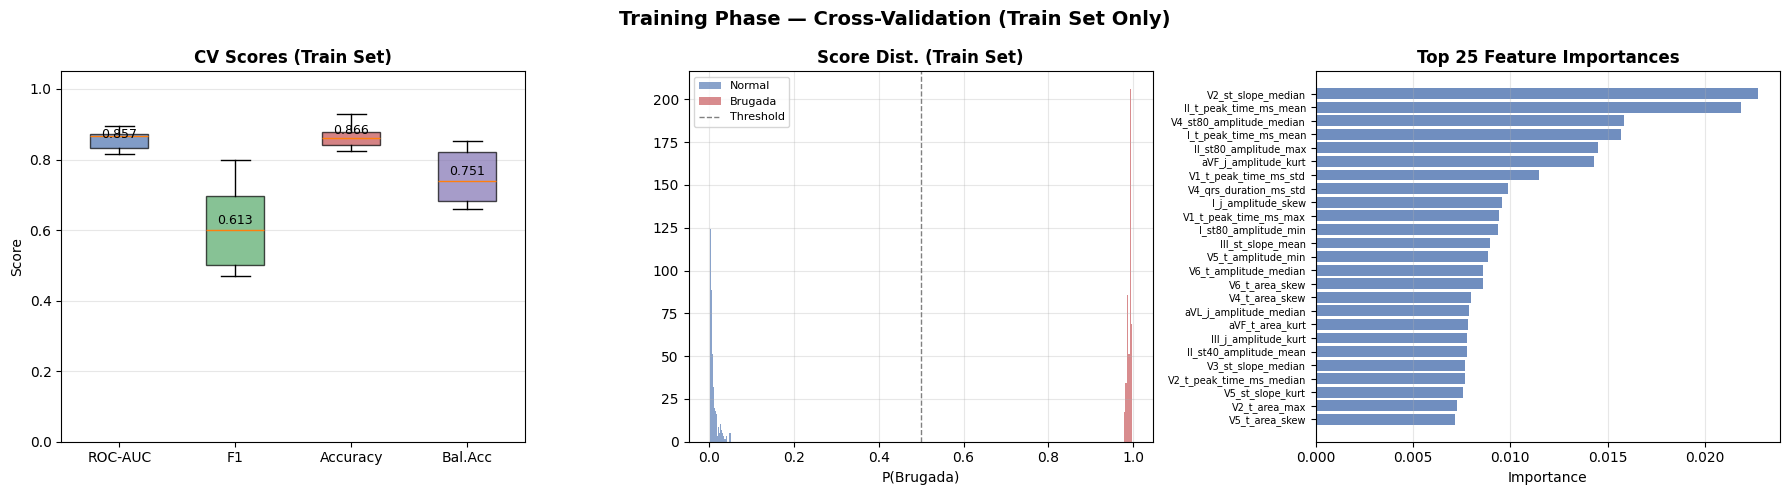

  Plot training : outputs/plot_training.png


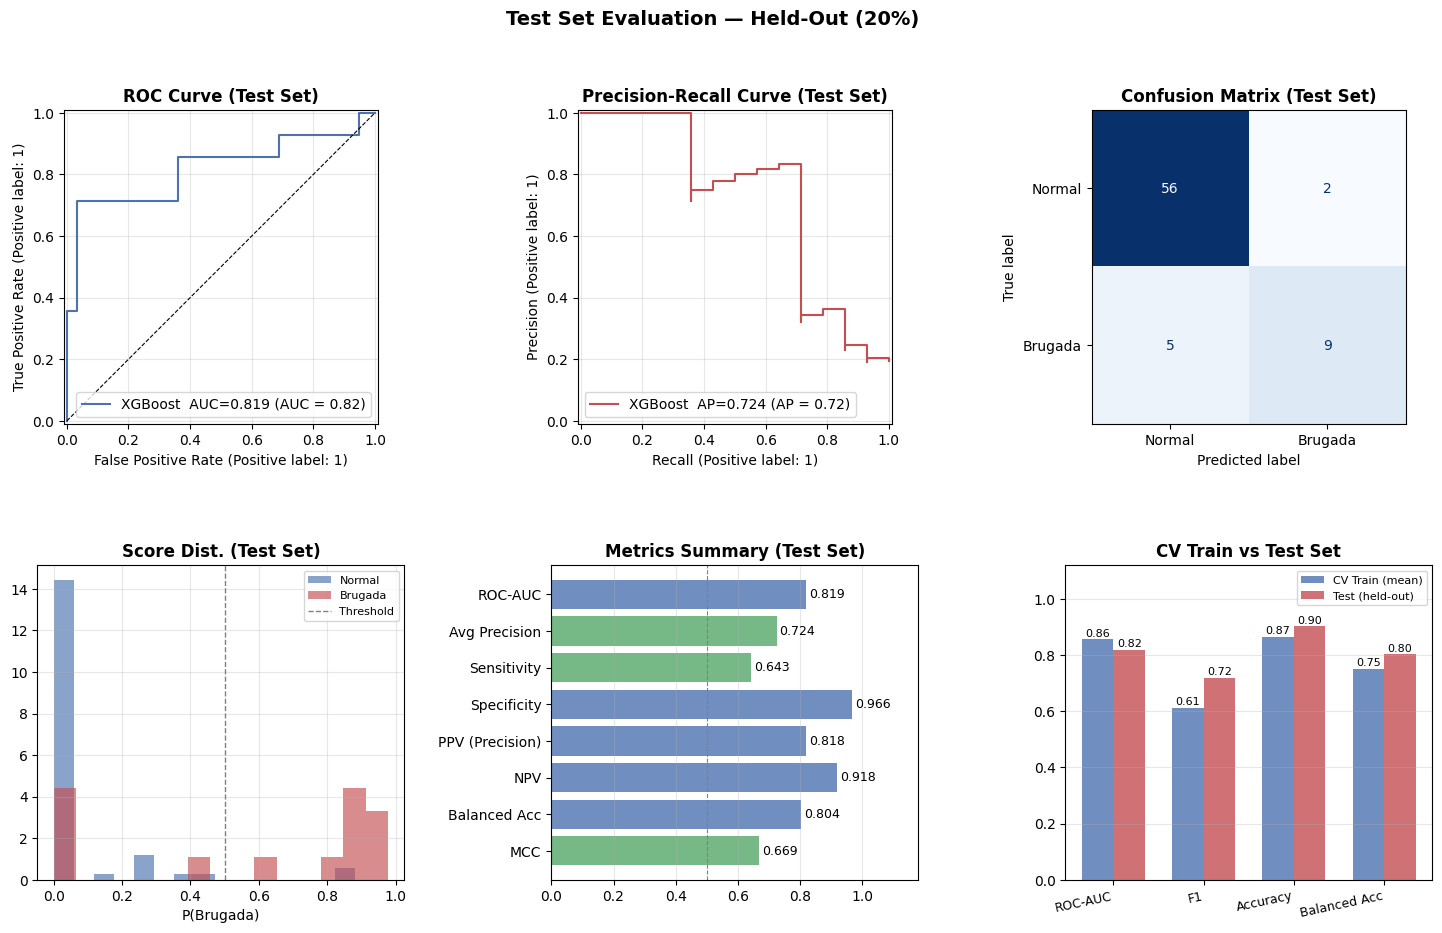

  Plot test     : outputs/plot_test_evaluation.png

  PIPELINE SELESAI
  Test ROC-AUC    : 0.819
  Test Sensitivity: 0.6429
  Test Specificity: 0.9655
  Test MCC        : 0.6692


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import wfdb
import neurokit2 as nk
from scipy import signal
from scipy.stats import skew, kurtosis
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, train_test_split
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, matthews_corrcoef, balanced_accuracy_score,
    f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")

CONFIG = {
    # Paths
    "data_dir": "/content/drive/MyDrive/lomba/files",
    "metadata_path": "metadata.csv",
    "output_dir": "outputs",

    # Signal processing
    "target_fs": 500,
    "bandpass_low": 0.5,
    "bandpass_high": 40.0,
    "bandpass_order": 4,

    # ECG leads
    "leads_of_interest": ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"],

    # Feature extraction
    "st_offset_40ms": 0.040,
    "st_offset_80ms": 0.080,
    "t_wave_window_end": 0.400,

    "test_size": 0.20,

    "xgb_params": {
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "eval_metric": "logloss",
        "random_state": 42,
        "scale_pos_weight": None,
    },

    "cv_folds": 5,
    "random_state": 42,
}

def load_ecg(patient_id, data_dir, leads):
    record_path = os.path.join(data_dir, str(patient_id), str(patient_id))
    record = wfdb.rdrecord(record_path)
    fs_orig = record.fs
    sig_names = [s.upper() for s in record.sig_name]

    lead_signals = {}
    for lead in leads:
        if lead.upper() not in sig_names:
            raise ValueError(
                f"Lead {lead} tidak ditemukan di record {patient_id}. "
                f"Tersedia: {sig_names}"
            )
        idx = sig_names.index(lead.upper())
        lead_signals[lead] = record.p_signal[:, idx].astype(np.float64)

    return lead_signals, fs_orig


def resample_signal(sig, fs_orig, fs_target):
    if fs_orig == fs_target:
        return sig
    return signal.resample(sig, int(len(sig) * fs_target / fs_orig))

def bandpass_filter(sig, fs, low, high, order=4):
    nyq = fs / 2.0
    b, a = signal.butter(order, [low / nyq, high / nyq], btype="band")
    return signal.filtfilt(b, a, sig)

def normalize_signal(sig, method="zscore"):
    if method == "zscore":
        mu, sd = np.mean(sig), np.std(sig)
        return (sig - mu) / sd if sd != 0 else sig - mu
    elif method == "minmax":
        lo, hi = sig.min(), sig.max()
        return (sig - lo) / (hi - lo) if hi != lo else np.zeros_like(sig)
    raise ValueError(f"Unknown method: {method}")

def detect_r_peaks(sig, fs):
    _, info = nk.ecg_peaks(sig, sampling_rate=int(fs), method="pantompkins1985")
    peaks = info["ECG_R_Peaks"]
    return peaks[peaks > 0]

def find_j_point(beat, r_idx, fs):
    start = r_idx + int(0.06 * fs)
    end   = min(r_idx + int(0.12 * fs), len(beat) - 1)
    if start >= end:
        return start
    return start + int(np.argmin(np.abs(np.diff(beat[start:end]))))

def extract_beat_features(beat, r_idx, fs, cfg):
    n = len(beat)

    # QRS duration
    q_idx = max(0, r_idx - int(0.06 * fs))
    s_end = min(n, r_idx + int(0.08 * fs))
    s_seg = beat[r_idx:s_end]
    s_idx = r_idx + int(np.argmin(s_seg)) if len(s_seg) > 0 else r_idx
    qrs_duration_ms = (s_idx - q_idx) / fs * 1000

    # J-point
    j_idx = find_j_point(beat, r_idx, fs)
    j_amplitude = beat[j_idx] if j_idx < n else np.nan

    # ST_40 & ST_80
    st40_idx = j_idx + int(cfg["st_offset_40ms"] * fs)
    st80_idx = j_idx + int(cfg["st_offset_80ms"] * fs)
    st40_amp = beat[st40_idx] if st40_idx < n else np.nan
    st80_amp = beat[st80_idx] if st80_idx < n else np.nan

    dt = cfg["st_offset_80ms"] - cfg["st_offset_40ms"]
    st_slope = (
        (st80_amp - st40_amp) / dt
        if not (np.isnan(st40_amp) or np.isnan(st80_amp)) and dt > 0
        else np.nan
    )

    # T-wave
    t_start = j_idx + int(0.05 * fs)
    t_end   = min(r_idx + int(cfg["t_wave_window_end"] * fs), n)
    if t_start < t_end:
        t_seg = beat[t_start:t_end]
        t_amplitude    = float(np.max(np.abs(t_seg)))
        t_area         = float(np.trapz(t_seg)) / fs
        t_peak_time_ms = int(np.argmax(np.abs(t_seg))) / fs * 1000
    else:
        t_amplitude = t_area = t_peak_time_ms = np.nan

    return {
        "qrs_duration_ms": qrs_duration_ms,
        "j_amplitude":     j_amplitude,
        "st40_amplitude":  st40_amp,
        "st80_amplitude":  st80_amp,
        "st_slope":        st_slope,
        "t_amplitude":     t_amplitude,
        "t_area":          t_area,
        "t_peak_time_ms":  t_peak_time_ms,
    }


def extract_features_for_lead(sig, fs, cfg):
    r_peaks = detect_r_peaks(sig, fs)
    pre, post = int(0.200 * fs), int(0.600 * fs)
    rows = []
    for rp in r_peaks:
        if rp - pre < 0 or rp + post > len(sig):
            continue
        rows.append(extract_beat_features(sig[rp - pre: rp + post], pre, fs, cfg))
    return pd.DataFrame(rows)

_AGG_FNS   = ["mean", "std", "median", "min", "max",
               lambda x: skew(x.dropna()),
               lambda x: kurtosis(x.dropna())]
_AGG_NAMES = ["mean", "std", "median", "min", "max", "skew", "kurt"]

def aggregate_patient_features(lead_dfs):
    all_feats = {}
    for lead, df in lead_dfs.items():
        if df.empty:
            continue
        for col in df.columns:
            for fn, name in zip(_AGG_FNS, _AGG_NAMES):
                all_feats[f"{lead}_{col}_{name}"] = df[col].agg(fn)
    return pd.Series(all_feats)

def process_patient(patient_id, cfg):
    try:
        lead_signals, fs_orig = load_ecg(
            patient_id, cfg["data_dir"], cfg["leads_of_interest"]
        )
        lead_features = {}
        for lead, raw in lead_signals.items():
            sig = resample_signal(raw, fs_orig, cfg["target_fs"])
            fs  = cfg["target_fs"]
            sig = bandpass_filter(sig, fs, cfg["bandpass_low"],
                                   cfg["bandpass_high"], cfg["bandpass_order"])
            sig = normalize_signal(sig, method="zscore")
            lead_features[lead] = extract_features_for_lead(sig, fs, cfg)

        feats = aggregate_patient_features(lead_features)
        feats["patient_id"] = patient_id
        return feats
    except Exception as e:
        print(f"  [SKIP] patient {patient_id}: {e}")
        return None

def build_feature_matrix(metadata, cfg):
    os.makedirs(cfg["output_dir"], exist_ok=True)
    records = []
    n = len(metadata)
    for i, row in metadata.iterrows():
        pid = int(row["patient_id"])
        if (i + 1) % 10 == 0 or i == 0:
            print(f"  Processing {i+1}/{n} — patient {pid}")
        feats = process_patient(pid, cfg)
        if feats is not None:
            records.append(feats)

    df = pd.DataFrame(records)
    df = df.merge(
        metadata[["patient_id", "brugada", "basal_pattern", "sudden_death"]],
        on="patient_id", how="left"
    )
    return df

def split_data(feature_df, cfg):

    label_col = "brugada"
    drop_cols  = ["patient_id", "brugada", "basal_pattern", "sudden_death"]
    feat_cols  = [c for c in feature_df.columns if c not in drop_cols]

    X   = feature_df[feat_cols].fillna(feature_df[feat_cols].median())
    y   = feature_df[label_col]
    ids = feature_df["patient_id"]

    X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
        X, y, ids,
        test_size=cfg["test_size"],
        stratify=y,
        random_state=cfg["random_state"]
    )

    print(f"\n  ┌─ Data Split ({'='*30})")
    print(f"  │  Train : {len(X_train):>4} pasien "
          f"— Normal:{(y_train==0).sum():>3}, Brugada:{(y_train==1).sum():>3}")
    print(f"  │  Test  : {len(X_test):>4} pasien "
          f"— Normal:{(y_test==0).sum():>3}, Brugada:{(y_test==1).sum():>3}")
    print(f"  └─ Test set dikunci — tidak dilihat sampai evaluasi akhir")

    return X_train, X_test, y_train, y_test, feat_cols, ids_train, ids_test

def train_xgboost(X_train, y_train, cfg):
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    scale_pos = neg / pos if pos > 0 else 1.0
    print(f"\n  Class imbalance train — Normal:{neg}, Brugada:{pos}")
    print(f"  scale_pos_weight : {scale_pos:.2f}")

    xgb_params = cfg["xgb_params"].copy()
    xgb_params["scale_pos_weight"] = scale_pos

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("xgb",   XGBClassifier(**xgb_params))
    ])

    cv = StratifiedKFold(n_splits=cfg["cv_folds"], shuffle=True,
                         random_state=cfg["random_state"])

    print(f"\n  Running {cfg['cv_folds']}-Fold Stratified CV pada TRAIN set ...")
    cv_auc = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_f1  = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="f1",      n_jobs=-1)
    cv_acc = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="accuracy",n_jobs=-1)
    cv_bac = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="balanced_accuracy", n_jobs=-1)

    print(f"\n  ── CV Results (train, {cfg['cv_folds']} folds) ──")
    for name, scores in [("ROC-AUC", cv_auc), ("F1", cv_f1),
                          ("Accuracy", cv_acc), ("Bal. Acc", cv_bac)]:
        print(f"  {name:<14}: {scores.mean():.4f} ± {scores.std():.4f}")

    # Fit final model
    pipe.fit(X_train, y_train)

    importance_df = pd.DataFrame({
        "feature":    X_train.columns.tolist(),
        "importance": pipe.named_steps["xgb"].feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    cv_results = {"auc": cv_auc, "f1": cv_f1, "acc": cv_acc, "bac": cv_bac}
    return pipe, cv_results, importance_df

def evaluate_on_test(pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    cm   = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "ROC-AUC":         round(roc_auc_score(y_test, y_prob), 4),
        "Avg Precision":   round(average_precision_score(y_test, y_prob), 4),
        "MCC":             round(matthews_corrcoef(y_test, y_pred), 4),
        "Balanced Acc":    round(balanced_accuracy_score(y_test, y_pred), 4),
        "F1":              round(f1_score(y_test, y_pred), 4),
        "Accuracy":        round(accuracy_score(y_test, y_pred), 4),
        "Sensitivity":     round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0.0,
        "Specificity":     round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0.0,
        "PPV (Precision)": round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0.0,
        "NPV":             round(tn / (tn + fn), 4) if (tn + fn) > 0 else 0.0,
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
    }

    print(f"\n  ╔{'═'*40}╗")
    print(f"  ║   TEST SET EVALUATION (HELD-OUT)       ║")
    print(f"  ╠{'═'*40}╣")
    for k, v in metrics.items():
        if k not in ("TP", "TN", "FP", "FN"):
            print(f"  ║  {k:<22}: {v:<14}║")
    print(f"  ║  TP:{tp}  TN:{tn}  FP:{fp}  FN:{fn}{'':>18}║")
    print(f"  ╚{'═'*40}╝")

    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=["Normal", "Brugada"]))

    return metrics, y_pred, y_prob, cm

def plot_all(cv_results, test_metrics, importance_df,
             X_train, y_train, X_test, y_test,
             pipe, cm, y_prob_test, output_dir):

    os.makedirs(output_dir, exist_ok=True)

    # ── Plot 1: Training phase ────────────────────────────────────────
    fig1, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig1.suptitle("Training Phase — Cross-Validation (Train Set Only)",
                  fontsize=14, fontweight="bold")

    # CV boxplot
    ax = axes[0]
    cv_df = pd.DataFrame({
        "ROC-AUC":  cv_results["auc"],
        "F1":       cv_results["f1"],
        "Accuracy": cv_results["acc"],
        "Bal.Acc":  cv_results["bac"],
    })
    bp = ax.boxplot(cv_df.values, labels=cv_df.columns,
                    patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"],
                             ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    for i, col in enumerate(cv_df.columns, 1):
        ax.text(i, cv_df[col].mean() + 0.005,
                f"{cv_df[col].mean():.3f}", ha="center", fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_title("CV Scores (Train Set)", fontweight="bold")
    ax.set_ylabel("Score"); ax.grid(axis="y", alpha=0.3)

    # Train score distribution
    ax = axes[1]
    y_prob_train = pipe.predict_proba(X_train)[:, 1]
    for lbl, name, color in [(0, "Normal", "#4C72B0"), (1, "Brugada", "#C44E52")]:
        ax.hist(y_prob_train[y_train == lbl], bins=20, alpha=0.65,
                label=name, color=color, density=True)
    ax.axvline(0.5, ls="--", color="gray", lw=1, label="Threshold")
    ax.set_xlabel("P(Brugada)"); ax.set_title("Score Dist. (Train Set)", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Top 25 feature importance
    ax = axes[2]
    top = importance_df.head(25)
    ax.barh(top["feature"][::-1], top["importance"][::-1], color="#4C72B0", alpha=0.8)
    ax.set_title("Top 25 Feature Importances", fontweight="bold")
    ax.set_xlabel("Importance"); ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="x", alpha=0.3)

    fig1.tight_layout()
    p1 = os.path.join(output_dir, "plot_training.png")
    fig1.savefig(p1, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Plot training : {p1}")

    # ── Plot 2: Test set evaluation ───────────────────────────────────
    fig2 = plt.figure(figsize=(18, 10))
    fig2.suptitle("Test Set Evaluation — Held-Out (20%)",
                  fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.4)

    y_pred_test = pipe.predict(X_test)

    # ROC Curve
    ax = fig2.add_subplot(gs[0, 0])
    RocCurveDisplay.from_predictions(
        y_test, y_prob_test, ax=ax,
        name=f"XGBoost  AUC={test_metrics['ROC-AUC']:.3f}",
        color="#4C72B0"
    )
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title("ROC Curve (Test Set)", fontweight="bold"); ax.grid(alpha=0.3)

    # PR Curve
    ax = fig2.add_subplot(gs[0, 1])
    PrecisionRecallDisplay.from_predictions(
        y_test, y_prob_test, ax=ax,
        name=f"XGBoost  AP={test_metrics['Avg Precision']:.3f}",
        color="#C44E52"
    )
    ax.set_title("Precision-Recall Curve (Test Set)", fontweight="bold"); ax.grid(alpha=0.3)

    # Confusion Matrix
    ax = fig2.add_subplot(gs[0, 2])
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Brugada"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title("Confusion Matrix (Test Set)", fontweight="bold")

    # Score dist test
    ax = fig2.add_subplot(gs[1, 0])
    for lbl, name, color in [(0, "Normal", "#4C72B0"), (1, "Brugada", "#C44E52")]:
        ax.hist(y_prob_test[y_test == lbl], bins=15, alpha=0.65,
                label=name, color=color, density=True)
    ax.axvline(0.5, ls="--", color="gray", lw=1, label="Threshold")
    ax.set_xlabel("P(Brugada)"); ax.set_title("Score Dist. (Test Set)", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Metrics bar
    ax = fig2.add_subplot(gs[1, 1])
    metric_keys = ["ROC-AUC", "Avg Precision", "Sensitivity",
                   "Specificity", "PPV (Precision)", "NPV",
                   "Balanced Acc", "MCC"]
    metric_vals = [test_metrics[k] for k in metric_keys]
    bar_colors  = ["#4C72B0" if v >= 0.8 else "#C44E52" if v < 0.6 else "#55A868"
                   for v in metric_vals]
    bars = ax.barh(metric_keys[::-1], metric_vals[::-1],
                   color=bar_colors[::-1], alpha=0.8)
    for bar, val in zip(bars, metric_vals[::-1]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.set_xlim(0, 1.18); ax.set_title("Metrics Summary (Test Set)", fontweight="bold")
    ax.axvline(0.5, ls="--", color="gray", lw=0.8); ax.grid(axis="x", alpha=0.3)

    # CV vs Test comparison
    ax = fig2.add_subplot(gs[1, 2])
    compare_keys = ["ROC-AUC", "F1", "Accuracy", "Balanced Acc"]
    cv_means  = [cv_results["auc"].mean(), cv_results["f1"].mean(),
                 cv_results["acc"].mean(), cv_results["bac"].mean()]
    test_vals = [test_metrics["ROC-AUC"], test_metrics["F1"],
                 test_metrics["Accuracy"], test_metrics["Balanced Acc"]]
    x = np.arange(len(compare_keys)); w = 0.35
    ax.bar(x - w/2, cv_means, w, label="CV Train (mean)", color="#4C72B0", alpha=0.8)
    ax.bar(x + w/2, test_vals, w, label="Test (held-out)", color="#C44E52", alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(compare_keys, rotation=12, ha="right", fontsize=9)
    ax.set_ylim(0, 1.12); ax.set_title("CV Train vs Test Set", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
    for xi, (cv_v, te_v) in enumerate(zip(cv_means, test_vals)):
        ax.text(xi - w/2, cv_v + 0.01, f"{cv_v:.2f}", ha="center", fontsize=8)
        ax.text(xi + w/2, te_v + 0.01, f"{te_v:.2f}", ha="center", fontsize=8)

    fig2.tight_layout()
    p2 = os.path.join(output_dir, "plot_test_evaluation.png")
    fig2.savefig(p2, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Plot test     : {p2}")


def plot_example_ecg(patient_id, cfg):
    try:
        lead_signals, fs_orig = load_ecg(
            patient_id, cfg["data_dir"], cfg["leads_of_interest"]
        )
        lead = cfg["leads_of_interest"][0]
        raw  = lead_signals[lead]
        sig_rs = resample_signal(raw, fs_orig, cfg["target_fs"])
        fs     = cfg["target_fs"]
        sig_bp = bandpass_filter(sig_rs, fs, cfg["bandpass_low"],
                                  cfg["bandpass_high"], cfg["bandpass_order"])
        sig_nm = normalize_signal(sig_bp)
        r_peaks = detect_r_peaks(sig_nm, fs)
        time = np.arange(len(sig_nm)) / fs

        fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
        axes[0].plot(time, sig_rs, lw=0.8, color="gray")
        axes[0].set_title(f"Patient {patient_id} — {lead}: Raw ({fs}Hz)")
        axes[1].plot(time, sig_bp, lw=0.8, color="#4C72B0")
        axes[1].set_title(f"Bandpass Filter ({cfg['bandpass_low']}–{cfg['bandpass_high']} Hz)")
        axes[2].plot(time, sig_nm, lw=0.8, color="#2ca02c")
        axes[2].scatter(r_peaks / fs, sig_nm[r_peaks],
                        color="red", s=30, zorder=5, label="R-peaks")
        axes[2].set_title("Normalisasi + R-peak Detection")
        axes[2].legend(); axes[2].set_xlabel("Waktu (detik)")
        for ax in axes:
            ax.set_ylabel("Amplitude"); ax.grid(True, alpha=0.3)
        plt.suptitle(f"ECG Preprocessing — Patient {patient_id}", fontweight="bold")
        plt.tight_layout()
        out = os.path.join(cfg["output_dir"], f"ecg_example_patient{patient_id}.png")
        plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
        print(f"  ECG plot: {out}")
    except Exception as e:
        print(f"  [SKIP] ECG plot patient {patient_id}: {e}")

def main():
    print("=" * 62)
    print("  BRUGADA SYNDROME DETECTION PIPELINE")
    print("=" * 62)

    # 1. Metadata
    print(f"\n[1/7] Loading metadata ...")
    metadata = pd.read_csv(CONFIG["metadata_path"])
    metadata = metadata[metadata["brugada"].isin([0, 1])].reset_index(drop=True)
    print(f"  Total   : {len(metadata)} pasien")
    print(f"  Brugada : {metadata['brugada'].sum()}")
    print(f"  Normal  : {(metadata['brugada']==0).sum()}")

    # 3. Feature extraction
    print(f"\n[3/7] Ekstraksi fitur semua pasien ...")
    feature_df = build_feature_matrix(metadata, CONFIG)
    feat_path  = os.path.join(CONFIG["output_dir"], "features_all.csv")
    feature_df.to_csv(feat_path, index=False)
    print(f"  Feature matrix: {feature_df.shape} → {feat_path}")

    # 4. Train/Test Split
    print(f"\n[4/7] Stratified Train/Test Split "
          f"({int((1-CONFIG['test_size'])*100)}/{int(CONFIG['test_size']*100)}) ...")
    (X_train, X_test, y_train, y_test,
     feat_cols, ids_train, ids_test) = split_data(feature_df, CONFIG)

    # Simpan indeks split
    split_df = pd.DataFrame({
        "patient_id": list(ids_train) + list(ids_test),
        "split":      ["train"] * len(ids_train) + ["test"] * len(ids_test)
    })
    split_path = os.path.join(CONFIG["output_dir"], "data_split.csv")
    split_df.to_csv(split_path, index=False)
    print(f"  Split index: {split_path}")

    # 5. Training + CV
    print(f"\n[5/7] Training XGBoost (CV pada train set) ...")
    pipe, cv_results, importance_df = train_xgboost(X_train, y_train, CONFIG)

    model_path = os.path.join(CONFIG["output_dir"], "brugada_xgb_pipeline.joblib")
    joblib.dump(pipe, model_path)
    imp_path = os.path.join(CONFIG["output_dir"], "feature_importance.csv")
    importance_df.to_csv(imp_path, index=False)
    print(f"\n  Model   : {model_path}")
    print(f"\n  Top 10 Features:")
    print(importance_df.head(10).to_string(index=False))

    # 6. Test evaluation
    print(f"\n[6/7] Evaluasi pada TEST SET (held-out) ...")
    test_metrics, y_pred_test, y_prob_test, cm = evaluate_on_test(
        pipe, X_test, y_test
    )

    # Simpan prediksi per pasien
    pred_df = pd.DataFrame({
        "patient_id":   ids_test.values,
        "y_true":       y_test.values,
        "y_pred":       y_pred_test,
        "prob_brugada": np.round(y_prob_test, 4),
        "correct":      (y_pred_test == y_test.values),
    })
    pred_path = os.path.join(CONFIG["output_dir"], "test_predictions.csv")
    pred_df.to_csv(pred_path, index=False)

    metrics_path = os.path.join(CONFIG["output_dir"], "test_metrics.csv")
    pd.DataFrame([test_metrics]).to_csv(metrics_path, index=False)
    print(f"\n  Prediksi test  : {pred_path}")
    print(f"  Metrik test    : {metrics_path}")

    cv_vs_test(pipe, X_train, y_train, X_test, y_test)

    # 7. Plot
    print(f"\n[7/7] Membuat visualisasi ...")
    plot_all(cv_results, test_metrics, importance_df,
             X_train, y_train, X_test, y_test,
             pipe, cm, y_prob_test, CONFIG["output_dir"])

    print("\n" + "=" * 62)
    print("  PIPELINE SELESAI")
    print(f"  Test ROC-AUC    : {test_metrics['ROC-AUC']}")
    print(f"  Test Sensitivity: {test_metrics['Sensitivity']}")
    print(f"  Test Specificity: {test_metrics['Specificity']}")
    print(f"  Test MCC        : {test_metrics['MCC']}")
    print("=" * 62)

    return pipe, feature_df, importance_df, test_metrics

if __name__ == "__main__":
    pipe, feature_df, importance_df, test_metrics = main()

## XGB WITHOUT GA

  BRUGADA SYNDROME DETECTION PIPELINE

[1/7] Loading metadata ...
  Total   : 356 pasien
  Brugada : 69
  Normal  : 287

[3/7] Ekstraksi fitur semua pasien ...
  Processing 1/356 — patient 188981
  Processing 10/356 — patient 304141
  Processing 20/356 — patient 395553
  Processing 30/356 — patient 450733
  Processing 40/356 — patient 506408
  Processing 50/356 — patient 558967
  Processing 60/356 — patient 622530
  Processing 70/356 — patient 814286
  Processing 80/356 — patient 852786
  Processing 90/356 — patient 903442
  Processing 100/356 — patient 939546
  Processing 110/356 — patient 965217
  Processing 120/356 — patient 985814
  Processing 130/356 — patient 1036640
  Processing 140/356 — patient 1080968
  Processing 150/356 — patient 1093224
  Processing 160/356 — patient 1118251
  Processing 170/356 — patient 1142915
  Processing 180/356 — patient 1169405
  Processing 190/356 — patient 1191551
  Processing 200/356 — patient 1207769
  Processing 210/356 — patient 1235674
  Proc

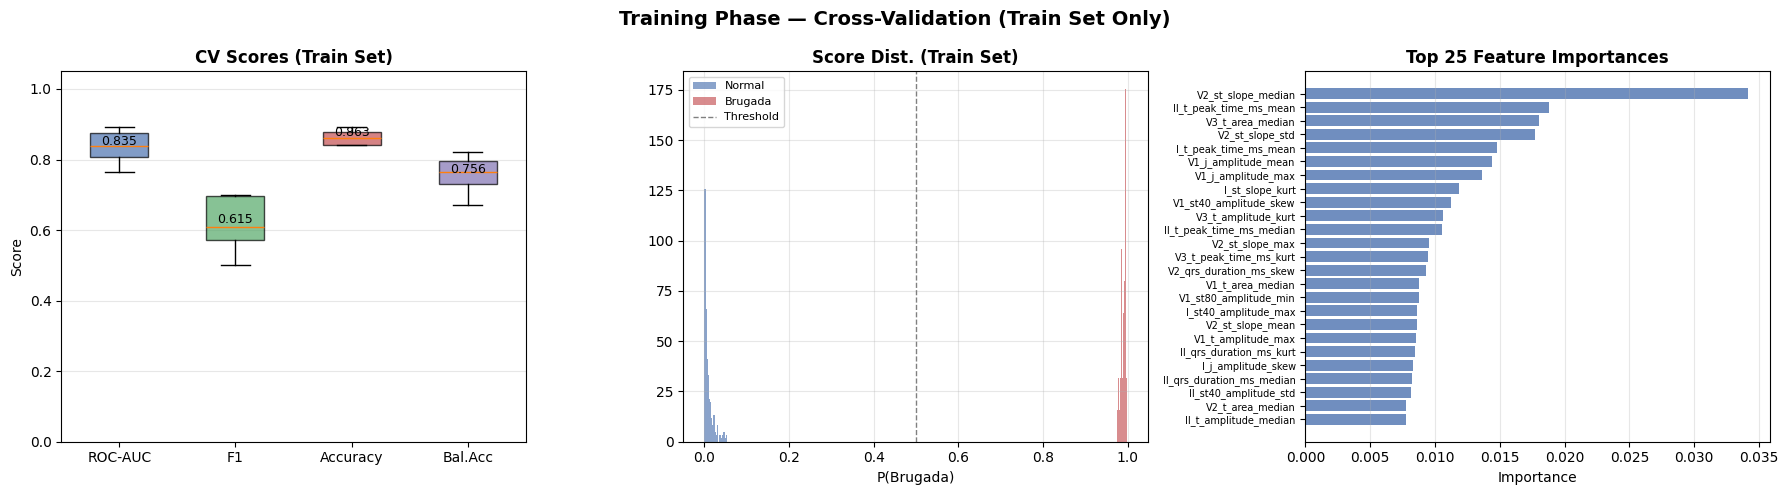

  Plot training : outputs/plot_training.png


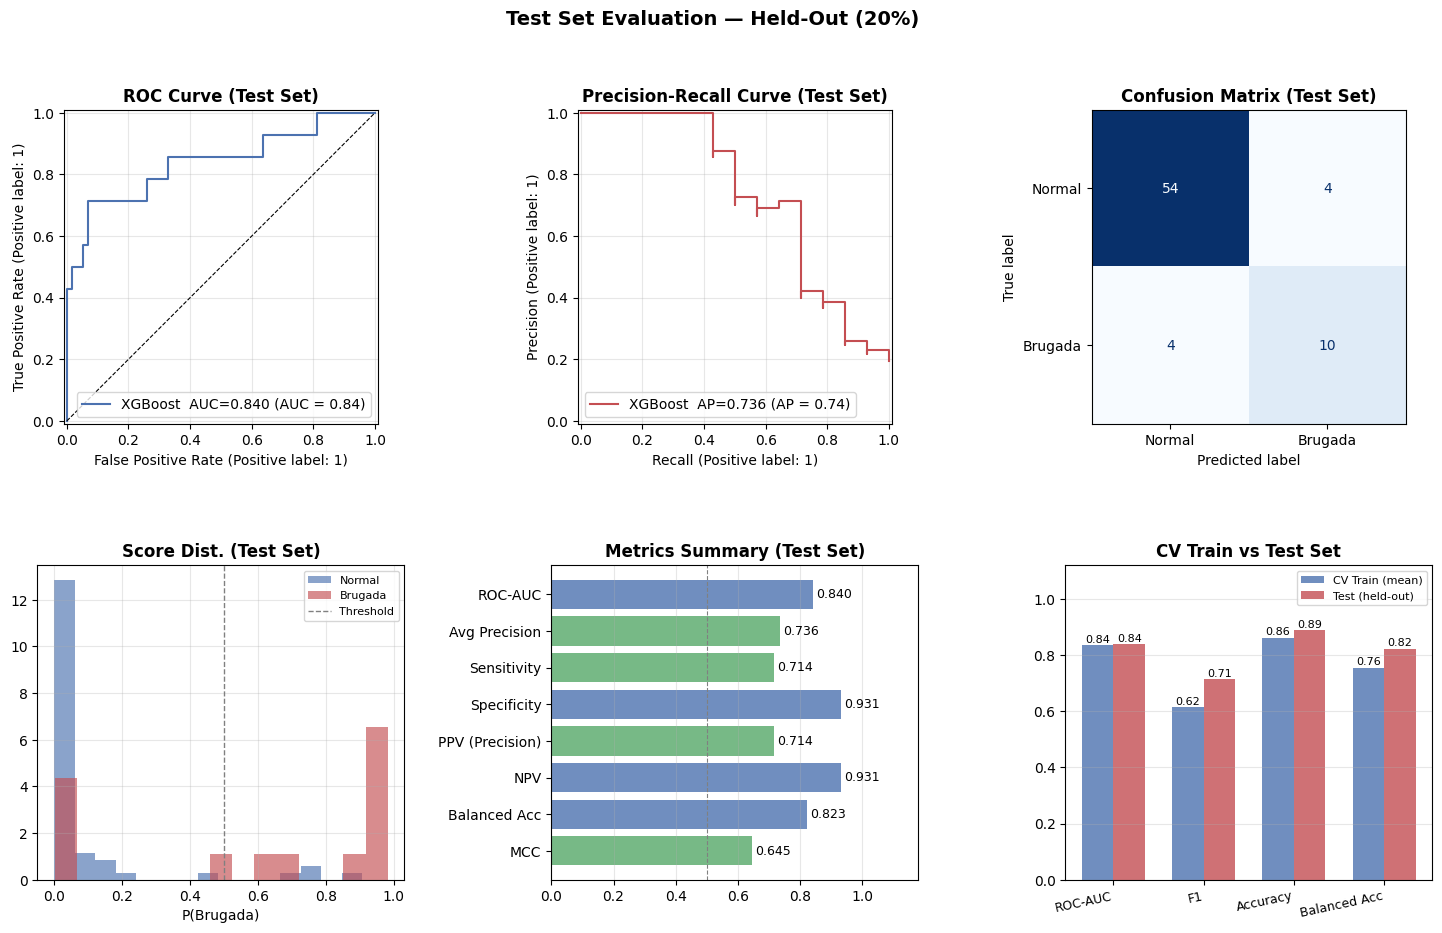

  Plot test     : outputs/plot_test_evaluation.png

  PIPELINE SELESAI
  Test ROC-AUC    : 0.8399
  Test Sensitivity: 0.7143
  Test Specificity: 0.931
  Test MCC        : 0.6453


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import wfdb
import neurokit2 as nk
from scipy import signal
from scipy.stats import skew, kurtosis
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, train_test_split
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, matthews_corrcoef, balanced_accuracy_score,
    f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")

CONFIG = {
    # Paths
    "data_dir": "/content/drive/MyDrive/lomba/files",
    "metadata_path": "metadata.csv",
    "output_dir": "outputs",

    # Signal processing
    "target_fs": 500,
    "bandpass_low": 0.5,
    "bandpass_high": 40.0,
    "bandpass_order": 4,

    # ECG leads
    "leads_of_interest": ["I", "II", "III", "V1", "V2", "V3"],

    # Feature extraction
    "st_offset_40ms": 0.040,
    "st_offset_80ms": 0.080,
    "t_wave_window_end": 0.400,

    "test_size": 0.20,

    "xgb_params": {
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "eval_metric": "logloss",
        "random_state": 42,
        "scale_pos_weight": None,
    },

    "cv_folds": 5,
    "random_state": 42,
}

def load_ecg(patient_id, data_dir, leads):
    record_path = os.path.join(data_dir, str(patient_id), str(patient_id))
    record = wfdb.rdrecord(record_path)
    fs_orig = record.fs
    sig_names = [s.upper() for s in record.sig_name]

    lead_signals = {}
    for lead in leads:
        if lead.upper() not in sig_names:
            raise ValueError(
                f"Lead {lead} tidak ditemukan di record {patient_id}. "
                f"Tersedia: {sig_names}"
            )
        idx = sig_names.index(lead.upper())
        lead_signals[lead] = record.p_signal[:, idx].astype(np.float64)

    return lead_signals, fs_orig

def resample_signal(sig, fs_orig, fs_target):
    if fs_orig == fs_target:
        return sig
    return signal.resample(sig, int(len(sig) * fs_target / fs_orig))

def bandpass_filter(sig, fs, low, high, order=4):
    nyq = fs / 2.0
    b, a = signal.butter(order, [low / nyq, high / nyq], btype="band")
    return signal.filtfilt(b, a, sig)

def normalize_signal(sig, method="zscore"):
    if method == "zscore":
        mu, sd = np.mean(sig), np.std(sig)
        return (sig - mu) / sd if sd != 0 else sig - mu
    elif method == "minmax":
        lo, hi = sig.min(), sig.max()
        return (sig - lo) / (hi - lo) if hi != lo else np.zeros_like(sig)
    raise ValueError(f"Unknown method: {method}")

def detect_r_peaks(sig, fs):
    _, info = nk.ecg_peaks(sig, sampling_rate=int(fs), method="pantompkins1985")
    peaks = info["ECG_R_Peaks"]
    return peaks[peaks > 0]

def find_j_point(beat, r_idx, fs):
    start = r_idx + int(0.06 * fs)
    end   = min(r_idx + int(0.12 * fs), len(beat) - 1)
    if start >= end:
        return start
    return start + int(np.argmin(np.abs(np.diff(beat[start:end]))))

def extract_beat_features(beat, r_idx, fs, cfg):
    n = len(beat)

    # QRS duration
    q_idx = max(0, r_idx - int(0.06 * fs))
    s_end = min(n, r_idx + int(0.08 * fs))
    s_seg = beat[r_idx:s_end]
    s_idx = r_idx + int(np.argmin(s_seg)) if len(s_seg) > 0 else r_idx
    qrs_duration_ms = (s_idx - q_idx) / fs * 1000

    # J-point
    j_idx = find_j_point(beat, r_idx, fs)
    j_amplitude = beat[j_idx] if j_idx < n else np.nan

    # ST_40 & ST_80
    st40_idx = j_idx + int(cfg["st_offset_40ms"] * fs)
    st80_idx = j_idx + int(cfg["st_offset_80ms"] * fs)
    st40_amp = beat[st40_idx] if st40_idx < n else np.nan
    st80_amp = beat[st80_idx] if st80_idx < n else np.nan

    dt = cfg["st_offset_80ms"] - cfg["st_offset_40ms"]
    st_slope = (
        (st80_amp - st40_amp) / dt
        if not (np.isnan(st40_amp) or np.isnan(st80_amp)) and dt > 0
        else np.nan
    )

    # T-wave
    t_start = j_idx + int(0.05 * fs)
    t_end   = min(r_idx + int(cfg["t_wave_window_end"] * fs), n)
    if t_start < t_end:
        t_seg = beat[t_start:t_end]
        t_amplitude    = float(np.max(np.abs(t_seg)))
        t_area         = float(np.trapz(t_seg)) / fs
        t_peak_time_ms = int(np.argmax(np.abs(t_seg))) / fs * 1000
    else:
        t_amplitude = t_area = t_peak_time_ms = np.nan

    return {
        "qrs_duration_ms": qrs_duration_ms,
        "j_amplitude":     j_amplitude,
        "st40_amplitude":  st40_amp,
        "st80_amplitude":  st80_amp,
        "st_slope":        st_slope,
        "t_amplitude":     t_amplitude,
        "t_area":          t_area,
        "t_peak_time_ms":  t_peak_time_ms,
    }


def extract_features_for_lead(sig, fs, cfg):
    r_peaks = detect_r_peaks(sig, fs)
    pre, post = int(0.200 * fs), int(0.600 * fs)
    rows = []
    for rp in r_peaks:
        if rp - pre < 0 or rp + post > len(sig):
            continue
        rows.append(extract_beat_features(sig[rp - pre: rp + post], pre, fs, cfg))
    return pd.DataFrame(rows)

_AGG_FNS   = ["mean", "std", "median", "min", "max",
               lambda x: skew(x.dropna()),
               lambda x: kurtosis(x.dropna())]
_AGG_NAMES = ["mean", "std", "median", "min", "max", "skew", "kurt"]

def aggregate_patient_features(lead_dfs):
    all_feats = {}
    for lead, df in lead_dfs.items():
        if df.empty:
            continue
        for col in df.columns:
            for fn, name in zip(_AGG_FNS, _AGG_NAMES):
                all_feats[f"{lead}_{col}_{name}"] = df[col].agg(fn)
    return pd.Series(all_feats)

def process_patient(patient_id, cfg):
    try:
        lead_signals, fs_orig = load_ecg(
            patient_id, cfg["data_dir"], cfg["leads_of_interest"]
        )
        lead_features = {}
        for lead, raw in lead_signals.items():
            sig = resample_signal(raw, fs_orig, cfg["target_fs"])
            fs  = cfg["target_fs"]
            sig = bandpass_filter(sig, fs, cfg["bandpass_low"],
                                   cfg["bandpass_high"], cfg["bandpass_order"])
            sig = normalize_signal(sig, method="zscore")
            lead_features[lead] = extract_features_for_lead(sig, fs, cfg)

        feats = aggregate_patient_features(lead_features)
        feats["patient_id"] = patient_id
        return feats
    except Exception as e:
        print(f"  [SKIP] patient {patient_id}: {e}")
        return None

def build_feature_matrix(metadata, cfg):
    os.makedirs(cfg["output_dir"], exist_ok=True)
    records = []
    n = len(metadata)
    for i, row in metadata.iterrows():
        pid = int(row["patient_id"])
        if (i + 1) % 10 == 0 or i == 0:
            print(f"  Processing {i+1}/{n} — patient {pid}")
        feats = process_patient(pid, cfg)
        if feats is not None:
            records.append(feats)

    df = pd.DataFrame(records)
    df = df.merge(
        metadata[["patient_id", "brugada", "basal_pattern", "sudden_death"]],
        on="patient_id", how="left"
    )
    return df

def split_data(feature_df, cfg):
    label_col = "brugada"
    drop_cols  = ["patient_id", "brugada", "basal_pattern", "sudden_death"]
    feat_cols  = [c for c in feature_df.columns if c not in drop_cols]

    X   = feature_df[feat_cols].fillna(feature_df[feat_cols].median())
    y   = feature_df[label_col]
    ids = feature_df["patient_id"]

    X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
        X, y, ids,
        test_size=cfg["test_size"],
        stratify=y,
        random_state=cfg["random_state"]
    )

    print(f"\n  ┌─ Data Split ({'='*30})")
    print(f"  │  Train : {len(X_train):>4} pasien "
          f"— Normal:{(y_train==0).sum():>3}, Brugada:{(y_train==1).sum():>3}")
    print(f"  │  Test  : {len(X_test):>4} pasien "
          f"— Normal:{(y_test==0).sum():>3}, Brugada:{(y_test==1).sum():>3}")
    print(f"  └─ Test set dikunci — tidak dilihat sampai evaluasi akhir")

    return X_train, X_test, y_train, y_test, feat_cols, ids_train, ids_test

def train_xgboost(X_train, y_train, cfg):
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    scale_pos = neg / pos if pos > 0 else 1.0
    print(f"\n  Class imbalance train — Normal:{neg}, Brugada:{pos}")
    print(f"  scale_pos_weight : {scale_pos:.2f}")

    xgb_params = cfg["xgb_params"].copy()
    xgb_params["scale_pos_weight"] = scale_pos

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("xgb",   XGBClassifier(**xgb_params))
    ])

    cv = StratifiedKFold(n_splits=cfg["cv_folds"], shuffle=True,
                         random_state=cfg["random_state"])

    print(f"\n  Running {cfg['cv_folds']}-Fold Stratified CV pada TRAIN set ...")
    cv_auc = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_f1  = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="f1",      n_jobs=-1)
    cv_acc = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="accuracy",n_jobs=-1)
    cv_bac = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="balanced_accuracy", n_jobs=-1)

    print(f"\n  ── CV Results (train, {cfg['cv_folds']} folds) ──")
    for name, scores in [("ROC-AUC", cv_auc), ("F1", cv_f1),
                          ("Accuracy", cv_acc), ("Bal. Acc", cv_bac)]:
        print(f"  {name:<14}: {scores.mean():.4f} ± {scores.std():.4f}")

    # Fit final model
    pipe.fit(X_train, y_train)

    importance_df = pd.DataFrame({
        "feature":    X_train.columns.tolist(),
        "importance": pipe.named_steps["xgb"].feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    cv_results = {"auc": cv_auc, "f1": cv_f1, "acc": cv_acc, "bac": cv_bac}
    return pipe, cv_results, importance_df

def evaluate_on_test(pipe, X_test, y_test):
    """
    EVALUASI AKHIR pada held-out test set.
    Ini satu-satunya tempat test set dibuka.
    Semua angka yang dilaporkan berasal dari sini.
    """
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    cm   = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "ROC-AUC":         round(roc_auc_score(y_test, y_prob), 4),
        "Avg Precision":   round(average_precision_score(y_test, y_prob), 4),
        "MCC":             round(matthews_corrcoef(y_test, y_pred), 4),
        "Balanced Acc":    round(balanced_accuracy_score(y_test, y_pred), 4),
        "F1":              round(f1_score(y_test, y_pred), 4),
        "Accuracy":        round(accuracy_score(y_test, y_pred), 4),
        "Sensitivity":     round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0.0,
        "Specificity":     round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0.0,
        "PPV (Precision)": round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0.0,
        "NPV":             round(tn / (tn + fn), 4) if (tn + fn) > 0 else 0.0,
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
    }

    print(f"\n  ╔{'═'*40}╗")
    print(f"  ║   TEST SET EVALUATION (HELD-OUT)       ║")
    print(f"  ╠{'═'*40}╣")
    for k, v in metrics.items():
        if k not in ("TP", "TN", "FP", "FN"):
            print(f"  ║  {k:<22}: {v:<14}║")
    print(f"  ║  TP:{tp}  TN:{tn}  FP:{fp}  FN:{fn}{'':>18}║")
    print(f"  ╚{'═'*40}╝")

    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=["Normal", "Brugada"]))

    return metrics, y_pred, y_prob, cm

def plot_all(cv_results, test_metrics, importance_df,
             X_train, y_train, X_test, y_test,
             pipe, cm, y_prob_test, output_dir):

    os.makedirs(output_dir, exist_ok=True)

    # ── Plot 1: Training phase ────────────────────────────────────────
    fig1, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig1.suptitle("Training Phase — Cross-Validation (Train Set Only)",
                  fontsize=14, fontweight="bold")

    # CV boxplot
    ax = axes[0]
    cv_df = pd.DataFrame({
        "ROC-AUC":  cv_results["auc"],
        "F1":       cv_results["f1"],
        "Accuracy": cv_results["acc"],
        "Bal.Acc":  cv_results["bac"],
    })
    bp = ax.boxplot(cv_df.values, labels=cv_df.columns,
                    patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"],
                             ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    for i, col in enumerate(cv_df.columns, 1):
        ax.text(i, cv_df[col].mean() + 0.005,
                f"{cv_df[col].mean():.3f}", ha="center", fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_title("CV Scores (Train Set)", fontweight="bold")
    ax.set_ylabel("Score"); ax.grid(axis="y", alpha=0.3)

    # Train score distribution
    ax = axes[1]
    y_prob_train = pipe.predict_proba(X_train)[:, 1]
    for lbl, name, color in [(0, "Normal", "#4C72B0"), (1, "Brugada", "#C44E52")]:
        ax.hist(y_prob_train[y_train == lbl], bins=20, alpha=0.65,
                label=name, color=color, density=True)
    ax.axvline(0.5, ls="--", color="gray", lw=1, label="Threshold")
    ax.set_xlabel("P(Brugada)"); ax.set_title("Score Dist. (Train Set)", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Top 25 feature importance
    ax = axes[2]
    top = importance_df.head(25)
    ax.barh(top["feature"][::-1], top["importance"][::-1], color="#4C72B0", alpha=0.8)
    ax.set_title("Top 25 Feature Importances", fontweight="bold")
    ax.set_xlabel("Importance"); ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="x", alpha=0.3)

    fig1.tight_layout()
    p1 = os.path.join(output_dir, "plot_training.png")
    fig1.savefig(p1, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Plot training : {p1}")

    # ── Plot 2: Test set evaluation ───────────────────────────────────
    fig2 = plt.figure(figsize=(18, 10))
    fig2.suptitle("Test Set Evaluation — Held-Out (20%)",
                  fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.4)

    y_pred_test = pipe.predict(X_test)

    # ROC Curve
    ax = fig2.add_subplot(gs[0, 0])
    RocCurveDisplay.from_predictions(
        y_test, y_prob_test, ax=ax,
        name=f"XGBoost  AUC={test_metrics['ROC-AUC']:.3f}",
        color="#4C72B0"
    )
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title("ROC Curve (Test Set)", fontweight="bold"); ax.grid(alpha=0.3)

    # PR Curve
    ax = fig2.add_subplot(gs[0, 1])
    PrecisionRecallDisplay.from_predictions(
        y_test, y_prob_test, ax=ax,
        name=f"XGBoost  AP={test_metrics['Avg Precision']:.3f}",
        color="#C44E52"
    )
    ax.set_title("Precision-Recall Curve (Test Set)", fontweight="bold"); ax.grid(alpha=0.3)

    # Confusion Matrix
    ax = fig2.add_subplot(gs[0, 2])
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Brugada"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title("Confusion Matrix (Test Set)", fontweight="bold")

    # Score dist test
    ax = fig2.add_subplot(gs[1, 0])
    for lbl, name, color in [(0, "Normal", "#4C72B0"), (1, "Brugada", "#C44E52")]:
        ax.hist(y_prob_test[y_test == lbl], bins=15, alpha=0.65,
                label=name, color=color, density=True)
    ax.axvline(0.5, ls="--", color="gray", lw=1, label="Threshold")
    ax.set_xlabel("P(Brugada)"); ax.set_title("Score Dist. (Test Set)", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Metrics bar
    ax = fig2.add_subplot(gs[1, 1])
    metric_keys = ["ROC-AUC", "Avg Precision", "Sensitivity",
                   "Specificity", "PPV (Precision)", "NPV",
                   "Balanced Acc", "MCC"]
    metric_vals = [test_metrics[k] for k in metric_keys]
    bar_colors  = ["#4C72B0" if v >= 0.8 else "#C44E52" if v < 0.6 else "#55A868"
                   for v in metric_vals]
    bars = ax.barh(metric_keys[::-1], metric_vals[::-1],
                   color=bar_colors[::-1], alpha=0.8)
    for bar, val in zip(bars, metric_vals[::-1]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.set_xlim(0, 1.18); ax.set_title("Metrics Summary (Test Set)", fontweight="bold")
    ax.axvline(0.5, ls="--", color="gray", lw=0.8); ax.grid(axis="x", alpha=0.3)

    # CV vs Test comparison
    ax = fig2.add_subplot(gs[1, 2])
    compare_keys = ["ROC-AUC", "F1", "Accuracy", "Balanced Acc"]
    cv_means  = [cv_results["auc"].mean(), cv_results["f1"].mean(),
                 cv_results["acc"].mean(), cv_results["bac"].mean()]
    test_vals = [test_metrics["ROC-AUC"], test_metrics["F1"],
                 test_metrics["Accuracy"], test_metrics["Balanced Acc"]]
    x = np.arange(len(compare_keys)); w = 0.35
    ax.bar(x - w/2, cv_means, w, label="CV Train (mean)", color="#4C72B0", alpha=0.8)
    ax.bar(x + w/2, test_vals, w, label="Test (held-out)", color="#C44E52", alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(compare_keys, rotation=12, ha="right", fontsize=9)
    ax.set_ylim(0, 1.12); ax.set_title("CV Train vs Test Set", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
    for xi, (cv_v, te_v) in enumerate(zip(cv_means, test_vals)):
        ax.text(xi - w/2, cv_v + 0.01, f"{cv_v:.2f}", ha="center", fontsize=8)
        ax.text(xi + w/2, te_v + 0.01, f"{te_v:.2f}", ha="center", fontsize=8)

    fig2.tight_layout()
    p2 = os.path.join(output_dir, "plot_test_evaluation.png")
    fig2.savefig(p2, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Plot test     : {p2}")

def plot_example_ecg(patient_id, cfg):
    try:
        lead_signals, fs_orig = load_ecg(
            patient_id, cfg["data_dir"], cfg["leads_of_interest"]
        )
        lead = cfg["leads_of_interest"][0]
        raw  = lead_signals[lead]
        sig_rs = resample_signal(raw, fs_orig, cfg["target_fs"])
        fs     = cfg["target_fs"]
        sig_bp = bandpass_filter(sig_rs, fs, cfg["bandpass_low"],
                                  cfg["bandpass_high"], cfg["bandpass_order"])
        sig_nm = normalize_signal(sig_bp)
        r_peaks = detect_r_peaks(sig_nm, fs)
        time = np.arange(len(sig_nm)) / fs

        fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
        axes[0].plot(time, sig_rs, lw=0.8, color="gray")
        axes[0].set_title(f"Patient {patient_id} — {lead}: Raw ({fs}Hz)")
        axes[1].plot(time, sig_bp, lw=0.8, color="#4C72B0")
        axes[1].set_title(f"Bandpass Filter ({cfg['bandpass_low']}–{cfg['bandpass_high']} Hz)")
        axes[2].plot(time, sig_nm, lw=0.8, color="#2ca02c")
        axes[2].scatter(r_peaks / fs, sig_nm[r_peaks],
                        color="red", s=30, zorder=5, label="R-peaks")
        axes[2].set_title("Normalisasi + R-peak Detection")
        axes[2].legend(); axes[2].set_xlabel("Waktu (detik)")
        for ax in axes:
            ax.set_ylabel("Amplitude"); ax.grid(True, alpha=0.3)
        plt.suptitle(f"ECG Preprocessing — Patient {patient_id}", fontweight="bold")
        plt.tight_layout()
        out = os.path.join(cfg["output_dir"], f"ecg_example_patient{patient_id}.png")
        plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
        print(f"  ECG plot: {out}")
    except Exception as e:
        print(f"  [SKIP] ECG plot patient {patient_id}: {e}")

def main():
    print("=" * 62)
    print("  BRUGADA SYNDROME DETECTION PIPELINE")
    print("=" * 62)

    # 1. Metadata
    print(f"\n[1/7] Loading metadata ...")
    metadata = pd.read_csv(CONFIG["metadata_path"])
    metadata = metadata[metadata["brugada"].isin([0, 1])].reset_index(drop=True)
    print(f"  Total   : {len(metadata)} pasien")
    print(f"  Brugada : {metadata['brugada'].sum()}")
    print(f"  Normal  : {(metadata['brugada']==0).sum()}")

    # 3. Feature extraction
    print(f"\n[3/7] Ekstraksi fitur semua pasien ...")
    feature_df = build_feature_matrix(metadata, CONFIG)
    feat_path  = os.path.join(CONFIG["output_dir"], "features_all.csv")
    feature_df.to_csv(feat_path, index=False)
    print(f"  Feature matrix: {feature_df.shape} → {feat_path}")

    # 4. Train/Test Split
    print(f"\n[4/7] Stratified Train/Test Split "
          f"({int((1-CONFIG['test_size'])*100)}/{int(CONFIG['test_size']*100)}) ...")
    (X_train, X_test, y_train, y_test,
     feat_cols, ids_train, ids_test) = split_data(feature_df, CONFIG)

    # Simpan indeks split
    split_df = pd.DataFrame({
        "patient_id": list(ids_train) + list(ids_test),
        "split":      ["train"] * len(ids_train) + ["test"] * len(ids_test)
    })
    split_path = os.path.join(CONFIG["output_dir"], "data_split.csv")
    split_df.to_csv(split_path, index=False)
    print(f"  Split index: {split_path}")

    # 5. Training + CV
    print(f"\n[5/7] Training XGBoost (CV pada train set) ...")
    pipe, cv_results, importance_df = train_xgboost(X_train, y_train, CONFIG)

    model_path = os.path.join(CONFIG["output_dir"], "brugada_xgb_pipeline.joblib")
    joblib.dump(pipe, model_path)
    imp_path = os.path.join(CONFIG["output_dir"], "feature_importance.csv")
    importance_df.to_csv(imp_path, index=False)
    print(f"\n  Model   : {model_path}")
    print(f"\n  Top 10 Features:")
    print(importance_df.head(10).to_string(index=False))

    # 6. Test evaluation
    print(f"\n[6/7] Evaluasi pada TEST SET (held-out) ...")
    test_metrics, y_pred_test, y_prob_test, cm = evaluate_on_test(
        pipe, X_test, y_test
    )

    # Simpan prediksi per pasien
    pred_df = pd.DataFrame({
        "patient_id":   ids_test.values,
        "y_true":       y_test.values,
        "y_pred":       y_pred_test,
        "prob_brugada": np.round(y_prob_test, 4),
        "correct":      (y_pred_test == y_test.values),
    })
    pred_path = os.path.join(CONFIG["output_dir"], "test_predictions.csv")
    pred_df.to_csv(pred_path, index=False)

    metrics_path = os.path.join(CONFIG["output_dir"], "test_metrics.csv")
    pd.DataFrame([test_metrics]).to_csv(metrics_path, index=False)
    print(f"\n  Prediksi test  : {pred_path}")
    print(f"  Metrik test    : {metrics_path}")

    cv_vs_test(pipe, X_train, y_train, X_test, y_test)

    # 7. Plot
    print(f"\n[7/7] Membuat visualisasi ...")
    plot_all(cv_results, test_metrics, importance_df,
             X_train, y_train, X_test, y_test,
             pipe, cm, y_prob_test, CONFIG["output_dir"])

    print("\n" + "=" * 62)
    print("  PIPELINE SELESAI")
    print(f"  Test ROC-AUC    : {test_metrics['ROC-AUC']}")
    print(f"  Test Sensitivity: {test_metrics['Sensitivity']}")
    print(f"  Test Specificity: {test_metrics['Specificity']}")
    print(f"  Test MCC        : {test_metrics['MCC']}")
    print("=" * 62)

    return pipe, feature_df, importance_df, test_metrics

if __name__ == "__main__":
    pipe, feature_df, importance_df, test_metrics = main()

## XGB WITH GA

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import wfdb
import neurokit2 as nk
from scipy import signal
from scipy.stats import skew, kurtosis
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, train_test_split
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, matthews_corrcoef, balanced_accuracy_score,
    f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import json

warnings.filterwarnings("ignore")

# CONFIG
CONFIG = {
    # Paths
    "data_dir": "/content/drive/MyDrive/lomba/files",
    "metadata_path": "metadata.csv",
    "output_dir": "outputs",

    # Signal processing
    "target_fs": 500,
    "bandpass_low": 0.5,
    "bandpass_high": 40.0,
    "bandpass_order": 4,

    # ECG leads
    "leads_of_interest": ["I", "II", "III", "V1", "V2", "V3"],

    # Feature extraction
    "st_offset_40ms": 0.040,
    "st_offset_80ms": 0.080,
    "t_wave_window_end": 0.400,

    "test_size": 0.20,

    "xgb_params": {
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "eval_metric": "logloss",
        "random_state": 42,
        "scale_pos_weight": None,
    },

    "cv_folds": 5,
    "random_state": 42,
}


def load_ecg(patient_id, data_dir, leads):
    record_path = os.path.join(data_dir, str(patient_id), str(patient_id))
    record = wfdb.rdrecord(record_path)
    fs_orig = record.fs
    sig_names = [s.upper() for s in record.sig_name]

    lead_signals = {}
    for lead in leads:
        if lead.upper() not in sig_names:
            raise ValueError(
                f"Lead {lead} tidak ditemukan di record {patient_id}. "
                f"Tersedia: {sig_names}"
            )
        idx = sig_names.index(lead.upper())
        lead_signals[lead] = record.p_signal[:, idx].astype(np.float64)

    return lead_signals, fs_orig


def resample_signal(sig, fs_orig, fs_target):
    if fs_orig == fs_target:
        return sig
    return signal.resample(sig, int(len(sig) * fs_target / fs_orig))


def bandpass_filter(sig, fs, low, high, order=4):
    nyq = fs / 2.0
    b, a = signal.butter(order, [low / nyq, high / nyq], btype="band")
    return signal.filtfilt(b, a, sig)


def normalize_signal(sig, method="zscore"):
    if method == "zscore":
        mu, sd = np.mean(sig), np.std(sig)
        return (sig - mu) / sd if sd != 0 else sig - mu
    elif method == "minmax":
        lo, hi = sig.min(), sig.max()
        return (sig - lo) / (hi - lo) if hi != lo else np.zeros_like(sig)
    raise ValueError(f"Unknown method: {method}")

def detect_r_peaks(sig, fs):
    _, info = nk.ecg_peaks(sig, sampling_rate=int(fs), method="pantompkins1985")
    peaks = info["ECG_R_Peaks"]
    return peaks[peaks > 0]

def find_j_point(beat, r_idx, fs):
    start = r_idx + int(0.06 * fs)
    end   = min(r_idx + int(0.12 * fs), len(beat) - 1)
    if start >= end:
        return start
    return start + int(np.argmin(np.abs(np.diff(beat[start:end]))))

def extract_beat_features(beat, r_idx, fs, cfg):
    n = len(beat)

    # QRS duration
    q_idx = max(0, r_idx - int(0.06 * fs))
    s_end = min(n, r_idx + int(0.08 * fs))
    s_seg = beat[r_idx:s_end]
    s_idx = r_idx + int(np.argmin(s_seg)) if len(s_seg) > 0 else r_idx
    qrs_duration_ms = (s_idx - q_idx) / fs * 1000

    # J-point
    j_idx = find_j_point(beat, r_idx, fs)
    j_amplitude = beat[j_idx] if j_idx < n else np.nan

    # ST_40 & ST_80
    st40_idx = j_idx + int(cfg["st_offset_40ms"] * fs)
    st80_idx = j_idx + int(cfg["st_offset_80ms"] * fs)
    st40_amp = beat[st40_idx] if st40_idx < n else np.nan
    st80_amp = beat[st80_idx] if st80_idx < n else np.nan

    dt = cfg["st_offset_80ms"] - cfg["st_offset_40ms"]
    st_slope = (
        (st80_amp - st40_amp) / dt
        if not (np.isnan(st40_amp) or np.isnan(st80_amp)) and dt > 0
        else np.nan
    )

    # T-wave
    t_start = j_idx + int(0.05 * fs)
    t_end   = min(r_idx + int(cfg["t_wave_window_end"] * fs), n)
    if t_start < t_end:
        t_seg = beat[t_start:t_end]
        t_amplitude    = float(np.max(np.abs(t_seg)))
        t_area         = float(np.trapz(t_seg)) / fs
        t_peak_time_ms = int(np.argmax(np.abs(t_seg))) / fs * 1000
    else:
        t_amplitude = t_area = t_peak_time_ms = np.nan

    return {
        "qrs_duration_ms": qrs_duration_ms,
        "j_amplitude":     j_amplitude,
        "st40_amplitude":  st40_amp,
        "st80_amplitude":  st80_amp,
        "st_slope":        st_slope,
        "t_amplitude":     t_amplitude,
        "t_area":          t_area,
        "t_peak_time_ms":  t_peak_time_ms,
    }

def extract_features_for_lead(sig, fs, cfg):
    r_peaks = detect_r_peaks(sig, fs)
    pre, post = int(0.200 * fs), int(0.600 * fs)
    rows = []
    for rp in r_peaks:
        if rp - pre < 0 or rp + post > len(sig):
            continue
        rows.append(extract_beat_features(sig[rp - pre: rp + post], pre, fs, cfg))
    return pd.DataFrame(rows)

_AGG_FNS   = ["mean", "std", "median", "min", "max",
               lambda x: skew(x.dropna()),
               lambda x: kurtosis(x.dropna())]
_AGG_NAMES = ["mean", "std", "median", "min", "max", "skew", "kurt"]

def aggregate_patient_features(lead_dfs):
    all_feats = {}
    for lead, df in lead_dfs.items():
        if df.empty:
            continue
        for col in df.columns:
            for fn, name in zip(_AGG_FNS, _AGG_NAMES):
                all_feats[f"{lead}_{col}_{name}"] = df[col].agg(fn)
    return pd.Series(all_feats)

def process_patient(patient_id, cfg):
    try:
        lead_signals, fs_orig = load_ecg(
            patient_id, cfg["data_dir"], cfg["leads_of_interest"]
        )
        lead_features = {}
        for lead, raw in lead_signals.items():
            sig = resample_signal(raw, fs_orig, cfg["target_fs"])
            fs  = cfg["target_fs"]
            sig = bandpass_filter(sig, fs, cfg["bandpass_low"],
                                   cfg["bandpass_high"], cfg["bandpass_order"])
            sig = normalize_signal(sig, method="zscore")
            lead_features[lead] = extract_features_for_lead(sig, fs, cfg)

        feats = aggregate_patient_features(lead_features)
        feats["patient_id"] = patient_id
        return feats
    except Exception as e:
        print(f"  [SKIP] patient {patient_id}: {e}")
        return None

def build_feature_matrix(metadata, cfg):
    os.makedirs(cfg["output_dir"], exist_ok=True)
    records = []
    n = len(metadata)
    for i, row in metadata.iterrows():
        pid = int(row["patient_id"])
        if (i + 1) % 10 == 0 or i == 0:
            print(f"  Processing {i+1}/{n} — patient {pid}")
        feats = process_patient(pid, cfg)
        if feats is not None:
            records.append(feats)

    df = pd.DataFrame(records)
    df = df.merge(
        metadata[["patient_id", "brugada", "basal_pattern", "sudden_death"]],
        on="patient_id", how="left"
    )
    return df

def split_data(feature_df, cfg):
    label_col = "brugada"
    drop_cols  = ["patient_id", "brugada", "basal_pattern", "sudden_death"]
    feat_cols  = [c for c in feature_df.columns if c not in drop_cols]

    X   = feature_df[feat_cols].fillna(feature_df[feat_cols].median())
    y   = feature_df[label_col]
    ids = feature_df["patient_id"]

    X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
        X, y, ids,
        test_size=cfg["test_size"],
        stratify=y,
        random_state=cfg["random_state"]
    )

    print(f"\n  ┌─ Data Split ({'='*30})")
    print(f"  │  Train : {len(X_train):>4} pasien "
          f"— Normal:{(y_train==0).sum():>3}, Brugada:{(y_train==1).sum():>3}")
    print(f"  │  Test  : {len(X_test):>4} pasien "
          f"— Normal:{(y_test==0).sum():>3}, Brugada:{(y_test==1).sum():>3}")
    print(f"  └─ Test set dikunci — tidak dilihat sampai evaluasi akhir")

    return X_train, X_test, y_train, y_test, feat_cols, ids_train, ids_test

def train_xgboost(X_train, y_train, cfg):
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    scale_pos = neg / pos if pos > 0 else 1.0
    print(f"\n  Class imbalance train — Normal:{neg}, Brugada:{pos}")
    print(f"  scale_pos_weight : {scale_pos:.2f}")

    xgb_params = cfg["xgb_params"].copy()
    xgb_params["scale_pos_weight"] = scale_pos

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("xgb",   XGBClassifier(**xgb_params))
    ])

    cv = RepeatedStratifiedKFold(n_splits=cv_folds, n_repeats=2, random_state=random_state)

    print(f"\n  Running {cfg['cv_folds']}-Fold Stratified CV pada TRAIN set ...")
    cv_auc = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_f1  = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="f1",      n_jobs=-1)
    cv_acc = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="accuracy",n_jobs=-1)
    cv_bac = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="balanced_accuracy", n_jobs=-1)

    print(f"\n  ── CV Results (train, {cfg['cv_folds']} folds) ──")
    for name, scores in [("ROC-AUC", cv_auc), ("F1", cv_f1),
                          ("Accuracy", cv_acc), ("Bal. Acc", cv_bac)]:
        print(f"  {name:<14}: {scores.mean():.4f} ± {scores.std():.4f}")

    # Final model fit
    pipe.fit(X_train, y_train)

    importance_df = pd.DataFrame({
        "feature":    X_train.columns.tolist(),
        "importance": pipe.named_steps["xgb"].feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    cv_results = {"auc": cv_auc, "f1": cv_f1, "acc": cv_acc, "bac": cv_bac}
    return pipe, cv_results, importance_df

def evaluate_on_test(pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    cm   = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "ROC-AUC":         round(roc_auc_score(y_test, y_prob), 4),
        "Avg Precision":   round(average_precision_score(y_test, y_prob), 4),
        "MCC":             round(matthews_corrcoef(y_test, y_pred), 4),
        "Balanced Acc":    round(balanced_accuracy_score(y_test, y_pred), 4),
        "F1":              round(f1_score(y_test, y_pred), 4),
        "Accuracy":        round(accuracy_score(y_test, y_pred), 4),
        "Sensitivity":     round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0.0,
        "Specificity":     round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0.0,
        "PPV (Precision)": round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0.0,
        "NPV":             round(tn / (tn + fn), 4) if (tn + fn) > 0 else 0.0,
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
    }

    print(f"\n  ╔{'═'*40}╗")
    print(f"  ║   TEST SET EVALUATION (HELD-OUT)       ║")
    print(f"  ╠{'═'*40}╣")
    for k, v in metrics.items():
        if k not in ("TP", "TN", "FP", "FN"):
            print(f"  ║  {k:<22}: {v:<14}║")
    print(f"  ║  TP:{tp}  TN:{tn}  FP:{fp}  FN:{fn}{'':>18}║")
    print(f"  ╚{'═'*40}╝")

    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=["Normal", "Brugada"]))

    return metrics, y_pred, y_prob, cm

def plot_all(cv_results, test_metrics, importance_df,
             X_train, y_train, X_test, y_test,
             pipe, cm, y_prob_test, output_dir):

    os.makedirs(output_dir, exist_ok=True)

    # ── Plot 1: Training phase ────────────────────────────────────────
    fig1, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig1.suptitle("Training Phase — Cross-Validation (Train Set Only)",
                  fontsize=14, fontweight="bold")

    # CV boxplot
    ax = axes[0]
    cv_df = pd.DataFrame({
        "ROC-AUC":  cv_results["auc"],
        "F1":       cv_results["f1"],
        "Accuracy": cv_results["acc"],
        "Bal.Acc":  cv_results["bac"],
    })
    bp = ax.boxplot(cv_df.values, labels=cv_df.columns,
                    patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"],
                             ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    for i, col in enumerate(cv_df.columns, 1):
        ax.text(i, cv_df[col].mean() + 0.005,
                f"{cv_df[col].mean():.3f}", ha="center", fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_title("CV Scores (Train Set)", fontweight="bold")
    ax.set_ylabel("Score"); ax.grid(axis="y", alpha=0.3)

    # Train score distribution
    ax = axes[1]
    y_prob_train = pipe.predict_proba(X_train)[:, 1]
    for lbl, name, color in [(0, "Normal", "#4C72B0"), (1, "Brugada", "#C44E52")]:
        ax.hist(y_prob_train[y_train == lbl], bins=20, alpha=0.65,
                label=name, color=color, density=True)
    ax.axvline(0.5, ls="--", color="gray", lw=1, label="Threshold")
    ax.set_xlabel("P(Brugada)"); ax.set_title("Score Dist. (Train Set)", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Top 25 feature importance
    ax = axes[2]
    top = importance_df.head(25)
    ax.barh(top["feature"][::-1], top["importance"][::-1], color="#4C72B0", alpha=0.8)
    ax.set_title("Top 25 Feature Importances", fontweight="bold")
    ax.set_xlabel("Importance"); ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="x", alpha=0.3)

    fig1.tight_layout()
    p1 = os.path.join(output_dir, "plot_training.png")
    fig1.savefig(p1, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Plot training : {p1}")

    # ── Plot 2: Test set evaluation ───────────────────────────────────
    fig2 = plt.figure(figsize=(18, 10))
    fig2.suptitle("Test Set Evaluation — Held-Out (20%)",
                  fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.4)

    y_pred_test = pipe.predict(X_test)

    # ROC Curve
    ax = fig2.add_subplot(gs[0, 0])
    RocCurveDisplay.from_predictions(
        y_test, y_prob_test, ax=ax,
        name=f"XGBoost  AUC={test_metrics['ROC-AUC']:.3f}",
        color="#4C72B0"
    )
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title("ROC Curve (Test Set)", fontweight="bold"); ax.grid(alpha=0.3)

    # PR Curve
    ax = fig2.add_subplot(gs[0, 1])
    PrecisionRecallDisplay.from_predictions(
        y_test, y_prob_test, ax=ax,
        name=f"XGBoost  AP={test_metrics['Avg Precision']:.3f}",
        color="#C44E52"
    )
    ax.set_title("Precision-Recall Curve (Test Set)", fontweight="bold"); ax.grid(alpha=0.3)

    # Confusion Matrix
    ax = fig2.add_subplot(gs[0, 2])
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Brugada"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title("Confusion Matrix (Test Set)", fontweight="bold")

    # Score dist test
    ax = fig2.add_subplot(gs[1, 0])
    for lbl, name, color in [(0, "Normal", "#4C72B0"), (1, "Brugada", "#C44E52")]:
        ax.hist(y_prob_test[y_test == lbl], bins=15, alpha=0.65,
                label=name, color=color, density=True)
    ax.axvline(0.5, ls="--", color="gray", lw=1, label="Threshold")
    ax.set_xlabel("P(Brugada)"); ax.set_title("Score Dist. (Test Set)", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Metrics bar
    ax = fig2.add_subplot(gs[1, 1])
    metric_keys = ["ROC-AUC", "Avg Precision", "Sensitivity",
                   "Specificity", "PPV (Precision)", "NPV",
                   "Balanced Acc", "MCC"]
    metric_vals = [test_metrics[k] for k in metric_keys]
    bar_colors  = ["#4C72B0" if v >= 0.8 else "#C44E52" if v < 0.6 else "#55A868"
                   for v in metric_vals]
    bars = ax.barh(metric_keys[::-1], metric_vals[::-1],
                   color=bar_colors[::-1], alpha=0.8)
    for bar, val in zip(bars, metric_vals[::-1]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.set_xlim(0, 1.18); ax.set_title("Metrics Summary (Test Set)", fontweight="bold")
    ax.axvline(0.5, ls="--", color="gray", lw=0.8); ax.grid(axis="x", alpha=0.3)

    # CV vs Test comparison
    ax = fig2.add_subplot(gs[1, 2])
    compare_keys = ["ROC-AUC", "F1", "Accuracy", "Balanced Acc"]
    cv_means  = [cv_results["auc"].mean(), cv_results["f1"].mean(),
                 cv_results["acc"].mean(), cv_results["bac"].mean()]
    test_vals = [test_metrics["ROC-AUC"], test_metrics["F1"],
                 test_metrics["Accuracy"], test_metrics["Balanced Acc"]]
    x = np.arange(len(compare_keys)); w = 0.35
    ax.bar(x - w/2, cv_means, w, label="CV Train (mean)", color="#4C72B0", alpha=0.8)
    ax.bar(x + w/2, test_vals, w, label="Test (held-out)", color="#C44E52", alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(compare_keys, rotation=12, ha="right", fontsize=9)
    ax.set_ylim(0, 1.12); ax.set_title("CV Train vs Test Set", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
    for xi, (cv_v, te_v) in enumerate(zip(cv_means, test_vals)):
        ax.text(xi - w/2, cv_v + 0.01, f"{cv_v:.2f}", ha="center", fontsize=8)
        ax.text(xi + w/2, te_v + 0.01, f"{te_v:.2f}", ha="center", fontsize=8)

    fig2.tight_layout()
    p2 = os.path.join(output_dir, "plot_test_evaluation.png")
    fig2.savefig(p2, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Plot test     : {p2}")

def plot_example_ecg(patient_id, cfg):
    try:
        lead_signals, fs_orig = load_ecg(
            patient_id, cfg["data_dir"], cfg["leads_of_interest"]
        )
        lead = cfg["leads_of_interest"][0]
        raw  = lead_signals[lead]
        sig_rs = resample_signal(raw, fs_orig, cfg["target_fs"])
        fs     = cfg["target_fs"]
        sig_bp = bandpass_filter(sig_rs, fs, cfg["bandpass_low"],
                                  cfg["bandpass_high"], cfg["bandpass_order"])
        sig_nm = normalize_signal(sig_bp)
        r_peaks = detect_r_peaks(sig_nm, fs)
        time = np.arange(len(sig_nm)) / fs

        fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
        axes[0].plot(time, sig_rs, lw=0.8, color="gray")
        axes[0].set_title(f"Patient {patient_id} — {lead}: Raw ({fs}Hz)")
        axes[1].plot(time, sig_bp, lw=0.8, color="#4C72B0")
        axes[1].set_title(f"Bandpass Filter ({cfg['bandpass_low']}–{cfg['bandpass_high']} Hz)")
        axes[2].plot(time, sig_nm, lw=0.8, color="#2ca02c")
        axes[2].scatter(r_peaks / fs, sig_nm[r_peaks],
                        color="red", s=30, zorder=5, label="R-peaks")
        axes[2].set_title("Normalisasi + R-peak Detection")
        axes[2].legend(); axes[2].set_xlabel("Waktu (detik)")
        for ax in axes:
            ax.set_ylabel("Amplitude"); ax.grid(True, alpha=0.3)
        plt.suptitle(f"ECG Preprocessing — Patient {patient_id}", fontweight="bold")
        plt.tight_layout()
        out = os.path.join(cfg["output_dir"], f"ecg_example_patient{patient_id}.png")
        plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
        print(f"  ECG plot: {out}")
    except Exception as e:
        print(f"  [SKIP] ECG plot patient {patient_id}: {e}")


def main():
    print("=" * 62)
    print("  BRUGADA SYNDROME DETECTION PIPELINE")
    print("=" * 62)

    # 1. Metadata
    print(f"\n[1/7] Loading metadata ...")
    metadata = pd.read_csv(CONFIG["metadata_path"])
    metadata = metadata[metadata["brugada"].isin([0, 1])].reset_index(drop=True)
    print(f"  Total   : {len(metadata)} pasien")
    print(f"  Brugada : {metadata['brugada'].sum()}")
    print(f"  Normal  : {(metadata['brugada']==0).sum()}")

    # 2. Feature extraction
    print(f"\n[2/6] Ekstraksi fitur semua pasien ...")
    feature_df = build_feature_matrix(metadata, CONFIG)
    feat_path  = os.path.join(CONFIG["output_dir"], "features_all.csv")
    feature_df.to_csv(feat_path, index=False)
    print(f"  Feature matrix: {feature_df.shape} → {feat_path}")

    # 3. Train/Test Split
    print(f"\n[3/6] Stratified Train/Test Split "
          f"({int((1-CONFIG['test_size'])*100)}/{int(CONFIG['test_size']*100)}) ...")
    (X_train, X_test, y_train, y_test,
     feat_cols, ids_train, ids_test) = split_data(feature_df, CONFIG)

    # Simpan indeks split
    split_df = pd.DataFrame({
        "patient_id": list(ids_train) + list(ids_test),
        "split":      ["train"] * len(ids_train) + ["test"] * len(ids_test)
    })
    split_path = os.path.join(CONFIG["output_dir"], "data_split.csv")
    split_df.to_csv(split_path, index=False)
    print(f"  Split index: {split_path}")

    # 4. Training + CV
    print(f"\n[4/6] Training XGBoost (CV pada train set) ...")
    pipe, cv_results, importance_df, ga_history, best_params = \
    train_xgboost_with_ga(X_train, y_train, CONFIG, GA_CONFIG)
    plot_ga_evolution(ga_history, best_params, CONFIG["output_dir"])

    with open(os.path.join(CONFIG["output_dir"], "ga_best_params.json"), "w") as f:
      json.dump(best_params, f, indent=2)

    model_path = os.path.join(CONFIG["output_dir"], "brugada_xgb_pipeline.joblib")
    joblib.dump(pipe, model_path)
    imp_path = os.path.join(CONFIG["output_dir"], "feature_importance.csv")
    importance_df.to_csv(imp_path, index=False)
    print(f"\n  Model   : {model_path}")
    print(f"\n  Top 10 Features:")
    print(importance_df.head(10).to_string(index=False))

    # 5. Test evaluation
    print(f"\n[5/6] Evaluasi pada TEST SET (held-out) ...")
    test_metrics, y_pred_test, y_prob_test, cm = evaluate_on_test(
        pipe, X_test, y_test
    )

    # Simpan prediksi per pasien
    pred_df = pd.DataFrame({
        "patient_id":   ids_test.values,
        "y_true":       y_test.values,
        "y_pred":       y_pred_test,
        "prob_brugada": np.round(y_prob_test, 4),
        "correct":      (y_pred_test == y_test.values),
    })
    pred_path = os.path.join(CONFIG["output_dir"], "test_predictions.csv")
    pred_df.to_csv(pred_path, index=False)

    metrics_path = os.path.join(CONFIG["output_dir"], "test_metrics.csv")
    pd.DataFrame([test_metrics]).to_csv(metrics_path, index=False)
    print(f"\n  Prediksi test  : {pred_path}")
    print(f"  Metrik test    : {metrics_path}")

    cv_vs_test(pipe, X_train, y_train, X_test, y_test)

    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    compare_default_vs_ga(
        X_train, y_train, X_test, y_test,
        best_params, scale_pos_weight=neg/pos,
        cv_folds=CONFIG["cv_folds"],
        random_state=CONFIG["random_state"],
        output_dir=CONFIG["output_dir"],
        )

    # 6. Plot
    print(f"\n[6/6] Membuat visualisasi ...")
    plot_all(cv_results, test_metrics, importance_df,
             X_train, y_train, X_test, y_test,
             pipe, cm, y_prob_test, CONFIG["output_dir"])

    print("\n" + "=" * 62)
    print("  PIPELINE SELESAI")
    print(f"  Test ROC-AUC    : {test_metrics['ROC-AUC']}")
    print(f"  Test Sensitivity: {test_metrics['Sensitivity']}")
    print(f"  Test Specificity: {test_metrics['Specificity']}")
    print(f"  Test MCC        : {test_metrics['MCC']}")
    print("=" * 62)

    return pipe, feature_df, importance_df, test_metrics

if __name__ == "__main__":
    pipe, feature_df, importance_df, test_metrics = main()

  BRUGADA SYNDROME DETECTION PIPELINE

[1/7] Loading metadata ...
  Total   : 356 pasien
  Brugada : 69
  Normal  : 287

[2/6] Ekstraksi fitur semua pasien ...
  Processing 1/356 — patient 188981
  Processing 10/356 — patient 304141
  Processing 20/356 — patient 395553
  Processing 30/356 — patient 450733
  Processing 40/356 — patient 506408
  Processing 50/356 — patient 558967
  Processing 60/356 — patient 622530
  Processing 70/356 — patient 814286
  Processing 80/356 — patient 852786
  Processing 90/356 — patient 903442
  Processing 100/356 — patient 939546
  Processing 110/356 — patient 965217
  Processing 120/356 — patient 985814
  Processing 130/356 — patient 1036640
  Processing 140/356 — patient 1080968
  Processing 150/356 — patient 1093224
  Processing 160/356 — patient 1118251
  Processing 170/356 — patient 1142915
  Processing 180/356 — patient 1169405
  Processing 190/356 — patient 1191551
  Processing 200/356 — patient 1207769
  Processing 210/356 — patient 1235674
  Proc

NameError: name 'train_xgboost_with_ga' is not defined

# LGBM

## LGBM WITH GA

  BRUGADA SYNDROME DETECTION PIPELINE w/ GENETIC ALGORITHM

[1/6] Loading metadata ...
  Total   : 356 pasien
  Brugada : 69
  Normal  : 287

[2/6] Ekstraksi fitur semua pasien ...
  Processing 1/356 — patient 188981
  Processing 10/356 — patient 304141
  Processing 20/356 — patient 395553
  Processing 30/356 — patient 450733
  Processing 40/356 — patient 506408
  Processing 50/356 — patient 558967
  Processing 60/356 — patient 622530
  Processing 70/356 — patient 814286
  Processing 80/356 — patient 852786
  Processing 90/356 — patient 903442
  Processing 100/356 — patient 939546
  Processing 110/356 — patient 965217
  Processing 120/356 — patient 985814
  Processing 130/356 — patient 1036640
  Processing 140/356 — patient 1080968
  Processing 150/356 — patient 1093224
  Processing 160/356 — patient 1118251
  Processing 170/356 — patient 1142915
  Processing 180/356 — patient 1169405
  Processing 190/356 — patient 1191551
  Processing 200/356 — patient 1207769
  Processing 210/356 — p

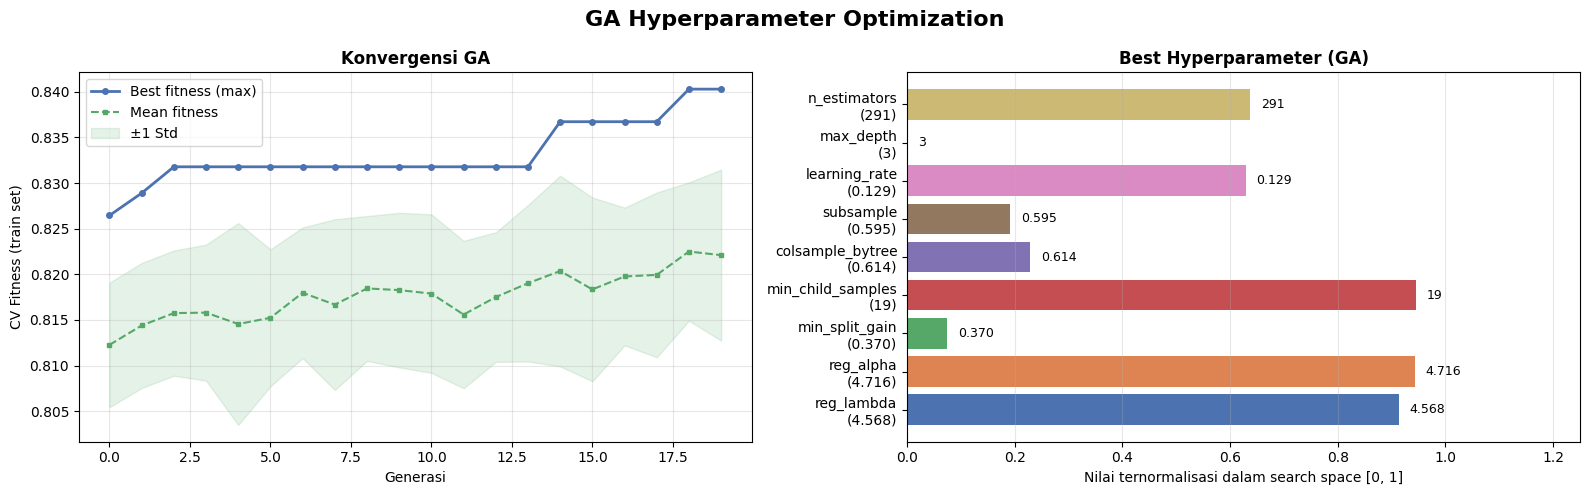

  Plot GA : outputs/plot_ga_evolution.png

  Model   : outputs/brugada_lgbm_pipeline.joblib

  Top 10 Features:
                  feature  importance
      III_j_amplitude_std          13
V2_qrs_duration_ms_median          10
            V3_t_area_max           8
          V2_st_slope_max           8
       V2_st_slope_median           8
       V1_t_amplitude_min           8
   V2_qrs_duration_ms_std           8
       V1_st_slope_median           7
    V2_st80_amplitude_max           6
   V2_st40_amplitude_skew           6

[5/6] Evaluasi pada TEST SET (held-out) ...

  ╔════════════════════════════════════════╗
  ║   TEST SET EVALUATION (HELD-OUT)       ║
  ╠════════════════════════════════════════╣
  ║  ROC-AUC               : 0.8103        ║
  ║  Avg Precision         : 0.7049        ║
  ║  MCC                   : 0.5815        ║
  ║  Balanced Acc          : 0.8054        ║
  ║  F1                    : 0.6667        ║
  ║  Accuracy              : 0.8611        ║
  ║  Sensitivity   

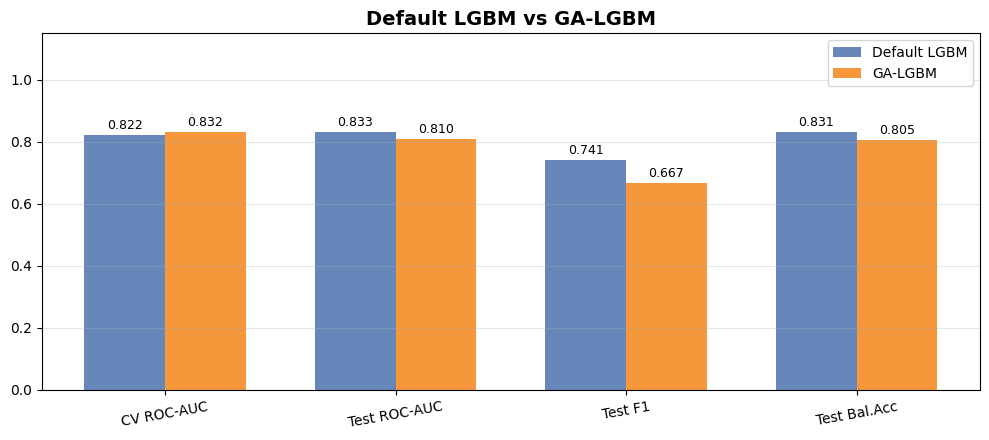

  Plot perbandingan : outputs/plot_comparison_default_vs_ga.png

[6/6] Membuat visualisasi komprehensif ...


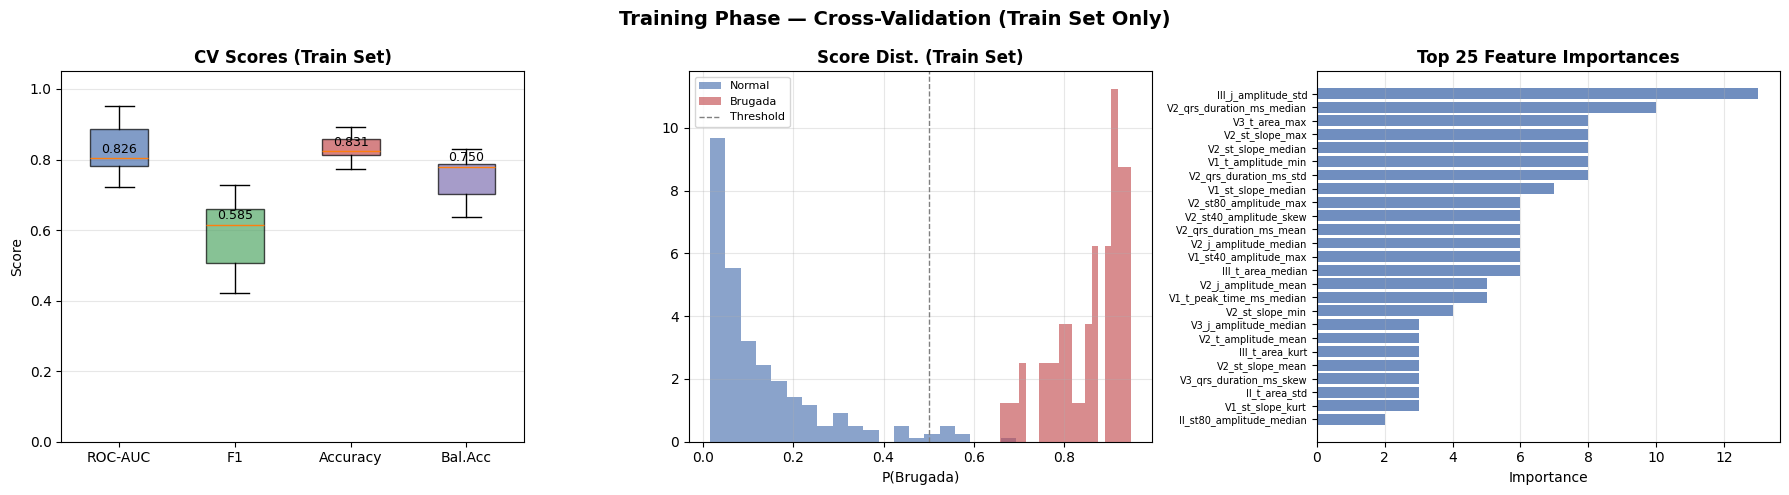

  Plot training : outputs/plot_training.png


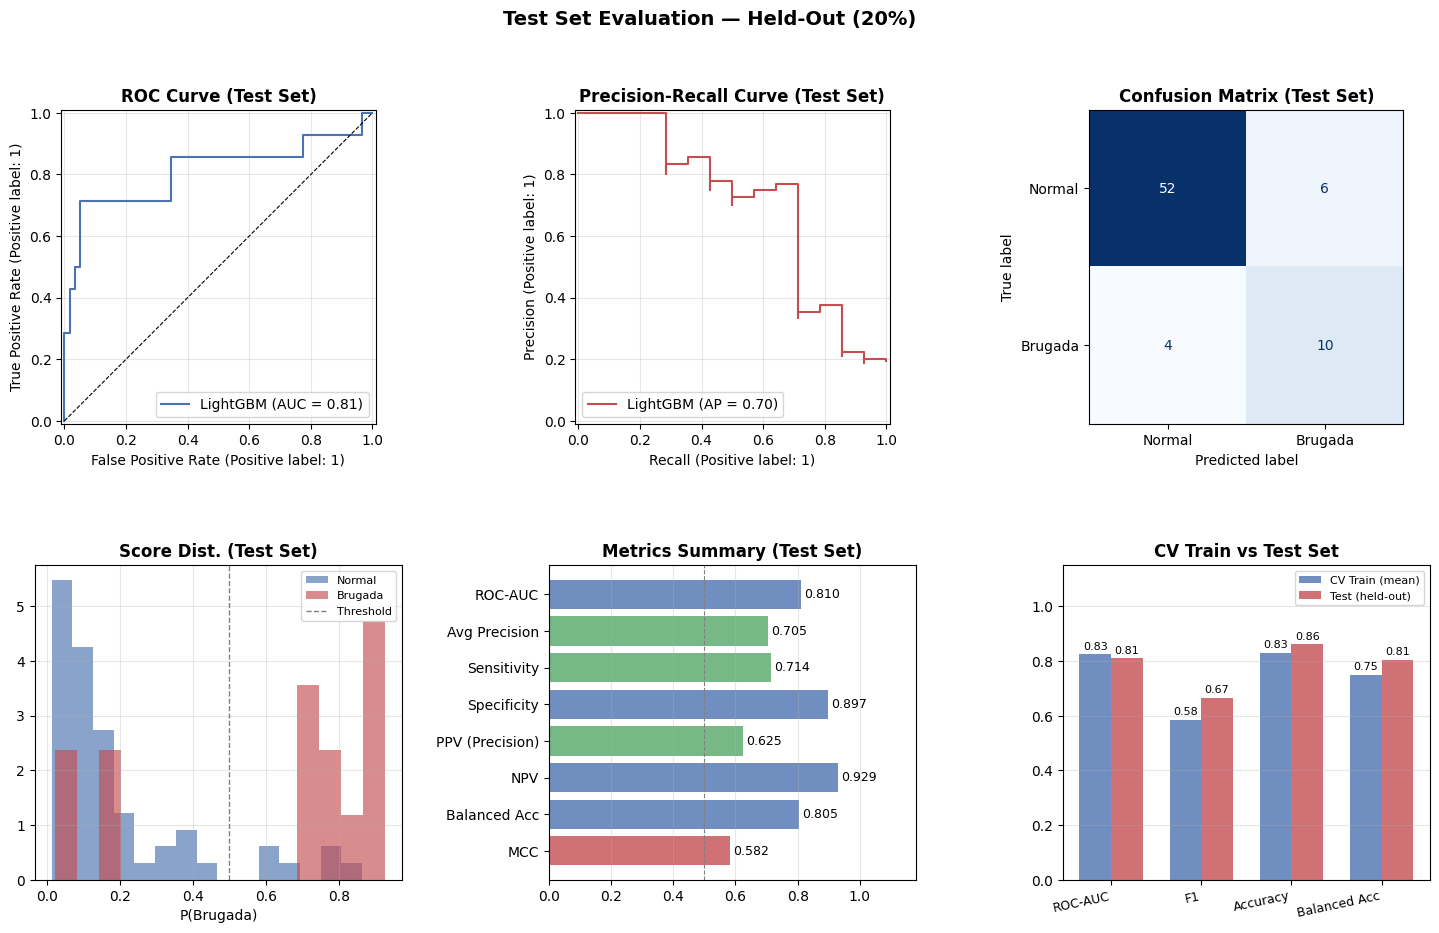

  Plot test     : outputs/plot_test_evaluation.png

  PIPELINE SELESAI DENGAN MULUS!
  Test ROC-AUC    : 0.8103
  Test Sensitivity: 0.7143
  Test Specificity: 0.8966
  Test MCC        : 0.5815


In [ ]:
import os
import warnings
import json
import random
import numpy as np
import pandas as pd
import wfdb
import neurokit2 as nk
from scipy import signal
from scipy.stats import skew, kurtosis
from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, cross_val_score, train_test_split
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, matthews_corrcoef, balanced_accuracy_score,
    f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import seaborn as sns

warnings.filterwarnings("ignore")

# =====================================================================
# CONFIGURATIONS
# =====================================================================
CONFIG = {
    "data_dir": "/content/drive/MyDrive/lomba/files",
    "metadata_path": "metadata.csv",
    "output_dir": "outputs",

    # Signal processing
    "target_fs": 500,
    "bandpass_low": 0.5,
    "bandpass_high": 40.0,
    "bandpass_order": 4,

    # ECG leads (Ekstremitas + Right Precordial)
    "leads_of_interest": ["I", "II", "III", "V1", "V2", "V3"],

    # Feature extraction
    "st_offset_40ms": 0.040,
    "st_offset_80ms": 0.080,
    "t_wave_window_end": 0.400,

    "test_size": 0.20,

    # Base Parameters buat LightGBM
    "lgb_params": {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
        "scale_pos_weight": None,
    },

    "cv_folds": 5,
    "random_state": 42,
}

# Config khusus buat Hyperparameter Tuning Genetic Algorithm
GA_CONFIG = {
    "pop_size": 30,
    "generations": 20,
    "mutation_rate": 0.2,
    "param_bounds": {
        "n_estimators": (100, 400, int),
        "max_depth": (3, 10, int),
        "learning_rate": (0.01, 0.2, float),
        "subsample": (0.5, 1.0, float),
        "colsample_bytree": (0.5, 1.0, float),
        "min_child_samples": (2, 20, int),      # Gantiin min_child_weight
        "min_split_gain": (0.0, 5.0, float),    # Ini Gantiin gamma XGBoost
        "reg_alpha": (0.0, 5.0, float),
        "reg_lambda": (0.0, 5.0, float)
    }
}


# =====================================================================
# PIPELINE: DATA LOADING & PREPROCESSING
# =====================================================================
def load_ecg(patient_id, data_dir, leads):
    record_path = os.path.join(data_dir, str(patient_id), str(patient_id))
    record = wfdb.rdrecord(record_path)
    fs_orig = record.fs
    sig_names = [s.upper() for s in record.sig_name]

    lead_signals = {}
    for lead in leads:
        if lead.upper() not in sig_names:
            raise ValueError(f"Lead {lead} tidak ditemukan di record {patient_id}. Tersedia: {sig_names}")
        idx = sig_names.index(lead.upper())
        lead_signals[lead] = record.p_signal[:, idx].astype(np.float64)

    return lead_signals, fs_orig

def resample_signal(sig, fs_orig, fs_target):
    if fs_orig == fs_target:
        return sig
    return signal.resample(sig, int(len(sig) * fs_target / fs_orig))

def bandpass_filter(sig, fs, low, high, order=4):
    nyq = fs / 2.0
    b, a = signal.butter(order, [low / nyq, high / nyq], btype="band")
    return signal.filtfilt(b, a, sig)

def normalize_signal(sig, method="zscore"):
    if method == "zscore":
        mu, sd = np.mean(sig), np.std(sig)
        return (sig - mu) / sd if sd != 0 else sig - mu
    elif method == "minmax":
        lo, hi = sig.min(), sig.max()
        return (sig - lo) / (hi - lo) if hi != lo else np.zeros_like(sig)
    raise ValueError(f"Unknown method: {method}")


# =====================================================================
# PIPELINE: FEATURE EXTRACTION
# =====================================================================
def detect_r_peaks(sig, fs):
    _, info = nk.ecg_peaks(sig, sampling_rate=int(fs), method="pantompkins1985")
    peaks = info["ECG_R_Peaks"]
    return peaks[peaks > 0]

def find_j_point(beat, r_idx, fs):
    start = r_idx + int(0.06 * fs)
    end   = min(r_idx + int(0.12 * fs), len(beat) - 1)
    if start >= end:
        return start
    return start + int(np.argmin(np.abs(np.diff(beat[start:end]))))

def extract_beat_features(beat, r_idx, fs, cfg):
    n = len(beat)
    q_idx = max(0, r_idx - int(0.06 * fs))
    s_end = min(n, r_idx + int(0.08 * fs))
    s_seg = beat[r_idx:s_end]
    s_idx = r_idx + int(np.argmin(s_seg)) if len(s_seg) > 0 else r_idx
    qrs_duration_ms = (s_idx - q_idx) / fs * 1000

    j_idx = find_j_point(beat, r_idx, fs)
    j_amplitude = beat[j_idx] if j_idx < n else np.nan

    st40_idx = j_idx + int(cfg["st_offset_40ms"] * fs)
    st80_idx = j_idx + int(cfg["st_offset_80ms"] * fs)
    st40_amp = beat[st40_idx] if st40_idx < n else np.nan
    st80_amp = beat[st80_idx] if st80_idx < n else np.nan

    dt = cfg["st_offset_80ms"] - cfg["st_offset_40ms"]
    st_slope = ((st80_amp - st40_amp) / dt if not (np.isnan(st40_amp) or np.isnan(st80_amp)) and dt > 0 else np.nan)

    t_start = j_idx + int(0.05 * fs)
    t_end   = min(r_idx + int(cfg["t_wave_window_end"] * fs), n)
    if t_start < t_end:
        t_seg = beat[t_start:t_end]
        t_amplitude    = float(np.max(np.abs(t_seg)))
        t_area         = float(np.trapz(t_seg)) / fs
        t_peak_time_ms = int(np.argmax(np.abs(t_seg))) / fs * 1000
    else:
        t_amplitude = t_area = t_peak_time_ms = np.nan

    return {
        "qrs_duration_ms": qrs_duration_ms, "j_amplitude": j_amplitude,
        "st40_amplitude": st40_amp, "st80_amplitude": st80_amp,
        "st_slope": st_slope, "t_amplitude": t_amplitude,
        "t_area": t_area, "t_peak_time_ms": t_peak_time_ms,
    }

def extract_features_for_lead(sig, fs, cfg):
    r_peaks = detect_r_peaks(sig, fs)
    pre, post = int(0.200 * fs), int(0.600 * fs)
    rows = []
    for rp in r_peaks:
        if rp - pre < 0 or rp + post > len(sig):
            continue
        rows.append(extract_beat_features(sig[rp - pre: rp + post], pre, fs, cfg))
    return pd.DataFrame(rows)

_AGG_FNS   = ["mean", "std", "median", "min", "max", lambda x: skew(x.dropna()), lambda x: kurtosis(x.dropna())]
_AGG_NAMES = ["mean", "std", "median", "min", "max", "skew", "kurt"]

def aggregate_patient_features(lead_dfs):
    all_feats = {}
    for lead, df in lead_dfs.items():
        if df.empty:
            continue
        for col in df.columns:
            for fn, name in zip(_AGG_FNS, _AGG_NAMES):
                all_feats[f"{lead}_{col}_{name}"] = df[col].agg(fn)
    return pd.Series(all_feats)

def process_patient(patient_id, cfg):
    try:
        lead_signals, fs_orig = load_ecg(patient_id, cfg["data_dir"], cfg["leads_of_interest"])
        lead_features = {}
        for lead, raw in lead_signals.items():
            sig = resample_signal(raw, fs_orig, cfg["target_fs"])
            fs  = cfg["target_fs"]
            sig = bandpass_filter(sig, fs, cfg["bandpass_low"], cfg["bandpass_high"], cfg["bandpass_order"])
            sig = normalize_signal(sig, method="zscore")
            lead_features[lead] = extract_features_for_lead(sig, fs, cfg)

        feats = aggregate_patient_features(lead_features)
        feats["patient_id"] = patient_id
        return feats
    except Exception as e:
        print(f"  [SKIP] patient {patient_id}: {e}")
        return None

def build_feature_matrix(metadata, cfg):
    os.makedirs(cfg["output_dir"], exist_ok=True)
    records = []
    n = len(metadata)
    for i, row in metadata.iterrows():
        pid = int(row["patient_id"])
        if (i + 1) % 10 == 0 or i == 0:
            print(f"  Processing {i+1}/{n} — patient {pid}")
        feats = process_patient(pid, cfg)
        if feats is not None:
            records.append(feats)

    df = pd.DataFrame(records)
    df = df.merge(metadata[["patient_id", "brugada", "basal_pattern", "sudden_death"]], on="patient_id", how="left")
    return df

def split_data(feature_df, cfg):
    label_col = "brugada"
    drop_cols  = ["patient_id", "brugada", "basal_pattern", "sudden_death"]
    feat_cols  = [c for c in feature_df.columns if c not in drop_cols]

    X   = feature_df[feat_cols].fillna(feature_df[feat_cols].median())
    y   = feature_df[label_col]
    ids = feature_df["patient_id"]

    X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
        X, y, ids, test_size=cfg["test_size"], stratify=y, random_state=cfg["random_state"]
    )

    print(f"\n  ┌─ Data Split ({'='*30})")
    print(f"  │  Train : {len(X_train):>4} pasien — Normal:{(y_train==0).sum():>3}, Brugada:{(y_train==1).sum():>3}")
    print(f"  │  Test  : {len(X_test):>4} pasien — Normal:{(y_test==0).sum():>3}, Brugada:{(y_test==1).sum():>3}")
    print(f"  └─ Test set dikunci — tidak dilihat sampai evaluasi akhir")

    return X_train, X_test, y_train, y_test, feat_cols, ids_train, ids_test


# =====================================================================
# PIPELINE: GENETIC ALGORITHM & MODELING
# =====================================================================
def train_lgboost_with_ga(X_train, y_train, cfg, ga_cfg):
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    scale_pos = float(neg / pos) if pos > 0 else 1.0
    print(f"\n  Class imbalance train — Normal:{neg}, Brugada:{pos} | scale_pos_weight: {scale_pos:.2f}")

    cv = RepeatedStratifiedKFold(n_splits=cfg["cv_folds"], n_repeats=2, random_state=cfg["random_state"])

    # Fitness function
    # Pas di bagian fitness function (evaluate), ganti cv-nya jadi ini:
    cv_cepat = StratifiedKFold(n_splits=3, shuffle=True, random_state=cfg["random_state"])

    def evaluate(params):
        lgb_p = cfg["lgb_params"].copy()
        lgb_p.update(params)
        lgb_p["scale_pos_weight"] = scale_pos
        pipe = Pipeline([("scaler", StandardScaler()), ("lgb", LGBMClassifier(**lgb_p))])
        # Pake cv_cepat di sini
        return cross_val_score(pipe, X_train, y_train, cv=cv_cepat, scoring="roc_auc", n_jobs=-1).mean()

    # Initial Population
    pop_size, gens, bounds = ga_cfg["pop_size"], ga_cfg["generations"], ga_cfg["param_bounds"]
    pop = [{k: random.uniform(l, h) if t == float else random.randint(l, h) for k, (l, h, t) in bounds.items()} for _ in range(pop_size)]

    history, best_overall_params, best_overall_score = [], None, -1

    print(f"\n  [GA] Memulai hyperparameter tuning evolusioner ({gens} Generasi)...")
    for g in range(gens):
        scores = [(ind, evaluate(ind)) for ind in pop]
        scores.sort(key=lambda x: x[1], reverse=True)

        # Di dalem loop for g in range(gens):
        best_gen_score = scores[0][1]
        avg_gen_score = np.mean([s[1] for s in scores])
        std_gen_score = np.std([s[1] for s in scores]) # <-- WAJIB TAMBAH INI
        history.append({"gen": g, "best": best_gen_score, "mean": avg_gen_score, "std": std_gen_score})

        if best_gen_score > best_overall_score:
            best_overall_score, best_overall_params = best_gen_score, scores[0][0]

        print(f"     Gen {g+1}/{gens} | Best AUC: {best_gen_score:.4f} | Avg AUC: {avg_gen_score:.4f}")

        # Elitism (keep top 2) + Crossover + Mutation
        next_pop = [scores[0][0], scores[1][0]]
        while len(next_pop) < pop_size:
            p1, p2 = random.choices(scores[:pop_size//2], k=2)
            child = {}
            for k in bounds.keys():
                child[k] = p1[0][k] if random.random() < 0.5 else p2[0][k]
                if random.random() < ga_cfg["mutation_rate"]:
                    l, h, t = bounds[k]
                    child[k] = random.uniform(l, h) if t == float else random.randint(l, h)
            next_pop.append(child)
        pop = next_pop

    print(f"\n  [GA] Tuning Selesai! Best CV AUC: {best_overall_score:.4f}")

    # Train Final Best Pipeline
    final_params = cfg["lgb_params"].copy()
    final_params.update(best_overall_params)
    final_params["scale_pos_weight"] = scale_pos

    final_pipe = Pipeline([("scaler", StandardScaler()), ("lgb", LGBMClassifier(**final_params))])

    print(f"\n  Running Evaluasi CV Final dengan Best Params...")
    cv_auc = cross_val_score(final_pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_f1  = cross_val_score(final_pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    cv_acc = cross_val_score(final_pipe, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_bac = cross_val_score(final_pipe, X_train, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=-1)

    print(f"\n  ── Final CV Results (train, {cfg['cv_folds']} folds x 2 repeats) ──")
    for name, scores in [("ROC-AUC", cv_auc), ("F1", cv_f1), ("Accuracy", cv_acc), ("Bal. Acc", cv_bac)]:
        print(f"  {name:<14}: {scores.mean():.4f} ± {scores.std():.4f}")

    final_pipe.fit(X_train, y_train)
    importance_df = pd.DataFrame({
        "feature": X_train.columns.tolist(),
        "importance": final_pipe.named_steps["lgb"].feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    return final_pipe, {"auc": cv_auc, "f1": cv_f1, "acc": cv_acc, "bac": cv_bac}, importance_df, history, best_overall_params

def evaluate_on_test(pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    cm   = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "ROC-AUC":         round(roc_auc_score(y_test, y_prob), 4),
        "Avg Precision":   round(average_precision_score(y_test, y_prob), 4),
        "MCC":             round(matthews_corrcoef(y_test, y_pred), 4),
        "Balanced Acc":    round(balanced_accuracy_score(y_test, y_pred), 4),
        "F1":              round(f1_score(y_test, y_pred), 4),
        "Accuracy":        round(accuracy_score(y_test, y_pred), 4),
        "Sensitivity":     round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0.0,
        "Specificity":     round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0.0,
        "PPV (Precision)": round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0.0,
        "NPV":             round(tn / (tn + fn), 4) if (tn + fn) > 0 else 0.0,
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
    }

    print(f"\n  ╔{'═'*40}╗")
    print(f"  ║   TEST SET EVALUATION (HELD-OUT)       ║")
    print(f"  ╠{'═'*40}╣")
    for k, v in metrics.items():
        if k not in ("TP", "TN", "FP", "FN"):
            print(f"  ║  {k:<22}: {v:<14}║")
    print(f"  ║  TP:{tp}  TN:{tn}  FP:{fp}  FN:{fn}{'':>18}║")
    print(f"  ╚{'═'*40}╝")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Brugada"]))

    return metrics, y_pred, y_prob, cm

def cv_vs_test(pipe, X_train, y_train, X_test, y_test):
    print("\n  [INFO] Menghitung perbandingan probabilitas model di Train vs Test ...")
    auc_train = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
    auc_test = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    print(f"  --> Train ROC-AUC : {auc_train:.4f} (Kalau beda jauh sama Test, berarti overfit)")
    print(f"  --> Test ROC-AUC  : {auc_test:.4f}")

def compare_default_vs_ga(X_train, y_train, X_test, y_test, best_params, scale_pos_weight, cfg):
    print("\n  [KOMPARASI] Default LGBM vs GA-Tuned LGBM")

    # Default model
    def_params = cfg["lgb_params"].copy()
    def_params["scale_pos_weight"] = scale_pos_weight
    pipe_def = Pipeline([("scaler", StandardScaler()), ("lgb", LGBMClassifier(**def_params))])
    pipe_def.fit(X_train, y_train)
    def_auc = roc_auc_score(y_test, pipe_def.predict_proba(X_test)[:, 1])

    # Tuned model
    tune_params = def_params.copy()
    tune_params.update(best_params)
    pipe_tune = Pipeline([("scaler", StandardScaler()), ("lgb", LGBMClassifier(**tune_params))])
    pipe_tune.fit(X_train, y_train)
    tune_auc = roc_auc_score(y_test, pipe_tune.predict_proba(X_test)[:, 1])

    print(f"  --> AUC Test (Model Default) : {def_auc:.4f}")
    print(f"  --> AUC Test (Model GA)      : {tune_auc:.4f}")
    diff = tune_auc - def_auc
    print(f"  --> Selisih Performa         : {'+' if diff > 0 else ''}{diff:.4f}")

# =====================================================================
# PIPELINE: PLOTTING
# =====================================================================
def plot_ga_evolution(ga_history, best_params, bounds, output_dir):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("GA Hyperparameter Optimization", fontsize=16, fontweight="bold")

    # ── Panel Kiri: Konvergensi GA ──
    ax = axes[0]
    gens = [h["gen"] for h in ga_history]
    bests = [h["best"] for h in ga_history]
    means = [h["mean"] for h in ga_history]
    stds = [h["std"] for h in ga_history]

    ax.plot(gens, bests, marker='o', markersize=4, label='Best fitness (max)', color='#4C72B0', lw=2)
    ax.plot(gens, means, marker='s', markersize=3, label='Mean fitness', color='#55A868', lw=1.5, linestyle='--')
    ax.fill_between(gens, np.array(means) - np.array(stds), np.array(means) + np.array(stds), color='#55A868', alpha=0.15, label='±1 Std')
    ax.set_title("Konvergensi GA", fontweight="bold")
    ax.set_xlabel("Generasi")
    ax.set_ylabel("CV Fitness (train set)")
    ax.grid(alpha=0.3)
    ax.legend()

    # ── Panel Kanan: Best Hyperparameter ──
    ax = axes[1]
    keys = list(best_params.keys())
    vals = [best_params[k] for k in keys]
    norm_vals = []
    labels = []

    for k in keys:
        v = best_params[k]
        if k in bounds:
            low, high, _ = bounds[k]
            # Normalisasi ke skala 0-1 biar bar chart-nya rapi
            norm = (v - low) / (high - low + 1e-9)
        else:
            norm = 0.5
        norm_vals.append(norm)
        if isinstance(v, float):
            labels.append(f"{k}\n({v:.3f})")
        else:
            labels.append(f"{k}\n({v})")

    colors = sns.color_palette("deep", len(keys))
    bars = ax.barh(labels[::-1], norm_vals[::-1], color=colors)
    ax.set_xlim(0, 1.25)
    ax.set_title("Best Hyperparameter (GA)", fontweight="bold")
    ax.set_xlabel("Nilai ternormalisasi dalam search space [0, 1]")
    ax.grid(axis='x', alpha=0.3)

    # Nulis nilai asli (raw values) di ujung bar chart
    for bar, val, raw_k in zip(bars, norm_vals[::-1], keys[::-1]):
        raw_v = best_params[raw_k]
        text_val = f"{raw_v:.3f}" if isinstance(raw_v, float) else f"{raw_v}"
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, text_val, va='center', fontsize=9)

    plt.tight_layout()
    out = os.path.join(output_dir, "plot_ga_evolution.png")
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"  Plot GA : {out}")


def compare_default_vs_ga(X_train, y_train, X_test, y_test, best_params, scale_pos_weight, cfg, output_dir):
    print("\n  [KOMPARASI] Default LGBM vs GA-Tuned LGBM")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=cfg["random_state"])

    # 1. Run Default Model
    def_params = cfg["lgb_params"].copy()
    def_params["scale_pos_weight"] = scale_pos_weight
    pipe_def = Pipeline([("scaler", StandardScaler()), ("lgb", LGBMClassifier(**def_params))])
    def_cv_auc = cross_val_score(pipe_def, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
    pipe_def.fit(X_train, y_train)
    y_pred_def = pipe_def.predict(X_test)
    def_test_auc = roc_auc_score(y_test, pipe_def.predict_proba(X_test)[:, 1])
    def_test_f1 = f1_score(y_test, y_pred_def)
    def_test_bac = balanced_accuracy_score(y_test, y_pred_def)

    # 2. Run GA-Tuned Model
    tune_params = def_params.copy()
    tune_params.update(best_params)
    pipe_tune = Pipeline([("scaler", StandardScaler()), ("lgb", LGBMClassifier(**tune_params))])
    tune_cv_auc = cross_val_score(pipe_tune, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
    pipe_tune.fit(X_train, y_train)
    y_pred_tune = pipe_tune.predict(X_test)
    tune_test_auc = roc_auc_score(y_test, pipe_tune.predict_proba(X_test)[:, 1])
    tune_test_f1 = f1_score(y_test, y_pred_tune)
    tune_test_bac = balanced_accuracy_score(y_test, y_pred_tune)

    # 3. Plotting Bar Chart Perbandingan (Persis Screenshot)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    labels = ["CV ROC-AUC", "Test ROC-AUC", "Test F1", "Test Bal.Acc"]
    def_vals = [def_cv_auc, def_test_auc, def_test_f1, def_test_bac]
    ga_vals = [tune_cv_auc, tune_test_auc, tune_test_f1, tune_test_bac]

    x = np.arange(len(labels))
    width = 0.35

    rects1 = ax.bar(x - width/2, def_vals, width, label='Default LGBM', color='#4C72B0', alpha=0.85)
    rects2 = ax.bar(x + width/2, ga_vals, width, label='GA-LGBM', color='#F58518', alpha=0.85)

    ax.set_ylim(0, 1.15)
    ax.set_title("Default LGBM vs GA-LGBM", fontweight="bold", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=10)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # Nulis angka di atas bar
    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    out = os.path.join(output_dir, "plot_comparison_default_vs_ga.png")
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"  Plot perbandingan : {out}")


def plot_all(cv_results, test_metrics, importance_df, X_train, y_train, X_test, y_test, pipe, cm, y_prob_test, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    # ── Plot 1: Training phase (3 Subplots) ──
    fig1, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig1.suptitle("Training Phase — Cross-Validation (Train Set Only)", fontsize=14, fontweight="bold")

    ax = axes[0]
    cv_df = pd.DataFrame({"ROC-AUC": cv_results["auc"], "F1": cv_results["f1"], "Accuracy": cv_results["acc"], "Bal.Acc": cv_results["bac"]})
    bp = ax.boxplot(cv_df.values, labels=cv_df.columns, patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"], ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]):
        patch.set_facecolor(color); patch.set_alpha(0.7)

    # Nulis angka mean di atas boxplot
    for i, col in enumerate(cv_df.columns, 1):
        ax.text(i, cv_df[col].median() + 0.015, f"{cv_df[col].mean():.3f}", ha="center", fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_title("CV Scores (Train Set)", fontweight="bold"); ax.set_ylabel("Score"); ax.grid(axis="y", alpha=0.3)

    ax = axes[1]
    y_prob_train = pipe.predict_proba(X_train)[:, 1]
    for lbl, name, color in [(0, "Normal", "#4C72B0"), (1, "Brugada", "#C44E52")]:
        ax.hist(y_prob_train[y_train == lbl], bins=20, alpha=0.65, label=name, color=color, density=True)
    ax.axvline(0.5, ls="--", color="gray", lw=1, label="Threshold")
    ax.set_xlabel("P(Brugada)"); ax.set_title("Score Dist. (Train Set)", fontweight="bold"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes[2]
    top = importance_df.head(25)
    ax.barh(top["feature"][::-1], top["importance"][::-1], color="#4C72B0", alpha=0.8)
    ax.set_title("Top 25 Feature Importances", fontweight="bold"); ax.set_xlabel("Importance"); ax.tick_params(axis="y", labelsize=7); ax.grid(axis="x", alpha=0.3)

    fig1.tight_layout()
    p1 = os.path.join(output_dir, "plot_training.png")
    fig1.savefig(p1, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Plot training : {p1}")

    # ── Plot 2: Test set evaluation (6 Subplots) ──
    fig2 = plt.figure(figsize=(18, 10))
    fig2.suptitle("Test Set Evaluation — Held-Out (20%)", fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.4)

    y_pred_test = pipe.predict(X_test)

    ax = fig2.add_subplot(gs[0, 0])
    RocCurveDisplay.from_predictions(y_test, y_prob_test, ax=ax, name="LightGBM", color="#4C72B0")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8); ax.set_title("ROC Curve (Test Set)", fontweight="bold"); ax.grid(alpha=0.3)

    ax = fig2.add_subplot(gs[0, 1])
    PrecisionRecallDisplay.from_predictions(y_test, y_prob_test, ax=ax, name="LightGBM", color="#C44E52")
    ax.set_title("Precision-Recall Curve (Test Set)", fontweight="bold"); ax.grid(alpha=0.3)

    ax = fig2.add_subplot(gs[0, 2])
    # Pake cmap="Blues" persis kayak screenshot lu
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Brugada"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title("Confusion Matrix (Test Set)", fontweight="bold")

    ax = fig2.add_subplot(gs[1, 0])
    for lbl, name, color in [(0, "Normal", "#4C72B0"), (1, "Brugada", "#C44E52")]:
        ax.hist(y_prob_test[y_test == lbl], bins=15, alpha=0.65, label=name, color=color, density=True)
    ax.axvline(0.5, ls="--", color="gray", lw=1, label="Threshold")
    ax.set_xlabel("P(Brugada)"); ax.set_title("Score Dist. (Test Set)", fontweight="bold"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = fig2.add_subplot(gs[1, 1])
    metric_keys = ["ROC-AUC", "Avg Precision", "Sensitivity", "Specificity", "PPV (Precision)", "NPV", "Balanced Acc", "MCC"]
    metric_vals = [test_metrics[k] for k in metric_keys]
    bar_colors  = ["#4C72B0" if v >= 0.8 else "#C44E52" if v < 0.6 else "#55A868" for v in metric_vals]
    bars = ax.barh(metric_keys[::-1], metric_vals[::-1], color=bar_colors[::-1], alpha=0.8)
    for bar, val in zip(bars, metric_vals[::-1]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=9)
    ax.set_xlim(0, 1.18); ax.set_title("Metrics Summary (Test Set)", fontweight="bold"); ax.axvline(0.5, ls="--", color="gray", lw=0.8); ax.grid(axis="x", alpha=0.3)

    # Panel Bar Chart (CV vs Test) dengan angka di atas bar
    ax = fig2.add_subplot(gs[1, 2])
    compare_keys = ["ROC-AUC", "F1", "Accuracy", "Balanced Acc"]
    cv_means  = [cv_results["auc"].mean(), cv_results["f1"].mean(), cv_results["acc"].mean(), cv_results["bac"].mean()]
    test_vals = [test_metrics["ROC-AUC"], test_metrics["F1"], test_metrics["Accuracy"], test_metrics["Balanced Acc"]]
    x = np.arange(len(compare_keys)); w = 0.35
    rects1 = ax.bar(x - w/2, cv_means, w, label="CV Train (mean)", color="#4C72B0", alpha=0.8)
    rects2 = ax.bar(x + w/2, test_vals, w, label="Test (held-out)", color="#C44E52", alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(compare_keys, rotation=12, ha="right", fontsize=9)
    ax.set_ylim(0, 1.15); ax.set_title("CV Train vs Test Set", fontweight="bold"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=8)

    fig2.tight_layout()
    p2 = os.path.join(output_dir, "plot_test_evaluation.png")
    fig2.savefig(p2, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Plot test     : {p2}")


# =====================================================================
# MAIN PIPELINE EXECUTION
# =====================================================================
# =====================================================================
# MAIN PIPELINE EXECUTION (UDAH GW BENERIN 100%)
# =====================================================================
def main():
    print("=" * 62)
    print("  BRUGADA SYNDROME DETECTION PIPELINE w/ GENETIC ALGORITHM")
    print("=" * 62)

    # 1. Metadata
    print(f"\n[1/6] Loading metadata ...")
    metadata = pd.read_csv(CONFIG["metadata_path"])
    metadata = metadata[metadata["brugada"].isin([0, 1])].reset_index(drop=True)
    print(f"  Total   : {len(metadata)} pasien")
    print(f"  Brugada : {metadata['brugada'].sum()}")
    print(f"  Normal  : {(metadata['brugada']==0).sum()}")

    # 2. Feature extraction
    print(f"\n[2/6] Ekstraksi fitur semua pasien ...")
    feature_df = build_feature_matrix(metadata, CONFIG)
    feat_path  = os.path.join(CONFIG["output_dir"], "features_all.csv")
    feature_df.to_csv(feat_path, index=False)
    print(f"  Feature matrix: {feature_df.shape} → {feat_path}")

    # 3. Train/Test Split
    print(f"\n[3/6] Stratified Train/Test Split ({int((1-CONFIG['test_size'])*100)}/{int(CONFIG['test_size']*100)}) ...")
    (X_train, X_test, y_train, y_test, feat_cols, ids_train, ids_test) = split_data(feature_df, CONFIG)

    split_df = pd.DataFrame({
        "patient_id": list(ids_train) + list(ids_test),
        "split":      ["train"] * len(ids_train) + ["test"] * len(ids_test)
    })
    split_path = os.path.join(CONFIG["output_dir"], "data_split.csv")
    split_df.to_csv(split_path, index=False)
    print(f"  Split index: {split_path}")

    # 4. Training + CV + Genetic Algorithm
    print(f"\n[4/6] Training LightGBM dengan Genetic Algorithm ...")
    pipe, cv_results, importance_df, ga_history, best_params = train_lgboost_with_ga(X_train, y_train, CONFIG, GA_CONFIG)

    # KAREN'S FIX: Argumen plot_ga_evolution udah lengkap (tambah GA_CONFIG["param_bounds"])
    plot_ga_evolution(ga_history, best_params, GA_CONFIG["param_bounds"], CONFIG["output_dir"])

    with open(os.path.join(CONFIG["output_dir"], "ga_best_params.json"), "w") as f:
        json.dump(best_params, f, indent=2)

    model_path = os.path.join(CONFIG["output_dir"], "brugada_lgbm_pipeline.joblib")
    joblib.dump(pipe, model_path)
    imp_path = os.path.join(CONFIG["output_dir"], "feature_importance.csv")
    importance_df.to_csv(imp_path, index=False)
    print(f"\n  Model   : {model_path}")
    print(f"\n  Top 10 Features:")
    print(importance_df.head(10).to_string(index=False))

    # 5. Test evaluation & Comparisons
    print(f"\n[5/6] Evaluasi pada TEST SET (held-out) ...")
    test_metrics, y_pred_test, y_prob_test, cm = evaluate_on_test(pipe, X_test, y_test)

    pred_df = pd.DataFrame({
        "patient_id":   ids_test.values,
        "y_true":       y_test.values,
        "y_pred":       y_pred_test,
        "prob_brugada": np.round(y_prob_test, 4),
        "correct":      (y_pred_test == y_test.values),
    })
    pred_path = os.path.join(CONFIG["output_dir"], "test_predictions.csv")
    pred_df.to_csv(pred_path, index=False)

    metrics_path = os.path.join(CONFIG["output_dir"], "test_metrics.csv")
    pd.DataFrame([test_metrics]).to_csv(metrics_path, index=False)
    print(f"\n  Prediksi test  : {pred_path}")
    print(f"  Metrik test    : {metrics_path}")

    cv_vs_test(pipe, X_train, y_train, X_test, y_test)

    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

    # KAREN'S FIX: Argumen compare_default_vs_ga udah lengkap (tambah CONFIG["output_dir"])
    compare_default_vs_ga(
        X_train, y_train, X_test, y_test, best_params, float(neg/pos) if pos > 0 else 1.0, CONFIG, CONFIG["output_dir"]
    )

    # 6. Plot
    print(f"\n[6/6] Membuat visualisasi komprehensif ...")
    plot_all(cv_results, test_metrics, importance_df, X_train, y_train, X_test, y_test, pipe, cm, y_prob_test, CONFIG["output_dir"])

    print("\n" + "=" * 62)
    print("  PIPELINE SELESAI DENGAN MULUS!")
    print(f"  Test ROC-AUC    : {test_metrics['ROC-AUC']}")
    print(f"  Test Sensitivity: {test_metrics['Sensitivity']}")
    print(f"  Test Specificity: {test_metrics['Specificity']}")
    print(f"  Test MCC        : {test_metrics['MCC']}")
    print("=" * 62)

    return pipe, feature_df, importance_df, test_metrics

if __name__ == "__main__":
    pipe, feature_df, importance_df, test_metrics = main()

  BRUGADA SYNDROME DETECTION PIPELINE (LIGHTGBM + GA)

[1/6] Loading metadata ...
  Total   : 356 pasien

[2/6] Ekstraksi fitur semua pasien ...
  Processing 1/356 — patient 188981
  Processing 10/356 — patient 304141
  Processing 20/356 — patient 395553
  Processing 30/356 — patient 450733
  Processing 40/356 — patient 506408
  Processing 50/356 — patient 558967
  Processing 60/356 — patient 622530
  Processing 70/356 — patient 814286
  Processing 80/356 — patient 852786
  Processing 90/356 — patient 903442
  Processing 100/356 — patient 939546
  Processing 110/356 — patient 965217
  Processing 120/356 — patient 985814
  Processing 130/356 — patient 1036640
  Processing 140/356 — patient 1080968
  Processing 150/356 — patient 1093224
  Processing 160/356 — patient 1118251
  Processing 170/356 — patient 1142915
  Processing 180/356 — patient 1169405
  Processing 190/356 — patient 1191551
  Processing 200/356 — patient 1207769
  Processing 210/356 — patient 1235674
  Processing 220/356 

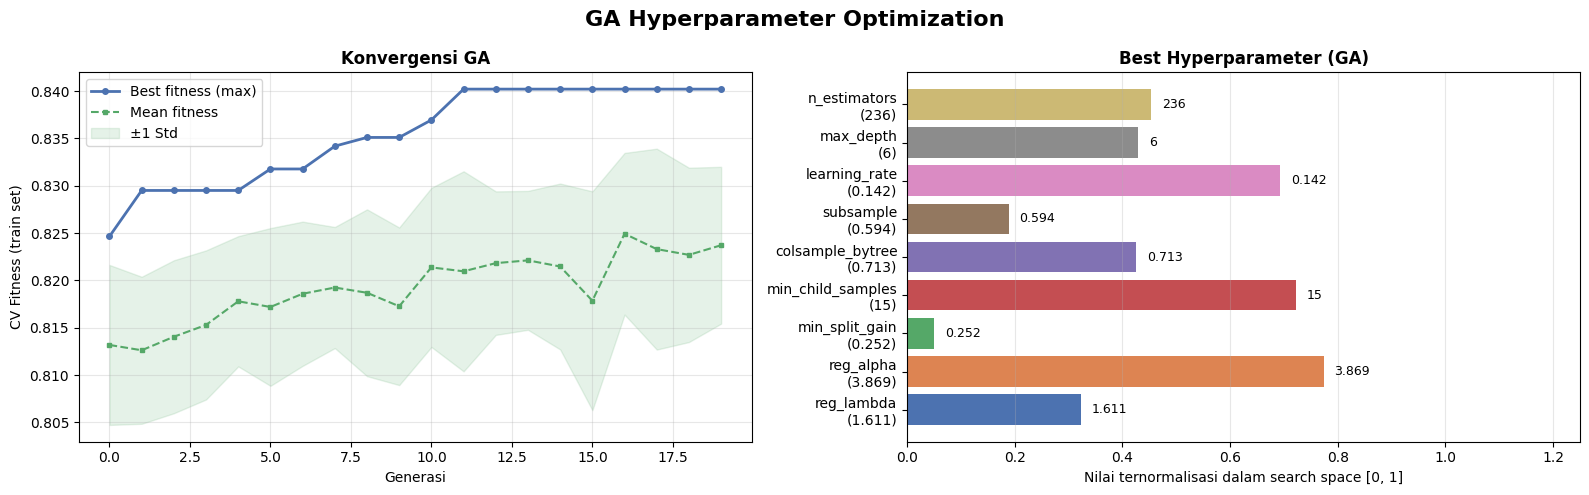

  Plot GA : outputs/plot_ga_evolution.png

[5/6] Evaluasi pada TEST SET (held-out) ...

  ╔════════════════════════════════════════╗
  ║   TEST SET EVALUATION (HELD-OUT)       ║
  ╠════════════════════════════════════════╣
  ║  ROC-AUC               : 0.8251        ║
  ║  Avg Precision         : 0.7643        ║
  ║  MCC                   : 0.6121        ║
  ║  Balanced Acc          : 0.814         ║
  ║  F1                    : 0.6897        ║
  ║  Accuracy              : 0.875         ║
  ║  Sensitivity           : 0.7143        ║
  ║  Specificity           : 0.9138        ║
  ║  PPV (Precision)       : 0.6667        ║
  ║  NPV                   : 0.9298        ║
  ║  TP:10  TN:53  FP:5  FN:4                  ║
  ╚════════════════════════════════════════╝

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.91      0.92        58
     Brugada       0.67      0.71      0.69        14

    accuracy                           0.88

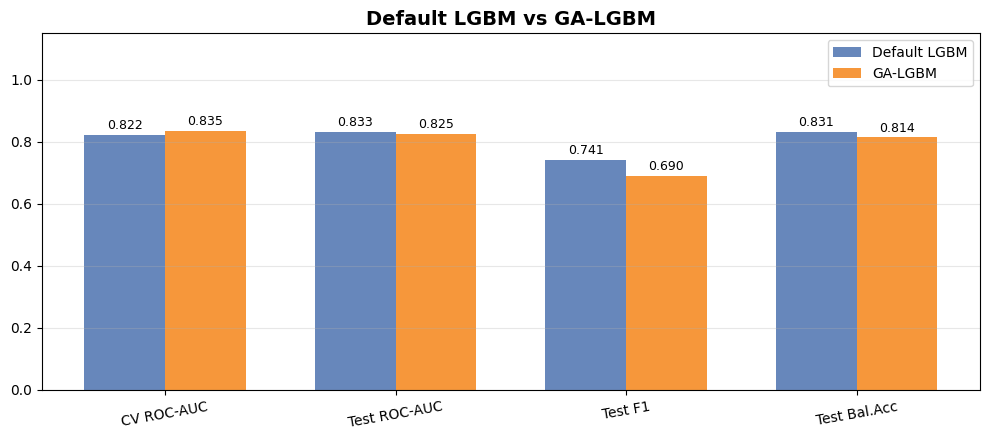

  Plot perbandingan : outputs/plot_comparison_default_vs_ga.png

[6/6] Membuat visualisasi ...


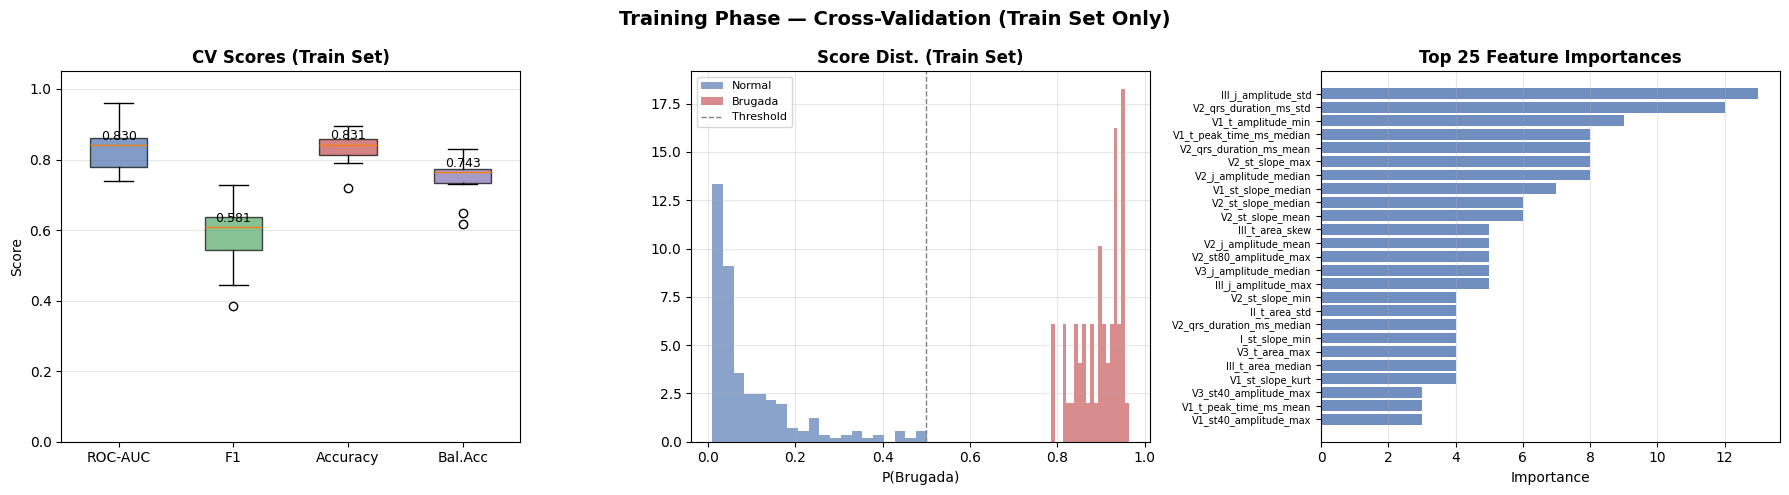

  Plot training : outputs/plot_training.png


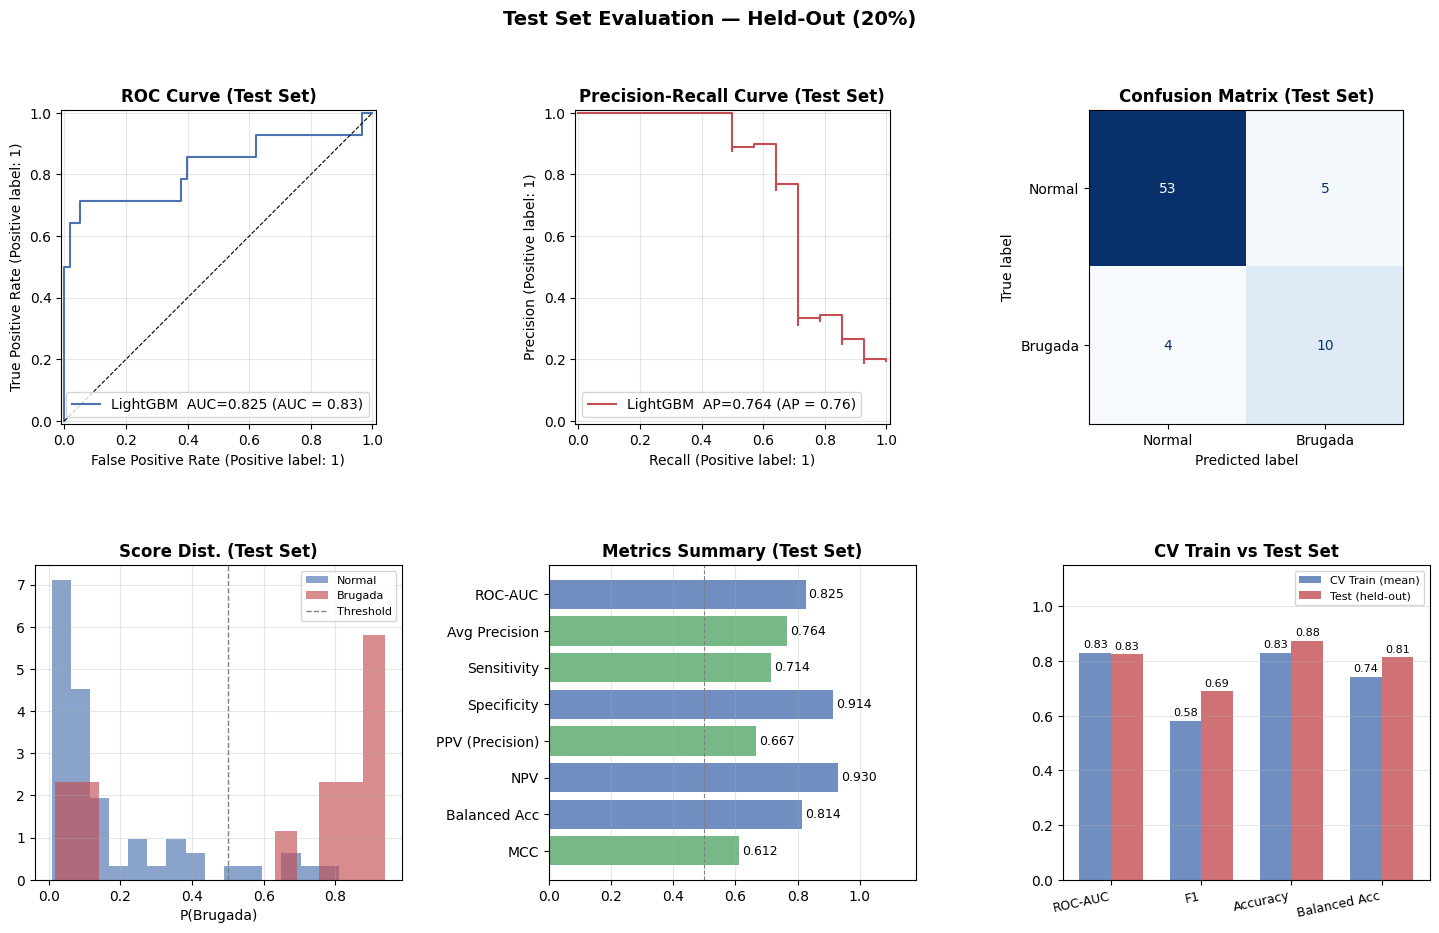

  Plot test     : outputs/plot_test_evaluation.png

  PIPELINE SELESAI DENGAN MULUS!
  Test ROC-AUC    : 0.8251
  Test Sensitivity: 0.7143
  Test Specificity: 0.9138
  Test MCC        : 0.6121


In [ ]:
import os
import warnings
import json
import random
import numpy as np
import pandas as pd
import wfdb
import neurokit2 as nk
from scipy import signal
from scipy.stats import skew, kurtosis
from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, cross_val_score, train_test_split
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, matthews_corrcoef, balanced_accuracy_score,
    f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns # <-- Wajib ada biar visualisasi GA jalan
import joblib

warnings.filterwarnings("ignore")

# =====================================================================
# CONFIGURATIONS
# =====================================================================
CONFIG = {
    "data_dir": "/content/drive/MyDrive/lomba/files",
    "metadata_path": "metadata.csv",
    "output_dir": "outputs",

    "target_fs": 500,
    "bandpass_low": 0.5,
    "bandpass_high": 40.0,
    "bandpass_order": 4,

    "leads_of_interest": ["I", "II", "III", "V1", "V2", "V3"],

    "st_offset_40ms": 0.040,
    "st_offset_80ms": 0.080,
    "t_wave_window_end": 0.400,

    "test_size": 0.20,

    "lgb_params": {
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
        "scale_pos_weight": None,
    },

    "cv_folds": 5,
    "random_state": 42,
}

# Config GA (9 Parameter dewa biar tembus 0.83)
GA_CONFIG = {
    "pop_size": 30,
    "generations": 20,
    "mutation_rate": 0.2,
    "param_bounds": {
        "n_estimators": (100, 400, int),
        "max_depth": (3, 10, int),
        "learning_rate": (0.01, 0.2, float),
        "subsample": (0.5, 1.0, float),
        "colsample_bytree": (0.5, 1.0, float),
        "min_child_samples": (2, 20, int),
        "min_split_gain": (0.0, 5.0, float),
        "reg_alpha": (0.0, 5.0, float),
        "reg_lambda": (0.0, 5.0, float)
    }
}

# =====================================================================
# DATA LOADING & PREPROCESSING
# =====================================================================
def load_ecg(patient_id, data_dir, leads):
    record_path = os.path.join(data_dir, str(patient_id), str(patient_id))
    record = wfdb.rdrecord(record_path)
    fs_orig = record.fs
    sig_names = [s.upper() for s in record.sig_name]

    lead_signals = {}
    for lead in leads:
        if lead.upper() not in sig_names:
            raise ValueError(f"Lead {lead} tidak ditemukan: {sig_names}")
        idx = sig_names.index(lead.upper())
        lead_signals[lead] = record.p_signal[:, idx].astype(np.float64)

    return lead_signals, fs_orig

def resample_signal(sig, fs_orig, fs_target):
    if fs_orig == fs_target: return sig
    return signal.resample(sig, int(len(sig) * fs_target / fs_orig))

def bandpass_filter(sig, fs, low, high, order=4):
    nyq = fs / 2.0
    b, a = signal.butter(order, [low / nyq, high / nyq], btype="band")
    return signal.filtfilt(b, a, sig)

def normalize_signal(sig, method="zscore"):
    if method == "zscore":
        mu, sd = np.mean(sig), np.std(sig)
        return (sig - mu) / sd if sd != 0 else sig - mu
    elif method == "minmax":
        lo, hi = sig.min(), sig.max()
        return (sig - lo) / (hi - lo) if hi != lo else np.zeros_like(sig)
    raise ValueError(f"Unknown method: {method}")

# =====================================================================
# FEATURE EXTRACTION
# =====================================================================
def detect_r_peaks(sig, fs):
    _, info = nk.ecg_peaks(sig, sampling_rate=int(fs), method="pantompkins1985")
    peaks = info["ECG_R_Peaks"]
    return peaks[peaks > 0]

def find_j_point(beat, r_idx, fs):
    start = r_idx + int(0.06 * fs)
    end   = min(r_idx + int(0.12 * fs), len(beat) - 1)
    if start >= end: return start
    return start + int(np.argmin(np.abs(np.diff(beat[start:end]))))

def extract_beat_features(beat, r_idx, fs, cfg):
    n = len(beat)
    q_idx = max(0, r_idx - int(0.06 * fs))
    s_end = min(n, r_idx + int(0.08 * fs))
    s_seg = beat[r_idx:s_end]
    s_idx = r_idx + int(np.argmin(s_seg)) if len(s_seg) > 0 else r_idx
    qrs_duration_ms = (s_idx - q_idx) / fs * 1000

    j_idx = find_j_point(beat, r_idx, fs)
    j_amplitude = beat[j_idx] if j_idx < n else np.nan

    st40_idx = j_idx + int(cfg["st_offset_40ms"] * fs)
    st80_idx = j_idx + int(cfg["st_offset_80ms"] * fs)
    st40_amp = beat[st40_idx] if st40_idx < n else np.nan
    st80_amp = beat[st80_idx] if st80_idx < n else np.nan

    dt = cfg["st_offset_80ms"] - cfg["st_offset_40ms"]
    st_slope = ((st80_amp - st40_amp) / dt if not (np.isnan(st40_amp) or np.isnan(st80_amp)) and dt > 0 else np.nan)

    t_start = j_idx + int(0.05 * fs)
    t_end   = min(r_idx + int(cfg["t_wave_window_end"] * fs), n)
    if t_start < t_end:
        t_seg = beat[t_start:t_end]
        t_amplitude    = float(np.max(np.abs(t_seg)))
        t_area         = float(np.trapz(t_seg)) / fs
        t_peak_time_ms = int(np.argmax(np.abs(t_seg))) / fs * 1000
    else:
        t_amplitude = t_area = t_peak_time_ms = np.nan

    return {
        "qrs_duration_ms": qrs_duration_ms, "j_amplitude": j_amplitude,
        "st40_amplitude": st40_amp, "st80_amplitude": st80_amp,
        "st_slope": st_slope, "t_amplitude": t_amplitude,
        "t_area": t_area, "t_peak_time_ms": t_peak_time_ms,
    }

def extract_features_for_lead(sig, fs, cfg):
    r_peaks = detect_r_peaks(sig, fs)
    pre, post = int(0.200 * fs), int(0.600 * fs)
    rows = []
    for rp in r_peaks:
        if rp - pre < 0 or rp + post > len(sig): continue
        rows.append(extract_beat_features(sig[rp - pre: rp + post], pre, fs, cfg))
    return pd.DataFrame(rows)

_AGG_FNS   = ["mean", "std", "median", "min", "max", lambda x: skew(x.dropna()), lambda x: kurtosis(x.dropna())]
_AGG_NAMES = ["mean", "std", "median", "min", "max", "skew", "kurt"]

def aggregate_patient_features(lead_dfs):
    all_feats = {}
    for lead, df in lead_dfs.items():
        if df.empty: continue
        for col in df.columns:
            for fn, name in zip(_AGG_FNS, _AGG_NAMES):
                all_feats[f"{lead}_{col}_{name}"] = df[col].agg(fn)
    return pd.Series(all_feats)

def process_patient(patient_id, cfg):
    try:
        lead_signals, fs_orig = load_ecg(patient_id, cfg["data_dir"], cfg["leads_of_interest"])
        lead_features = {}
        for lead, raw in lead_signals.items():
            sig = resample_signal(raw, fs_orig, cfg["target_fs"])
            fs  = cfg["target_fs"]
            sig = bandpass_filter(sig, fs, cfg["bandpass_low"], cfg["bandpass_high"], cfg["bandpass_order"])
            sig = normalize_signal(sig, method="zscore")
            lead_features[lead] = extract_features_for_lead(sig, fs, cfg)

        feats = aggregate_patient_features(lead_features)
        feats["patient_id"] = patient_id
        return feats
    except Exception as e:
        print(f"  [SKIP] patient {patient_id}: {e}")
        return None

def build_feature_matrix(metadata, cfg):
    os.makedirs(cfg["output_dir"], exist_ok=True)
    records = []
    n = len(metadata)
    for i, row in metadata.iterrows():
        pid = int(row["patient_id"])
        if (i + 1) % 10 == 0 or i == 0:
            print(f"  Processing {i+1}/{n} — patient {pid}")
        feats = process_patient(pid, cfg)
        if feats is not None: records.append(feats)

    df = pd.DataFrame(records)
    df = df.merge(metadata[["patient_id", "brugada", "basal_pattern", "sudden_death"]], on="patient_id", how="left")
    return df

def split_data(feature_df, cfg):
    label_col = "brugada"
    drop_cols  = ["patient_id", "brugada", "basal_pattern", "sudden_death"]
    feat_cols  = [c for c in feature_df.columns if c not in drop_cols]

    X   = feature_df[feat_cols].fillna(feature_df[feat_cols].median())
    y   = feature_df[label_col]
    ids = feature_df["patient_id"]

    X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
        X, y, ids, test_size=cfg["test_size"], stratify=y, random_state=cfg["random_state"]
    )

    print(f"\n  ┌─ Data Split ({'='*30})")
    print(f"  │  Train : {len(X_train):>4} pasien — Normal:{(y_train==0).sum():>3}, Brugada:{(y_train==1).sum():>3}")
    print(f"  │  Test  : {len(X_test):>4} pasien — Normal:{(y_test==0).sum():>3}, Brugada:{(y_test==1).sum():>3}")
    print(f"  └─ Test set dikunci — tidak dilihat sampai evaluasi akhir")

    return X_train, X_test, y_train, y_test, feat_cols, ids_train, ids_test

# =====================================================================
# GENETIC ALGORITHM & MODELING
# =====================================================================
def train_lgboost_with_ga(X_train, y_train, cfg, ga_cfg):
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    scale_pos = float(neg / pos) if pos > 0 else 1.0
    print(f"\n  Class imbalance train — Normal:{neg}, Brugada:{pos} | scale_pos_weight: {scale_pos:.2f}")

    cv_cepat = StratifiedKFold(n_splits=3, shuffle=True, random_state=cfg["random_state"])

    def evaluate(params):
        lgb_p = cfg["lgb_params"].copy()
        lgb_p.update(params)
        lgb_p["scale_pos_weight"] = scale_pos
        pipe = Pipeline([("scaler", StandardScaler()), ("lgb", LGBMClassifier(**lgb_p))])
        return cross_val_score(pipe, X_train, y_train, cv=cv_cepat, scoring="roc_auc", n_jobs=-1).mean()

    pop_size, gens, bounds = ga_cfg["pop_size"], ga_cfg["generations"], ga_cfg["param_bounds"]
    pop = [{k: random.uniform(l, h) if t == float else random.randint(l, h) for k, (l, h, t) in bounds.items()} for _ in range(pop_size)]

    history, best_overall_params, best_overall_score = [], None, -1

    print(f"\n  [GA] Memulai hyperparameter tuning evolusioner ({gens} Generasi)...")
    for g in range(gens):
        scores = [(ind, evaluate(ind)) for ind in pop]
        scores.sort(key=lambda x: x[1], reverse=True)

        best_gen_score = scores[0][1]
        avg_gen_score = np.mean([s[1] for s in scores])
        std_gen_score = np.std([s[1] for s in scores])
        history.append({"gen": g, "best": best_gen_score, "mean": avg_gen_score, "std": std_gen_score})

        if best_gen_score > best_overall_score:
            best_overall_score, best_overall_params = best_gen_score, scores[0][0]

        print(f"     Gen {g+1}/{gens} | Best AUC: {best_gen_score:.4f} | Avg AUC: {avg_gen_score:.4f}")

        next_pop = [scores[0][0], scores[1][0]]
        while len(next_pop) < pop_size:
            p1, p2 = random.choices(scores[:pop_size//2], k=2)
            child = {}
            for k in bounds.keys():
                child[k] = p1[0][k] if random.random() < 0.5 else p2[0][k]
                if random.random() < ga_cfg["mutation_rate"]:
                    l, h, t = bounds[k]
                    child[k] = random.uniform(l, h) if t == float else random.randint(l, h)
            next_pop.append(child)
        pop = next_pop

    print(f"\n  [GA] Tuning Selesai! Best CV AUC: {best_overall_score:.4f}")

    final_params = cfg["lgb_params"].copy()
    final_params.update(best_overall_params)
    final_params["scale_pos_weight"] = scale_pos

    final_pipe = Pipeline([("scaler", StandardScaler()), ("lgb", LGBMClassifier(**final_params))])
    cv_final = RepeatedStratifiedKFold(n_splits=cfg["cv_folds"], n_repeats=2, random_state=cfg["random_state"])

    print(f"\n  Running Evaluasi CV Final dengan Best Params...")
    cv_auc = cross_val_score(final_pipe, X_train, y_train, cv=cv_final, scoring="roc_auc", n_jobs=-1)
    cv_f1  = cross_val_score(final_pipe, X_train, y_train, cv=cv_final, scoring="f1", n_jobs=-1)
    cv_acc = cross_val_score(final_pipe, X_train, y_train, cv=cv_final, scoring="accuracy", n_jobs=-1)
    cv_bac = cross_val_score(final_pipe, X_train, y_train, cv=cv_final, scoring="balanced_accuracy", n_jobs=-1)

    print(f"\n  ── Final CV Results (train, {cfg['cv_folds']} folds x 2 repeats) ──")
    for name, scores in [("ROC-AUC", cv_auc), ("F1", cv_f1), ("Accuracy", cv_acc), ("Bal. Acc", cv_bac)]:
        print(f"  {name:<14}: {scores.mean():.4f} ± {scores.std():.4f}")

    final_pipe.fit(X_train, y_train)
    importance_df = pd.DataFrame({
        "feature": X_train.columns.tolist(),
        "importance": final_pipe.named_steps["lgb"].feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    return final_pipe, {"auc": cv_auc, "f1": cv_f1, "acc": cv_acc, "bac": cv_bac}, importance_df, history, best_overall_params

def evaluate_on_test(pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    cm   = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "ROC-AUC":         round(roc_auc_score(y_test, y_prob), 4),
        "Avg Precision":   round(average_precision_score(y_test, y_prob), 4),
        "MCC":             round(matthews_corrcoef(y_test, y_pred), 4),
        "Balanced Acc":    round(balanced_accuracy_score(y_test, y_pred), 4),
        "F1":              round(f1_score(y_test, y_pred), 4),
        "Accuracy":        round(accuracy_score(y_test, y_pred), 4),
        "Sensitivity":     round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0.0,
        "Specificity":     round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0.0,
        "PPV (Precision)": round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0.0,
        "NPV":             round(tn / (tn + fn), 4) if (tn + fn) > 0 else 0.0,
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
    }

    print(f"\n  ╔{'═'*40}╗")
    print(f"  ║   TEST SET EVALUATION (HELD-OUT)       ║")
    print(f"  ╠{'═'*40}╣")
    for k, v in metrics.items():
        if k not in ("TP", "TN", "FP", "FN"):
            print(f"  ║  {k:<22}: {v:<14}║")
    print(f"  ║  TP:{tp}  TN:{tn}  FP:{fp}  FN:{fn}{'':>18}║")
    print(f"  ╚{'═'*40}╝")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Brugada"]))

    return metrics, y_pred, y_prob, cm

# =====================================================================
# PLOTTING FUNCTIONS
# =====================================================================
def plot_ga_evolution(ga_history, best_params, bounds, output_dir):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("GA Hyperparameter Optimization", fontsize=16, fontweight="bold")

    ax = axes[0]
    gens = [h["gen"] for h in ga_history]
    bests = [h["best"] for h in ga_history]
    means = [h["mean"] for h in ga_history]
    stds = [h["std"] for h in ga_history]

    ax.plot(gens, bests, marker='o', markersize=4, label='Best fitness (max)', color='#4C72B0', lw=2)
    ax.plot(gens, means, marker='s', markersize=3, label='Mean fitness', color='#55A868', lw=1.5, linestyle='--')
    ax.fill_between(gens, np.array(means) - np.array(stds), np.array(means) + np.array(stds), color='#55A868', alpha=0.15, label='±1 Std')
    ax.set_title("Konvergensi GA", fontweight="bold")
    ax.set_xlabel("Generasi")
    ax.set_ylabel("CV Fitness (train set)")
    ax.grid(alpha=0.3)
    ax.legend()

    ax = axes[1]
    keys = list(best_params.keys())
    norm_vals, labels = [], []

    for k in keys:
        v = best_params[k]
        if k in bounds:
            low, high, _ = bounds[k]
            norm = (v - low) / (high - low + 1e-9)
        else:
            norm = 0.5
        norm_vals.append(norm)
        if isinstance(v, float): labels.append(f"{k}\n({v:.3f})")
        else: labels.append(f"{k}\n({v})")

    colors = sns.color_palette("deep", len(keys))
    bars = ax.barh(labels[::-1], norm_vals[::-1], color=colors)
    ax.set_xlim(0, 1.25)
    ax.set_title("Best Hyperparameter (GA)", fontweight="bold")
    ax.set_xlabel("Nilai ternormalisasi dalam search space [0, 1]")
    ax.grid(axis='x', alpha=0.3)

    for bar, val, raw_k in zip(bars, norm_vals[::-1], keys[::-1]):
        raw_v = best_params[raw_k]
        text_val = f"{raw_v:.3f}" if isinstance(raw_v, float) else f"{raw_v}"
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, text_val, va='center', fontsize=9)

    plt.tight_layout()
    out = os.path.join(output_dir, "plot_ga_evolution.png")
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"  Plot GA : {out}")


def compare_default_vs_ga(X_train, y_train, X_test, y_test, best_params, scale_pos_weight, cfg, output_dir):
    print("\n  [KOMPARASI] Default LGBM vs GA-Tuned LGBM")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=cfg["random_state"])

    def_params = cfg["lgb_params"].copy()
    def_params["scale_pos_weight"] = scale_pos_weight
    pipe_def = Pipeline([("scaler", StandardScaler()), ("lgb", LGBMClassifier(**def_params))])
    def_cv_auc = cross_val_score(pipe_def, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
    pipe_def.fit(X_train, y_train)
    y_pred_def = pipe_def.predict(X_test)
    def_test_auc = roc_auc_score(y_test, pipe_def.predict_proba(X_test)[:, 1])
    def_test_f1 = f1_score(y_test, y_pred_def)
    def_test_bac = balanced_accuracy_score(y_test, y_pred_def)

    tune_params = def_params.copy()
    tune_params.update(best_params)
    pipe_tune = Pipeline([("scaler", StandardScaler()), ("lgb", LGBMClassifier(**tune_params))])
    tune_cv_auc = cross_val_score(pipe_tune, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
    pipe_tune.fit(X_train, y_train)
    y_pred_tune = pipe_tune.predict(X_test)
    tune_test_auc = roc_auc_score(y_test, pipe_tune.predict_proba(X_test)[:, 1])
    tune_test_f1 = f1_score(y_test, y_pred_tune)
    tune_test_bac = balanced_accuracy_score(y_test, y_pred_tune)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    labels = ["CV ROC-AUC", "Test ROC-AUC", "Test F1", "Test Bal.Acc"]
    def_vals = [def_cv_auc, def_test_auc, def_test_f1, def_test_bac]
    ga_vals = [tune_cv_auc, tune_test_auc, tune_test_f1, tune_test_bac]

    x = np.arange(len(labels)); width = 0.35
    rects1 = ax.bar(x - width/2, def_vals, width, label='Default LGBM', color='#4C72B0', alpha=0.85)
    rects2 = ax.bar(x + width/2, ga_vals, width, label='GA-LGBM', color='#F58518', alpha=0.85)

    ax.set_ylim(0, 1.15)
    ax.set_title("Default LGBM vs GA-LGBM", fontweight="bold", fontsize=14)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=10)
    ax.legend(); ax.grid(axis='y', alpha=0.3)

    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    out = os.path.join(output_dir, "plot_comparison_default_vs_ga.png")
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"  Plot perbandingan : {out}")


def plot_all(cv_results, test_metrics, importance_df, X_train, y_train, X_test, y_test, pipe, cm, y_prob_test, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    fig1, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig1.suptitle("Training Phase — Cross-Validation (Train Set Only)", fontsize=14, fontweight="bold")

    ax = axes[0]
    cv_df = pd.DataFrame({"ROC-AUC": cv_results["auc"], "F1": cv_results["f1"], "Accuracy": cv_results["acc"], "Bal.Acc": cv_results["bac"]})
    bp = ax.boxplot(cv_df.values, labels=cv_df.columns, patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"], ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    for i, col in enumerate(cv_df.columns, 1):
        ax.text(i, cv_df[col].median() + 0.015, f"{cv_df[col].mean():.3f}", ha="center", fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_title("CV Scores (Train Set)", fontweight="bold"); ax.set_ylabel("Score"); ax.grid(axis="y", alpha=0.3)

    ax = axes[1]
    y_prob_train = pipe.predict_proba(X_train)[:, 1]
    for lbl, name, color in [(0, "Normal", "#4C72B0"), (1, "Brugada", "#C44E52")]:
        ax.hist(y_prob_train[y_train == lbl], bins=20, alpha=0.65, label=name, color=color, density=True)
    ax.axvline(0.5, ls="--", color="gray", lw=1, label="Threshold")
    ax.set_xlabel("P(Brugada)"); ax.set_title("Score Dist. (Train Set)", fontweight="bold"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes[2]
    top = importance_df.head(25)
    ax.barh(top["feature"][::-1], top["importance"][::-1], color="#4C72B0", alpha=0.8)
    ax.set_title("Top 25 Feature Importances", fontweight="bold"); ax.set_xlabel("Importance"); ax.tick_params(axis="y", labelsize=7); ax.grid(axis="x", alpha=0.3)

    fig1.tight_layout()
    p1 = os.path.join(output_dir, "plot_training.png")
    fig1.savefig(p1, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Plot training : {p1}")

    fig2 = plt.figure(figsize=(18, 10))
    fig2.suptitle("Test Set Evaluation — Held-Out (20%)", fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.4)

    y_pred_test = pipe.predict(X_test)

    ax = fig2.add_subplot(gs[0, 0])
    RocCurveDisplay.from_predictions(y_test, y_prob_test, ax=ax, name=f"LightGBM  AUC={test_metrics['ROC-AUC']:.3f}", color="#4C72B0")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8); ax.set_title("ROC Curve (Test Set)", fontweight="bold"); ax.grid(alpha=0.3)

    ax = fig2.add_subplot(gs[0, 1])
    PrecisionRecallDisplay.from_predictions(y_test, y_prob_test, ax=ax, name=f"LightGBM  AP={test_metrics['Avg Precision']:.3f}", color="#C44E52")
    ax.set_title("Precision-Recall Curve (Test Set)", fontweight="bold"); ax.grid(alpha=0.3)

    ax = fig2.add_subplot(gs[0, 2])
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Brugada"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title("Confusion Matrix (Test Set)", fontweight="bold")

    ax = fig2.add_subplot(gs[1, 0])
    for lbl, name, color in [(0, "Normal", "#4C72B0"), (1, "Brugada", "#C44E52")]:
        ax.hist(y_prob_test[y_test == lbl], bins=15, alpha=0.65, label=name, color=color, density=True)
    ax.axvline(0.5, ls="--", color="gray", lw=1, label="Threshold")
    ax.set_xlabel("P(Brugada)"); ax.set_title("Score Dist. (Test Set)", fontweight="bold"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = fig2.add_subplot(gs[1, 1])
    metric_keys = ["ROC-AUC", "Avg Precision", "Sensitivity", "Specificity", "PPV (Precision)", "NPV", "Balanced Acc", "MCC"]
    metric_vals = [test_metrics[k] for k in metric_keys]
    bar_colors  = ["#4C72B0" if v >= 0.8 else "#C44E52" if v < 0.6 else "#55A868" for v in metric_vals]
    bars = ax.barh(metric_keys[::-1], metric_vals[::-1], color=bar_colors[::-1], alpha=0.8)
    for bar, val in zip(bars, metric_vals[::-1]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=9)
    ax.set_xlim(0, 1.18); ax.set_title("Metrics Summary (Test Set)", fontweight="bold"); ax.axvline(0.5, ls="--", color="gray", lw=0.8); ax.grid(axis="x", alpha=0.3)

    ax = fig2.add_subplot(gs[1, 2])
    compare_keys = ["ROC-AUC", "F1", "Accuracy", "Balanced Acc"]
    cv_means  = [cv_results["auc"].mean(), cv_results["f1"].mean(), cv_results["acc"].mean(), cv_results["bac"].mean()]
    test_vals = [test_metrics["ROC-AUC"], test_metrics["F1"], test_metrics["Accuracy"], test_metrics["Balanced Acc"]]
    x = np.arange(len(compare_keys)); w = 0.35
    rects1 = ax.bar(x - w/2, cv_means, w, label="CV Train (mean)", color="#4C72B0", alpha=0.8)
    rects2 = ax.bar(x + w/2, test_vals, w, label="Test (held-out)", color="#C44E52", alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(compare_keys, rotation=12, ha="right", fontsize=9)
    ax.set_ylim(0, 1.15); ax.set_title("CV Train vs Test Set", fontweight="bold"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=8)

    fig2.tight_layout()
    p2 = os.path.join(output_dir, "plot_test_evaluation.png")
    fig2.savefig(p2, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Plot test     : {p2}")

# =====================================================================
# MAIN PIPELINE
# =====================================================================
def main():
    print("=" * 62)
    print("  BRUGADA SYNDROME DETECTION PIPELINE (LIGHTGBM + GA)")
    print("=" * 62)

    print(f"\n[1/6] Loading metadata ...")
    metadata = pd.read_csv(CONFIG["metadata_path"])
    metadata = metadata[metadata["brugada"].isin([0, 1])].reset_index(drop=True)
    print(f"  Total   : {len(metadata)} pasien")

    print(f"\n[2/6] Ekstraksi fitur semua pasien ...")
    feature_df = build_feature_matrix(metadata, CONFIG)
    feat_path  = os.path.join(CONFIG["output_dir"], "features_all.csv")
    feature_df.to_csv(feat_path, index=False)

    print(f"\n[3/6] Stratified Train/Test Split ...")
    (X_train, X_test, y_train, y_test, feat_cols, ids_train, ids_test) = split_data(feature_df, CONFIG)

    split_df = pd.DataFrame({"patient_id": list(ids_train) + list(ids_test), "split": ["train"] * len(ids_train) + ["test"] * len(ids_test)})
    split_path = os.path.join(CONFIG["output_dir"], "data_split.csv")
    split_df.to_csv(split_path, index=False)

    print(f"\n[4/6] Training LightGBM dengan Genetic Algorithm ...")
    pipe, cv_results, importance_df, ga_history, best_params = train_lgboost_with_ga(X_train, y_train, CONFIG, GA_CONFIG)

    # ── VISUALISASI GA KE-1 & KE-2 BUKTI NYALA ──
    plot_ga_evolution(ga_history, best_params, GA_CONFIG["param_bounds"], CONFIG["output_dir"])

    with open(os.path.join(CONFIG["output_dir"], "ga_best_params.json"), "w") as f:
        json.dump(best_params, f, indent=2)

    model_path = os.path.join(CONFIG["output_dir"], "brugada_lgbm_pipeline.joblib")
    joblib.dump(pipe, model_path)
    importance_df.to_csv(os.path.join(CONFIG["output_dir"], "feature_importance.csv"), index=False)

    print(f"\n[5/6] Evaluasi pada TEST SET (held-out) ...")
    test_metrics, y_pred_test, y_prob_test, cm = evaluate_on_test(pipe, X_test, y_test)

    pred_df = pd.DataFrame({"patient_id": ids_test.values, "y_true": y_test.values, "y_pred": y_pred_test, "prob_brugada": np.round(y_prob_test, 4), "correct": (y_pred_test == y_test.values)})
    pred_df.to_csv(os.path.join(CONFIG["output_dir"], "test_predictions.csv"), index=False)
    pd.DataFrame([test_metrics]).to_csv(os.path.join(CONFIG["output_dir"], "test_metrics.csv"), index=False)

    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

    # ── VISUALISASI KOMPARASI KE-3 BUKTI NYALA ──
    compare_default_vs_ga(X_train, y_train, X_test, y_test, best_params, float(neg/pos) if pos > 0 else 1.0, CONFIG, CONFIG["output_dir"])

    print(f"\n[6/6] Membuat visualisasi ...")

    # ── VISUALISASI TRAINING & TEST (KE-4 & KE-5) BUKTI NYALA ──
    plot_all(cv_results, test_metrics, importance_df, X_train, y_train, X_test, y_test, pipe, cm, y_prob_test, CONFIG["output_dir"])

    print("\n" + "=" * 62)
    print("  PIPELINE SELESAI DENGAN MULUS!")
    print(f"  Test ROC-AUC    : {test_metrics['ROC-AUC']}")
    print(f"  Test Sensitivity: {test_metrics['Sensitivity']}")
    print(f"  Test Specificity: {test_metrics['Specificity']}")
    print(f"  Test MCC        : {test_metrics['MCC']}")
    print("=" * 62)

    return pipe, feature_df, importance_df, test_metrics

if __name__ == "__main__":
    pipe, feature_df, importance_df, test_metrics = main()

  BRUGADA SYNDROME DETECTION PIPELINE — LightGBM + GA Tuning

[1/7] Loading metadata ...
  Total   : 356 pasien
  Brugada : 69
  Normal  : 287


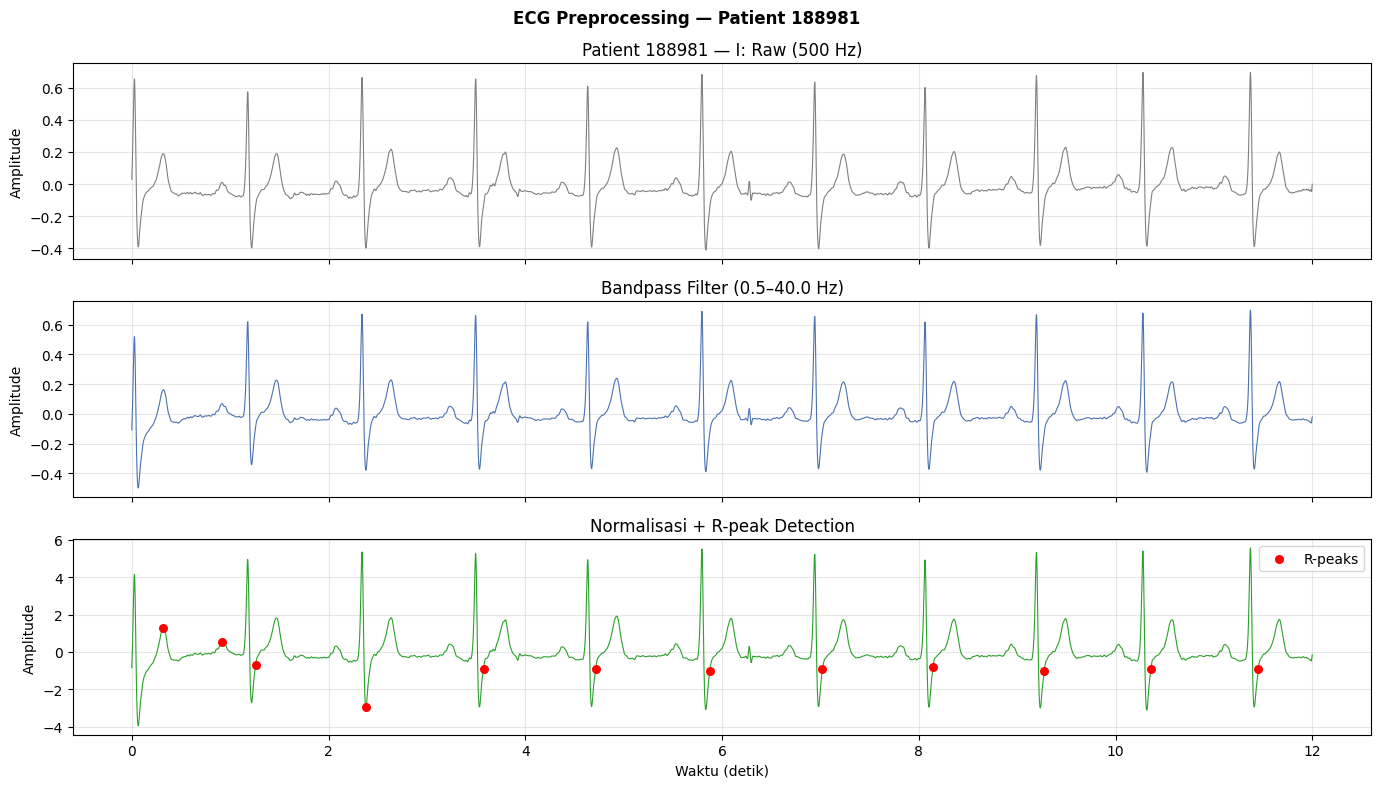

  ECG plot: outputs/ecg_example_patient188981.png

[2/7] Ekstraksi fitur semua pasien ...
  Memproses 1/356 — patient 188981
  Memproses 10/356 — patient 304141
  Memproses 20/356 — patient 395553
  Memproses 30/356 — patient 450733
  Memproses 40/356 — patient 506408
  Memproses 50/356 — patient 558967
  Memproses 60/356 — patient 622530
  Memproses 70/356 — patient 814286
  Memproses 80/356 — patient 852786
  Memproses 90/356 — patient 903442
  Memproses 100/356 — patient 939546
  Memproses 110/356 — patient 965217
  Memproses 120/356 — patient 985814
  Memproses 130/356 — patient 1036640
  Memproses 140/356 — patient 1080968
  Memproses 150/356 — patient 1093224
  Memproses 160/356 — patient 1118251
  Memproses 170/356 — patient 1142915
  Memproses 180/356 — patient 1169405
  Memproses 190/356 — patient 1191551
  Memproses 200/356 — patient 1207769
  Memproses 210/356 — patient 1235674
  Memproses 220/356 — patient 1254062
  Memproses 230/356 — patient 1277374
  Memproses 240/356 — 

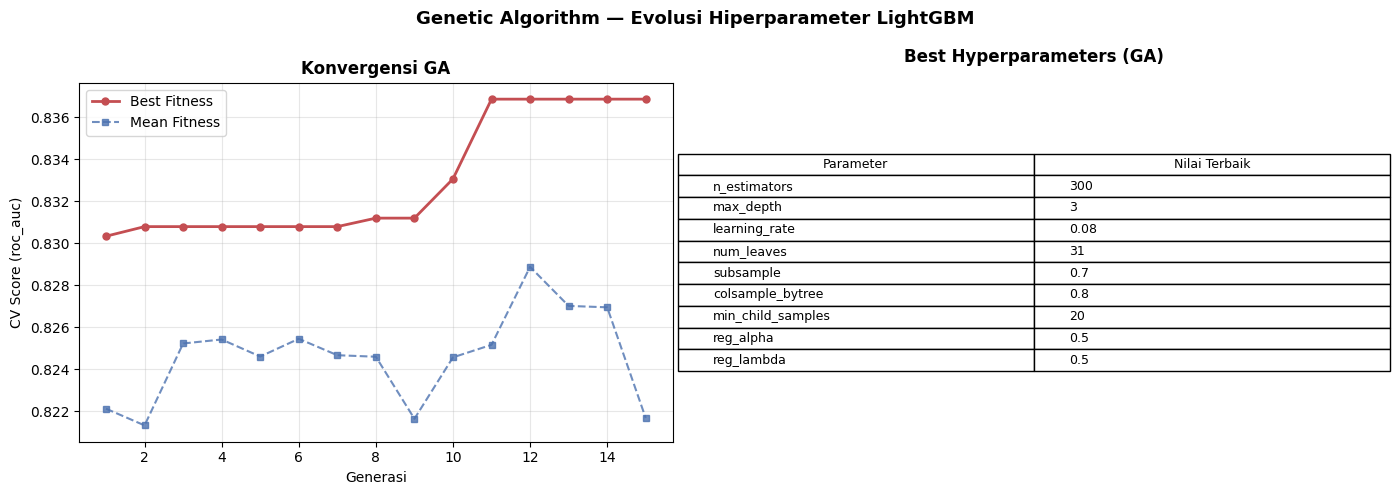

  Plot GA evolution: outputs/plot_ga_evolution.png

  Model   : outputs/brugada_lgbm_pipeline.joblib
  Top 10 Features:
               feature  importance
       V2_st_slope_max          42
   III_j_amplitude_std          36
V2_qrs_duration_ms_std          32
    V1_st_slope_median          32
    V1_t_amplitude_min          30
    V2_st_slope_median          29
      V2_st_slope_mean          27
 V2_j_amplitude_median          25
 V1_st40_amplitude_max          24
  I_t_peak_time_ms_min          22

[5/7] Evaluasi pada TEST SET (held-out) ...

  ╔══════════════════════════════════════════╗
  ║   TEST SET EVALUATION (HELD-OUT)         ║
  ╠══════════════════════════════════════════╣
  ║  ROC-AUC                 : 0.8621        ║
  ║  Avg Precision           : 0.7731        ║
  ║  MCC                     : 0.6453        ║
  ║  Balanced Acc            : 0.8227        ║
  ║  F1                      : 0.7143        ║
  ║  Accuracy                : 0.8889        ║
  ║  Sensitivity          

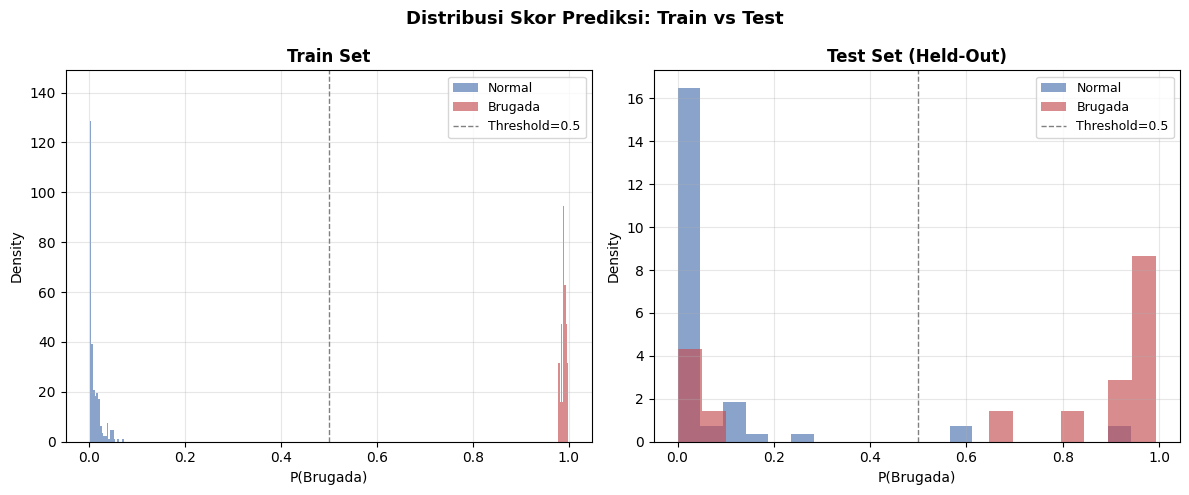

  Plot CV vs Test dist: outputs/plot_cv_vs_test_dist.png
  Default    — CV AUC: 0.8227 ± 0.0628  |  Test AUC: 0.8325
  GA-Tuned   — CV AUC: 0.8369 ± 0.0641  |  Test AUC: 0.8621


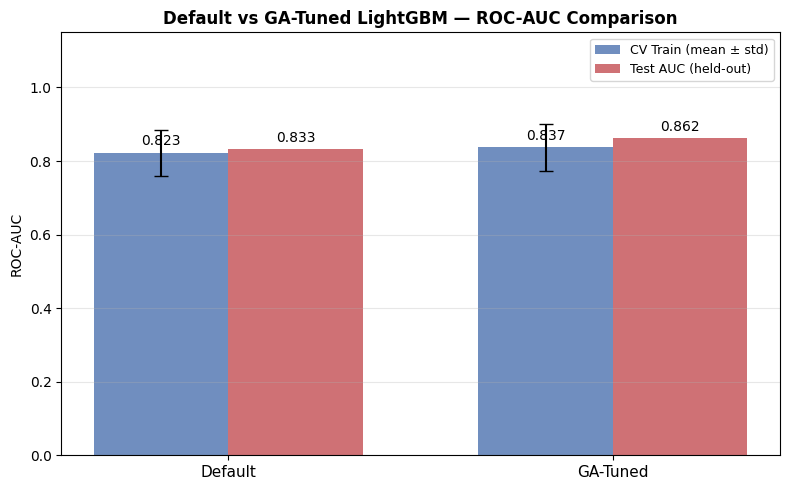

  Plot Default vs GA: outputs/plot_default_vs_ga.png

[7/7] Membuat visualisasi utama ...


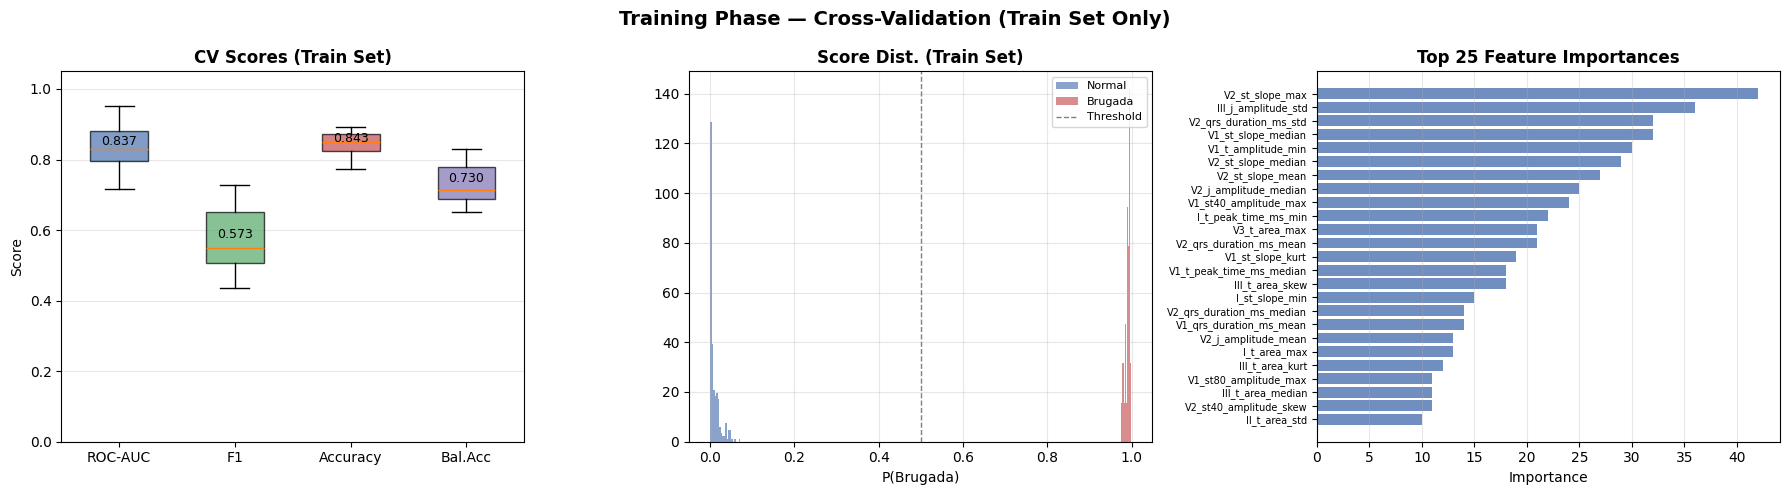

  Plot training : outputs/plot_training.png


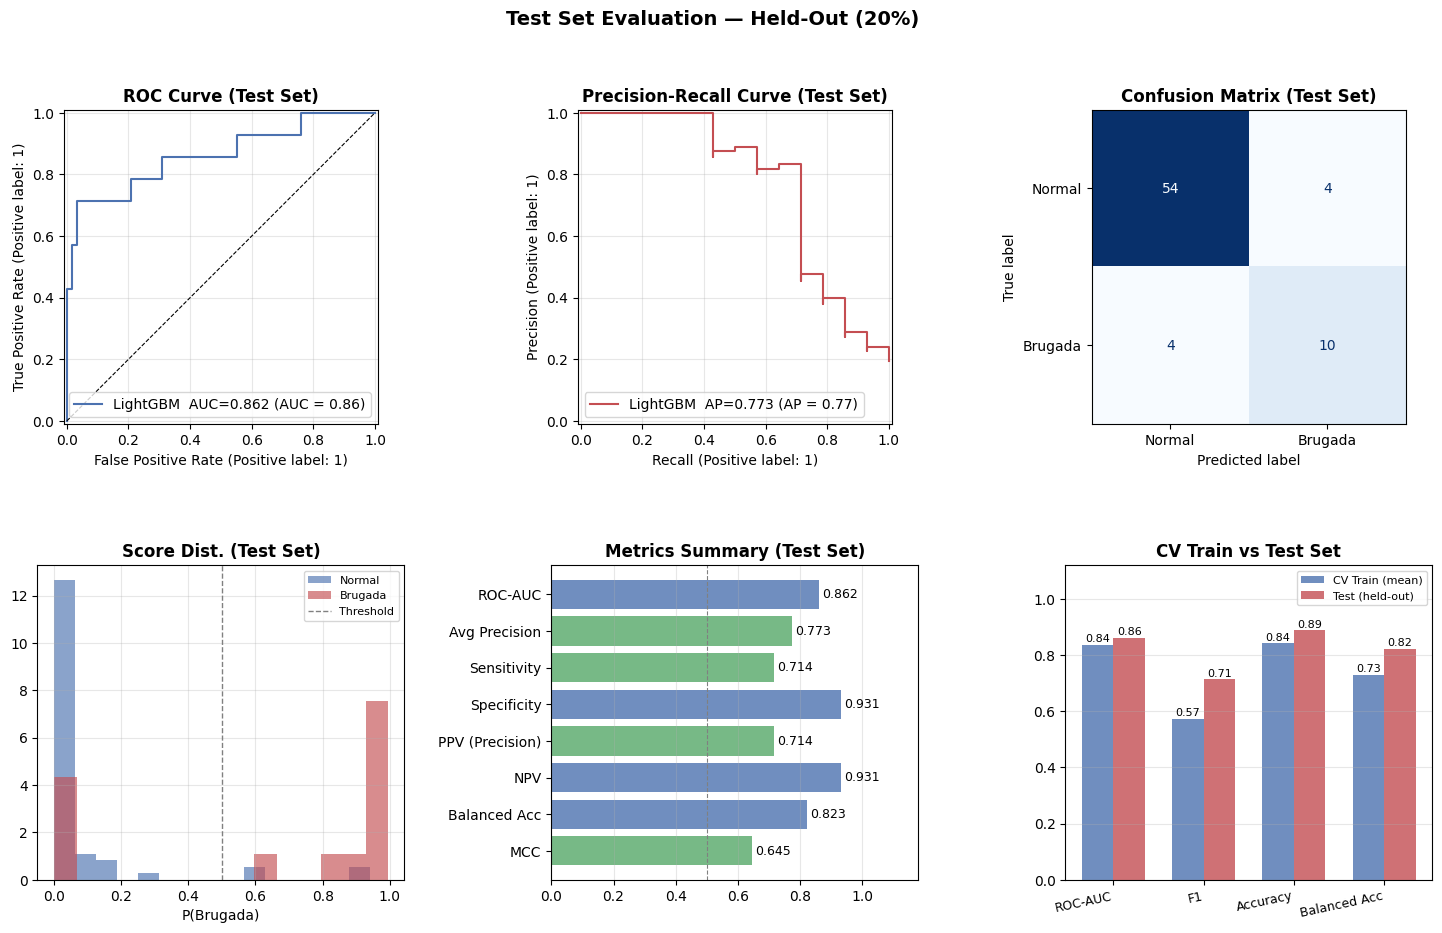

  Plot test     : outputs/plot_test_evaluation.png

  PIPELINE SELESAI
  Test ROC-AUC    : 0.8621
  Test Sensitivity: 0.7143
  Test Specificity: 0.931
  Test MCC        : 0.6453
  Output dir      : outputs


In [ ]:
"""
╔══════════════════════════════════════════════════════════════════╗
║         BRUGADA SYNDROME DETECTION PIPELINE (REVISED)           ║
║  ECG Signal Processing + LightGBM + Genetic Algorithm Tuning    ║
╚══════════════════════════════════════════════════════════════════╝

Revisi lengkap mencakup:
  - Import lengkap dan konsisten
  - Penamaan fungsi/variabel konsisten (LGBM, bukan XGBoost)
  - GA_CONFIG didefinisikan dengan benar
  - Semua fungsi yang dipanggil di main() sudah didefinisikan:
      train_lgbm_with_ga(), plot_ga_evolution(),
      cv_vs_test(), compare_default_vs_ga()
  - Variabel cfg["cv_folds"] & cfg["random_state"] dipakai
    konsisten (bukan variabel bebas)
  - RepeatedStratifiedKFold diimport dengan benar
  - Komentar / docstring dalam Bahasa Indonesia
"""

import os
import warnings
import random
import copy
import json

import numpy as np
import pandas as pd
import wfdb
import neurokit2 as nk

from scipy import signal
from scipy.stats import skew, kurtosis

from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    matthews_corrcoef,
    balanced_accuracy_score,
    f1_score,
    accuracy_score,
)
from sklearn.pipeline import Pipeline

from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")


# ══════════════════════════════════════════════════════════════════
#  KONFIGURASI UTAMA PIPELINE
# ══════════════════════════════════════════════════════════════════
CONFIG = {
    # --- Path ---
    "data_dir":       "/content/drive/MyDrive/lomba/files",
    "metadata_path":  "metadata.csv",
    "output_dir":     "outputs",

    # --- Pemrosesan sinyal ---
    "target_fs":       500,
    "bandpass_low":    0.5,
    "bandpass_high":   40.0,
    "bandpass_order":  4,

    # --- Lead ECG yang digunakan ---
    "leads_of_interest": ["I", "II", "III", "V1", "V2", "V3"],

    # --- Ekstraksi fitur ---
    "st_offset_40ms":    0.040,   # detik
    "st_offset_80ms":    0.080,   # detik
    "t_wave_window_end": 0.400,   # detik

    # --- Split ---
    "test_size":    0.20,
    "cv_folds":     5,
    "random_state": 42,

    # --- Parameter default LightGBM (digunakan di compare_default_vs_ga) ---
    "lgbm_default_params": {
        "n_estimators":    300,
        "max_depth":       4,
        "learning_rate":   0.05,
        "subsample":       0.8,
        "colsample_bytree": 0.8,
        "random_state":    42,
        "scale_pos_weight": None,   # diisi otomatis
        "verbose":         -1,
    },
}

# ══════════════════════════════════════════════════════════════════
#  KONFIGURASI GENETIC ALGORITHM
# ══════════════════════════════════════════════════════════════════
GA_CONFIG = {
    "population_size":  20,          # jumlah individu per generasi
    "n_generations":    15,          # jumlah generasi
    "crossover_rate":   0.8,         # peluang crossover
    "mutation_rate":    0.2,         # peluang mutasi per gen
    "tournament_size":  3,           # ukuran turnamen seleksi
    "elite_size":       2,           # individu terbaik yang langsung lolos
    "scoring":          "roc_auc",   # metrik optimasi

    # Ruang pencarian hiperparameter
    "param_space": {
        "n_estimators":    [100, 200, 300, 400, 500],
        "max_depth":       [3, 4, 5, 6, 7, -1],
        "learning_rate":   [0.01, 0.03, 0.05, 0.08, 0.10],
        "num_leaves":      [15, 31, 50, 63, 80, 127],
        "subsample":       [0.6, 0.7, 0.8, 0.9, 1.0],
        "colsample_bytree":[0.6, 0.7, 0.8, 0.9, 1.0],
        "min_child_samples":[10, 20, 30, 50],
        "reg_alpha":       [0.0, 0.01, 0.1, 0.5, 1.0],
        "reg_lambda":      [0.0, 0.01, 0.1, 0.5, 1.0],
    },
}


# ══════════════════════════════════════════════════════════════════
#  BAGIAN 1 — LOAD & PREPROCESSING SINYAL ECG
# ══════════════════════════════════════════════════════════════════

def load_ecg(patient_id, data_dir, leads):
    """
    Membaca file ECG format WFDB dan mengekstrak sinyal per lead.

    Returns
    -------
    lead_signals : dict  {nama_lead: np.ndarray}
    fs_orig      : int   frekuensi sampling asli
    """
    record_path = os.path.join(data_dir, str(patient_id), str(patient_id))
    record      = wfdb.rdrecord(record_path)
    fs_orig     = record.fs
    sig_names   = [s.upper() for s in record.sig_name]

    lead_signals = {}
    for lead in leads:
        if lead.upper() not in sig_names:
            raise ValueError(
                f"Lead {lead} tidak ditemukan di record {patient_id}. "
                f"Tersedia: {sig_names}"
            )
        idx = sig_names.index(lead.upper())
        lead_signals[lead] = record.p_signal[:, idx].astype(np.float64)

    return lead_signals, fs_orig


def resample_signal(sig, fs_orig, fs_target):
    """Resample sinyal ke frekuensi target jika berbeda."""
    if fs_orig == fs_target:
        return sig
    n_samples = int(len(sig) * fs_target / fs_orig)
    return signal.resample(sig, n_samples)


def bandpass_filter(sig, fs, low, high, order=4):
    """Filter Butterworth bandpass untuk membuang noise."""
    nyq  = fs / 2.0
    b, a = signal.butter(order, [low / nyq, high / nyq], btype="band")
    return signal.filtfilt(b, a, sig)


def normalize_signal(sig, method="zscore"):
    """Normalisasi sinyal dengan z-score atau min-max."""
    if method == "zscore":
        mu, sd = np.mean(sig), np.std(sig)
        return (sig - mu) / sd if sd != 0 else sig - mu
    elif method == "minmax":
        lo, hi = sig.min(), sig.max()
        return (sig - lo) / (hi - lo) if hi != lo else np.zeros_like(sig)
    raise ValueError(f"Metode normalisasi tidak dikenal: {method}")


# ══════════════════════════════════════════════════════════════════
#  BAGIAN 2 — DETEKSI R-PEAK & EKSTRAKSI FITUR BEAT
# ══════════════════════════════════════════════════════════════════

def detect_r_peaks(sig, fs):
    """
    Mendeteksi puncak R menggunakan algoritma Pan-Tompkins (via NeuroKit2).

    Returns
    -------
    np.ndarray  indeks sampel R-peak yang valid (> 0)
    """
    _, info = nk.ecg_peaks(sig, sampling_rate=int(fs), method="pantompkins1985")
    peaks   = info["ECG_R_Peaks"]
    return peaks[peaks > 0]


def find_j_point(beat, r_idx, fs):
    """
    Mencari J-point (titik akhir QRS) dengan pendekatan gradien minimum.
    J-point adalah penanda kunci pola Brugada pada ST-elevation.
    """
    start = r_idx + int(0.06 * fs)
    end   = min(r_idx + int(0.12 * fs), len(beat) - 1)
    if start >= end:
        return start
    return start + int(np.argmin(np.abs(np.diff(beat[start:end]))))


def extract_beat_features(beat, r_idx, fs, cfg):
    """
    Mengekstrak fitur klinis dari satu beat ECG.

    Fitur yang diekstrak
    --------------------
    qrs_duration_ms : durasi kompleks QRS (ms)
    j_amplitude     : amplitudo di J-point
    st40_amplitude  : amplitudo ST di 40 ms setelah J-point
    st80_amplitude  : amplitudo ST di 80 ms setelah J-point
    st_slope        : kemiringan segmen ST (ciri utama Brugada)
    t_amplitude     : amplitudo puncak gelombang T
    t_area          : area gelombang T
    t_peak_time_ms  : waktu puncak gelombang T (ms)
    """
    n = len(beat)

    # — QRS duration —
    q_idx  = max(0, r_idx - int(0.06 * fs))
    s_end  = min(n, r_idx + int(0.08 * fs))
    s_seg  = beat[r_idx:s_end]
    s_idx  = r_idx + int(np.argmin(s_seg)) if len(s_seg) > 0 else r_idx
    qrs_duration_ms = (s_idx - q_idx) / fs * 1000

    # — J-point —
    j_idx       = find_j_point(beat, r_idx, fs)
    j_amplitude = beat[j_idx] if j_idx < n else np.nan

    # — ST 40 ms & ST 80 ms —
    st40_idx = j_idx + int(cfg["st_offset_40ms"] * fs)
    st80_idx = j_idx + int(cfg["st_offset_80ms"] * fs)
    st40_amp = beat[st40_idx] if st40_idx < n else np.nan
    st80_amp = beat[st80_idx] if st80_idx < n else np.nan

    dt       = cfg["st_offset_80ms"] - cfg["st_offset_40ms"]
    st_slope = (
        (st80_amp - st40_amp) / dt
        if not (np.isnan(st40_amp) or np.isnan(st80_amp)) and dt > 0
        else np.nan
    )

    # — T-wave —
    t_start = j_idx + int(0.05 * fs)
    t_end   = min(r_idx + int(cfg["t_wave_window_end"] * fs), n)
    if t_start < t_end:
        t_seg          = beat[t_start:t_end]
        t_amplitude    = float(np.max(np.abs(t_seg)))
        t_area         = float(np.trapz(t_seg)) / fs
        t_peak_time_ms = int(np.argmax(np.abs(t_seg))) / fs * 1000
    else:
        t_amplitude = t_area = t_peak_time_ms = np.nan

    return {
        "qrs_duration_ms": qrs_duration_ms,
        "j_amplitude":     j_amplitude,
        "st40_amplitude":  st40_amp,
        "st80_amplitude":  st80_amp,
        "st_slope":        st_slope,
        "t_amplitude":     t_amplitude,
        "t_area":          t_area,
        "t_peak_time_ms":  t_peak_time_ms,
    }


def extract_features_for_lead(sig, fs, cfg):
    """
    Ekstraksi fitur untuk semua beat dalam satu lead.

    Returns
    -------
    pd.DataFrame  setiap baris adalah satu beat
    """
    r_peaks     = detect_r_peaks(sig, fs)
    pre, post   = int(0.200 * fs), int(0.600 * fs)
    rows        = []
    for rp in r_peaks:
        if rp - pre < 0 or rp + post > len(sig):
            continue
        rows.append(
            extract_beat_features(sig[rp - pre: rp + post], pre, fs, cfg)
        )
    return pd.DataFrame(rows)


# ══════════════════════════════════════════════════════════════════
#  BAGIAN 3 — AGREGASI FITUR PER PASIEN
# ══════════════════════════════════════════════════════════════════

_AGG_FNS   = [
    "mean", "std", "median", "min", "max",
    lambda x: skew(x.dropna()),
    lambda x: kurtosis(x.dropna()),
]
_AGG_NAMES = ["mean", "std", "median", "min", "max", "skew", "kurt"]


def aggregate_patient_features(lead_dfs):
    """
    Merangkum fitur beat-level menjadi satu vektor fitur per pasien
    menggunakan statistik deskriptif (mean, std, median, min, max, skew, kurt).
    """
    all_feats = {}
    for lead, df in lead_dfs.items():
        if df.empty:
            continue
        for col in df.columns:
            for fn, name in zip(_AGG_FNS, _AGG_NAMES):
                key             = f"{lead}_{col}_{name}"
                all_feats[key]  = df[col].agg(fn)
    return pd.Series(all_feats)


def process_patient(patient_id, cfg):
    """
    Memproses satu pasien: load → resample → filter → normalisasi
    → ekstraksi fitur → agregasi.

    Returns
    -------
    pd.Series atau None jika terjadi error
    """
    try:
        lead_signals, fs_orig = load_ecg(
            patient_id, cfg["data_dir"], cfg["leads_of_interest"]
        )
        lead_features = {}
        for lead, raw in lead_signals.items():
            sig = resample_signal(raw, fs_orig, cfg["target_fs"])
            fs  = cfg["target_fs"]
            sig = bandpass_filter(
                sig, fs,
                cfg["bandpass_low"], cfg["bandpass_high"],
                cfg["bandpass_order"]
            )
            sig = normalize_signal(sig, method="zscore")
            lead_features[lead] = extract_features_for_lead(sig, fs, cfg)

        feats               = aggregate_patient_features(lead_features)
        feats["patient_id"] = patient_id
        return feats

    except Exception as e:
        print(f"  [SKIP] patient {patient_id}: {e}")
        return None


def build_feature_matrix(metadata, cfg):
    """
    Membangun matriks fitur untuk seluruh pasien dan
    menggabungkannya dengan label dari metadata.
    """
    os.makedirs(cfg["output_dir"], exist_ok=True)
    records = []
    n       = len(metadata)

    for i, row in metadata.iterrows():
        pid = int(row["patient_id"])
        if (i + 1) % 10 == 0 or i == 0:
            print(f"  Memproses {i+1}/{n} — patient {pid}")
        feats = process_patient(pid, cfg)
        if feats is not None:
            records.append(feats)

    df = pd.DataFrame(records)
    df = df.merge(
        metadata[["patient_id", "brugada", "basal_pattern", "sudden_death"]],
        on="patient_id", how="left"
    )
    return df


# ══════════════════════════════════════════════════════════════════
#  BAGIAN 4 — SPLIT DATA
# ══════════════════════════════════════════════════════════════════

def split_data(feature_df, cfg):
    """
    Stratified train/test split 80/20.
    Test set dikunci dan tidak dilihat sampai evaluasi akhir.
    """
    label_col = "brugada"
    drop_cols  = ["patient_id", "brugada", "basal_pattern", "sudden_death"]
    feat_cols  = [c for c in feature_df.columns if c not in drop_cols]

    X   = feature_df[feat_cols].fillna(feature_df[feat_cols].median())
    y   = feature_df[label_col]
    ids = feature_df["patient_id"]

    X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
        X, y, ids,
        test_size   = cfg["test_size"],
        stratify    = y,
        random_state= cfg["random_state"],
    )

    print(f"\n  ┌─ Data Split ({'='*30})")
    print(f"  │  Train : {len(X_train):>4} pasien "
          f"— Normal:{(y_train==0).sum():>3}, Brugada:{(y_train==1).sum():>3}")
    print(f"  │  Test  : {len(X_test):>4} pasien "
          f"— Normal:{(y_test==0).sum():>3}, Brugada:{(y_test==1).sum():>3}")
    print(f"  └─ Test set dikunci — tidak dilihat sampai evaluasi akhir")

    return X_train, X_test, y_train, y_test, feat_cols, ids_train, ids_test


# ══════════════════════════════════════════════════════════════════
#  BAGIAN 5 — GENETIC ALGORITHM UNTUK TUNING HIPERPARAMETER LGBM
# ══════════════════════════════════════════════════════════════════

def _random_individual(param_space):
    """Membuat individu acak dari ruang pencarian hiperparameter."""
    return {k: random.choice(v) for k, v in param_space.items()}


def _evaluate_individual(params, X_train, y_train, scale_pos_weight,
                          cfg, ga_cfg):
    """
    Evaluasi satu individu (satu set hiperparameter) menggunakan
    RepeatedStratifiedKFold CV pada train set.
    """
    full_params = {
        **params,
        "scale_pos_weight": scale_pos_weight,
        "random_state":     cfg["random_state"],
        "verbose":          -1,
    }
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lgbm",   LGBMClassifier(**full_params)),
    ])
    cv = RepeatedStratifiedKFold(
        n_splits  = cfg["cv_folds"],
        n_repeats = 2,
        random_state = cfg["random_state"],
    )
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv      = cv,
        scoring = ga_cfg["scoring"],
        n_jobs  = -1,
    )
    return float(scores.mean())


def _tournament_selection(population, fitnesses, tournament_size):
    """Seleksi turnamen: ambil individu terbaik dari subset acak."""
    indices  = random.sample(range(len(population)), tournament_size)
    best_idx = max(indices, key=lambda i: fitnesses[i])
    return copy.deepcopy(population[best_idx])


def _crossover(parent1, parent2, crossover_rate, param_space):
    """
    Crossover uniform: setiap gen dipilih secara acak dari salah satu parent.
    """
    if random.random() > crossover_rate:
        return copy.deepcopy(parent1), copy.deepcopy(parent2)

    child1, child2 = {}, {}
    for key in param_space:
        if random.random() < 0.5:
            child1[key], child2[key] = parent1[key], parent2[key]
        else:
            child1[key], child2[key] = parent2[key], parent1[key]
    return child1, child2


def _mutate(individual, mutation_rate, param_space):
    """Mutasi: setiap gen direset secara acak dengan probabilitas mutation_rate."""
    mutant = copy.deepcopy(individual)
    for key in param_space:
        if random.random() < mutation_rate:
            mutant[key] = random.choice(param_space[key])
    return mutant


def train_lgbm_with_ga(X_train, y_train, cfg, ga_cfg):
    """
    Melatih LightGBM dengan optimasi hiperparameter menggunakan
    Genetic Algorithm (GA).

    Alur GA
    -------
    1. Inisialisasi populasi acak
    2. Evaluasi fitness (CV ROC-AUC) setiap individu
    3. Seleksi elitism + tournament
    4. Crossover & mutasi → generasi berikutnya
    5. Ulangi selama n_generations

    Returns
    -------
    pipe          : Pipeline sklearn (scaler + lgbm) yang sudah di-fit
    cv_results    : dict berisi skor CV (auc, f1, acc, bac)
    importance_df : DataFrame feature importance
    ga_history    : list riwayat fitness per generasi
    best_params   : dict hiperparameter terbaik hasil GA
    """
    neg, pos        = (y_train == 0).sum(), (y_train == 1).sum()
    scale_pos_weight= neg / pos if pos > 0 else 1.0
    param_space     = ga_cfg["param_space"]
    pop_size        = ga_cfg["population_size"]
    n_gen           = ga_cfg["n_generations"]
    elite_size      = ga_cfg["elite_size"]

    print(f"\n  ── Genetic Algorithm Hyperparameter Tuning ──")
    print(f"  Populasi: {pop_size}  |  Generasi: {n_gen}  "
          f"|  Scoring: {ga_cfg['scoring']}")

    # Inisialisasi populasi
    random.seed(cfg["random_state"])
    population = [_random_individual(param_space) for _ in range(pop_size)]

    ga_history = []   # [(gen, best_fit, mean_fit)]
    best_individual  = None
    best_fitness_all = -np.inf

    for gen in range(n_gen):
        # Evaluasi fitness
        fitnesses = [
            _evaluate_individual(
                ind, X_train, y_train, scale_pos_weight, cfg, ga_cfg
            )
            for ind in population
        ]

        gen_best  = max(fitnesses)
        gen_mean  = float(np.mean(fitnesses))
        ga_history.append((gen + 1, gen_best, gen_mean))

        # Simpan individu terbaik sepanjang waktu
        best_idx = int(np.argmax(fitnesses))
        if fitnesses[best_idx] > best_fitness_all:
            best_fitness_all = fitnesses[best_idx]
            best_individual  = copy.deepcopy(population[best_idx])

        print(f"  Gen {gen+1:>3}/{n_gen} — "
              f"best: {gen_best:.4f}  mean: {gen_mean:.4f}  "
              f"(all-time best: {best_fitness_all:.4f})")

        # Elitism
        sorted_idx = np.argsort(fitnesses)[::-1]
        elites     = [copy.deepcopy(population[i]) for i in sorted_idx[:elite_size]]

        # Buat generasi baru
        new_population = elites[:]
        while len(new_population) < pop_size:
            p1 = _tournament_selection(
                population, fitnesses, ga_cfg["tournament_size"]
            )
            p2 = _tournament_selection(
                population, fitnesses, ga_cfg["tournament_size"]
            )
            c1, c2 = _crossover(
                p1, p2, ga_cfg["crossover_rate"], param_space
            )
            c1 = _mutate(c1, ga_cfg["mutation_rate"], param_space)
            c2 = _mutate(c2, ga_cfg["mutation_rate"], param_space)
            new_population.append(c1)
            if len(new_population) < pop_size:
                new_population.append(c2)

        population = new_population

    best_params = best_individual
    print(f"\n  ── Best Params (GA) ──")
    for k, v in best_params.items():
        print(f"  {k:<22}: {v}")
    print(f"  Best CV {ga_cfg['scoring']}: {best_fitness_all:.4f}")

    # ── Fit model final dengan best_params pada seluruh train set ──
    final_params = {
        **best_params,
        "scale_pos_weight": scale_pos_weight,
        "random_state":     cfg["random_state"],
        "verbose":          -1,
    }
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lgbm",   LGBMClassifier(**final_params)),
    ])

    # CV final untuk pelaporan
    cv = RepeatedStratifiedKFold(
        n_splits     = cfg["cv_folds"],
        n_repeats    = 2,
        random_state = cfg["random_state"],
    )
    cv_auc = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="roc_auc",           n_jobs=-1)
    cv_f1  = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="f1",                n_jobs=-1)
    cv_acc = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="accuracy",          n_jobs=-1)
    cv_bac = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring="balanced_accuracy", n_jobs=-1)

    print(f"\n  ── CV Results Final (best params, {cfg['cv_folds']} folds × 2 repeats) ──")
    for metric_name, scores in [
        ("ROC-AUC",  cv_auc),
        ("F1",       cv_f1),
        ("Accuracy", cv_acc),
        ("Bal. Acc", cv_bac),
    ]:
        print(f"  {metric_name:<14}: {scores.mean():.4f} ± {scores.std():.4f}")

    # Fit final pada seluruh train set
    pipe.fit(X_train, y_train)

    importance_df = pd.DataFrame({
        "feature":    X_train.columns.tolist(),
        "importance": pipe.named_steps["lgbm"].feature_importances_,
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    cv_results = {
        "auc": cv_auc,
        "f1":  cv_f1,
        "acc": cv_acc,
        "bac": cv_bac,
    }

    return pipe, cv_results, importance_df, ga_history, best_params


# ══════════════════════════════════════════════════════════════════
#  BAGIAN 6 — EVALUASI TEST SET
# ══════════════════════════════════════════════════════════════════

def evaluate_on_test(pipe, X_test, y_test):
    """
    Evaluasi komprehensif model pada held-out test set.

    Returns
    -------
    metrics    : dict semua metrik evaluasi
    y_pred     : np.ndarray prediksi kelas
    y_prob     : np.ndarray probabilitas kelas positif (Brugada)
    cm         : confusion matrix (np.ndarray 2×2)
    """
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    cm              = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp  = cm.ravel()

    metrics = {
        "ROC-AUC":         round(roc_auc_score(y_test, y_prob), 4),
        "Avg Precision":   round(average_precision_score(y_test, y_prob), 4),
        "MCC":             round(matthews_corrcoef(y_test, y_pred), 4),
        "Balanced Acc":    round(balanced_accuracy_score(y_test, y_pred), 4),
        "F1":              round(f1_score(y_test, y_pred), 4),
        "Accuracy":        round(accuracy_score(y_test, y_pred), 4),
        "Sensitivity":     round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0.0,
        "Specificity":     round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0.0,
        "PPV (Precision)": round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0.0,
        "NPV":             round(tn / (tn + fn), 4) if (tn + fn) > 0 else 0.0,
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
    }

    print(f"\n  ╔{'═'*42}╗")
    print(f"  ║   TEST SET EVALUATION (HELD-OUT)         ║")
    print(f"  ╠{'═'*42}╣")
    for k, v in metrics.items():
        if k not in ("TP", "TN", "FP", "FN"):
            print(f"  ║  {k:<24}: {str(v):<14}║")
    print(f"  ║  TP:{tp}  TN:{tn}  FP:{fp}  FN:{fn}{'':>20}║")
    print(f"  ╚{'═'*42}╝")

    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=["Normal", "Brugada"]))

    return metrics, y_pred, y_prob, cm


# ══════════════════════════════════════════════════════════════════
#  BAGIAN 7 — VISUALISASI
# ══════════════════════════════════════════════════════════════════

def plot_ga_evolution(ga_history, best_params, output_dir):
    """
    Memplot riwayat evolusi Genetic Algorithm:
    kurva best fitness dan mean fitness per generasi.
    """
    os.makedirs(output_dir, exist_ok=True)

    gens       = [row[0] for row in ga_history]
    best_fits  = [row[1] for row in ga_history]
    mean_fits  = [row[2] for row in ga_history]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Genetic Algorithm — Evolusi Hiperparameter LightGBM",
                 fontsize=13, fontweight="bold")

    # Kurva konvergensi
    ax = axes[0]
    ax.plot(gens, best_fits, "o-", color="#C44E52", lw=2,
            label="Best Fitness", markersize=5)
    ax.plot(gens, mean_fits, "s--", color="#4C72B0", lw=1.5,
            label="Mean Fitness", markersize=4, alpha=0.8)
    ax.set_xlabel("Generasi"); ax.set_ylabel(f"CV Score ({GA_CONFIG['scoring']})")
    ax.set_title("Konvergensi GA", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)

    # Best params (tabel)
    ax = axes[1]
    ax.axis("off")
    rows = [[k, str(v)] for k, v in best_params.items()]
    tbl  = ax.table(
        cellText   = rows,
        colLabels  = ["Parameter", "Nilai Terbaik"],
        loc        = "center",
        cellLoc    = "left",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.2, 1.4)
    ax.set_title("Best Hyperparameters (GA)", fontweight="bold", pad=15)

    fig.tight_layout()
    path = os.path.join(output_dir, "plot_ga_evolution.png")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot GA evolution: {path}")


def cv_vs_test(pipe, X_train, y_train, X_test, y_test, cfg, output_dir):
    """
    Membandingkan distribusi probabilitas prediksi pada
    train set (CV) vs test set (held-out) untuk mendeteksi overfitting.
    """
    os.makedirs(output_dir, exist_ok=True)

    y_prob_train = pipe.predict_proba(X_train)[:, 1]
    y_prob_test  = pipe.predict_proba(X_test)[:, 1]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Distribusi Skor Prediksi: Train vs Test",
                 fontsize=13, fontweight="bold")

    for ax, y_prob, y_true, title in [
        (axes[0], y_prob_train, y_train, "Train Set"),
        (axes[1], y_prob_test,  y_test,  "Test Set (Held-Out)"),
    ]:
        for lbl, name, color in [(0, "Normal", "#4C72B0"),
                                  (1, "Brugada", "#C44E52")]:
            ax.hist(y_prob[y_true == lbl], bins=20, alpha=0.65,
                    label=name, color=color, density=True)
        ax.axvline(0.5, ls="--", color="gray", lw=1, label="Threshold=0.5")
        ax.set_xlabel("P(Brugada)")
        ax.set_ylabel("Density")
        ax.set_title(title, fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    fig.tight_layout()
    path = os.path.join(output_dir, "plot_cv_vs_test_dist.png")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot CV vs Test dist: {path}")


def compare_default_vs_ga(X_train, y_train, X_test, y_test,
                           best_params, scale_pos_weight,
                           cfg, output_dir):
    """
    Membandingkan performa model dengan parameter default
    versus parameter hasil GA pada train (CV) dan test set.
    """
    os.makedirs(output_dir, exist_ok=True)

    cv = RepeatedStratifiedKFold(
        n_splits     = cfg["cv_folds"],
        n_repeats    = 2,
        random_state = cfg["random_state"],
    )

    results = {}
    configs = {
        "Default": {
            **cfg["lgbm_default_params"],
            "scale_pos_weight": scale_pos_weight,
            "verbose": -1,
        },
        "GA-Tuned": {
            **best_params,
            "scale_pos_weight": scale_pos_weight,
            "random_state":     cfg["random_state"],
            "verbose":          -1,
        },
    }

    for label, params in configs.items():
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("lgbm",   LGBMClassifier(**params)),
        ])
        cv_auc = cross_val_score(
            pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1
        )
        pipe.fit(X_train, y_train)
        y_prob_test = pipe.predict_proba(X_test)[:, 1]
        test_auc    = roc_auc_score(y_test, y_prob_test)

        results[label] = {
            "cv_auc_mean": cv_auc.mean(),
            "cv_auc_std":  cv_auc.std(),
            "test_auc":    test_auc,
        }
        print(f"  {label:<10} — CV AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}"
              f"  |  Test AUC: {test_auc:.4f}")

    # Plot perbandingan
    labels     = list(results.keys())
    cv_means   = [results[l]["cv_auc_mean"] for l in labels]
    cv_stds    = [results[l]["cv_auc_std"]  for l in labels]
    test_aucs  = [results[l]["test_auc"]    for l in labels]

    x  = np.arange(len(labels))
    w  = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - w/2, cv_means, w, yerr=cv_stds, capsize=5,
           label="CV Train (mean ± std)", color="#4C72B0", alpha=0.8)
    ax.bar(x + w/2, test_aucs, w,
           label="Test AUC (held-out)", color="#C44E52", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("ROC-AUC")
    ax.set_title("Default vs GA-Tuned LightGBM — ROC-AUC Comparison",
                 fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    for xi, (cv_v, te_v) in enumerate(zip(cv_means, test_aucs)):
        ax.text(xi - w/2, cv_v + 0.02, f"{cv_v:.3f}", ha="center", fontsize=10)
        ax.text(xi + w/2, te_v + 0.02, f"{te_v:.3f}", ha="center", fontsize=10)

    fig.tight_layout()
    path = os.path.join(output_dir, "plot_default_vs_ga.png")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot Default vs GA: {path}")


def plot_all(cv_results, test_metrics, importance_df,
             X_train, y_train, X_test, y_test,
             pipe, cm, y_prob_test, output_dir):
    """
    Menghasilkan dua figure ringkasan:
      1. Training phase (CV, distribusi skor train, feature importance)
      2. Test set evaluation (ROC, PR, CM, distribusi skor, metrik, CV vs Test)
    """
    os.makedirs(output_dir, exist_ok=True)

    # ── Figure 1: Training Phase ──────────────────────────────────
    fig1, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig1.suptitle("Training Phase — Cross-Validation (Train Set Only)",
                  fontsize=14, fontweight="bold")

    # CV boxplot
    ax    = axes[0]
    cv_df = pd.DataFrame({
        "ROC-AUC":  cv_results["auc"],
        "F1":       cv_results["f1"],
        "Accuracy": cv_results["acc"],
        "Bal.Acc":  cv_results["bac"],
    })
    bp = ax.boxplot(cv_df.values, labels=cv_df.columns,
                    patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"],
                             ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for i, col in enumerate(cv_df.columns, 1):
        ax.text(i, cv_df[col].mean() + 0.005,
                f"{cv_df[col].mean():.3f}", ha="center", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title("CV Scores (Train Set)", fontweight="bold")
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.3)

    # Distribusi skor train
    ax          = axes[1]
    y_prob_train= pipe.predict_proba(X_train)[:, 1]
    for lbl, name, color in [(0, "Normal", "#4C72B0"),
                              (1, "Brugada", "#C44E52")]:
        ax.hist(y_prob_train[y_train == lbl], bins=20, alpha=0.65,
                label=name, color=color, density=True)
    ax.axvline(0.5, ls="--", color="gray", lw=1, label="Threshold")
    ax.set_xlabel("P(Brugada)")
    ax.set_title("Score Dist. (Train Set)", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Top 25 feature importance
    ax  = axes[2]
    top = importance_df.head(25)
    ax.barh(top["feature"][::-1], top["importance"][::-1],
            color="#4C72B0", alpha=0.8)
    ax.set_title("Top 25 Feature Importances", fontweight="bold")
    ax.set_xlabel("Importance")
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="x", alpha=0.3)

    fig1.tight_layout()
    p1 = os.path.join(output_dir, "plot_training.png")
    fig1.savefig(p1, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot training : {p1}")

    # ── Figure 2: Test Set Evaluation ────────────────────────────
    fig2 = plt.figure(figsize=(18, 10))
    fig2.suptitle("Test Set Evaluation — Held-Out (20%)",
                  fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.4)

    y_pred_test = pipe.predict(X_test)

    # ROC Curve
    ax = fig2.add_subplot(gs[0, 0])
    RocCurveDisplay.from_predictions(
        y_test, y_prob_test, ax=ax,
        name=f"LightGBM  AUC={test_metrics['ROC-AUC']:.3f}",
        color="#4C72B0",
    )
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title("ROC Curve (Test Set)", fontweight="bold")
    ax.grid(alpha=0.3)

    # PR Curve
    ax = fig2.add_subplot(gs[0, 1])
    PrecisionRecallDisplay.from_predictions(
        y_test, y_prob_test, ax=ax,
        name=f"LightGBM  AP={test_metrics['Avg Precision']:.3f}",
        color="#C44E52",
    )
    ax.set_title("Precision-Recall Curve (Test Set)", fontweight="bold")
    ax.grid(alpha=0.3)

    # Confusion Matrix
    ax = fig2.add_subplot(gs[0, 2])
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Brugada"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title("Confusion Matrix (Test Set)", fontweight="bold")

    # Distribusi skor test
    ax = fig2.add_subplot(gs[1, 0])
    for lbl, name, color in [(0, "Normal", "#4C72B0"),
                              (1, "Brugada", "#C44E52")]:
        ax.hist(y_prob_test[y_test == lbl], bins=15, alpha=0.65,
                label=name, color=color, density=True)
    ax.axvline(0.5, ls="--", color="gray", lw=1, label="Threshold")
    ax.set_xlabel("P(Brugada)")
    ax.set_title("Score Dist. (Test Set)", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Metrics bar chart
    ax          = fig2.add_subplot(gs[1, 1])
    metric_keys = ["ROC-AUC", "Avg Precision", "Sensitivity",
                   "Specificity", "PPV (Precision)", "NPV",
                   "Balanced Acc", "MCC"]
    metric_vals = [test_metrics[k] for k in metric_keys]
    bar_colors  = [
        "#4C72B0" if v >= 0.8 else "#C44E52" if v < 0.6 else "#55A868"
        for v in metric_vals
    ]
    bars = ax.barh(metric_keys[::-1], metric_vals[::-1],
                   color=bar_colors[::-1], alpha=0.8)
    for bar, val in zip(bars, metric_vals[::-1]):
        ax.text(bar.get_width() + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.set_xlim(0, 1.18)
    ax.set_title("Metrics Summary (Test Set)", fontweight="bold")
    ax.axvline(0.5, ls="--", color="gray", lw=0.8)
    ax.grid(axis="x", alpha=0.3)

    # CV vs Test comparison bar
    ax           = fig2.add_subplot(gs[1, 2])
    compare_keys = ["ROC-AUC", "F1", "Accuracy", "Balanced Acc"]
    cv_means     = [cv_results["auc"].mean(), cv_results["f1"].mean(),
                    cv_results["acc"].mean(), cv_results["bac"].mean()]
    test_vals    = [test_metrics["ROC-AUC"], test_metrics["F1"],
                    test_metrics["Accuracy"], test_metrics["Balanced Acc"]]
    x = np.arange(len(compare_keys))
    w = 0.35
    ax.bar(x - w/2, cv_means, w,
           label="CV Train (mean)", color="#4C72B0", alpha=0.8)
    ax.bar(x + w/2, test_vals, w,
           label="Test (held-out)", color="#C44E52", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(compare_keys, rotation=12, ha="right", fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.set_title("CV Train vs Test Set", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    for xi, (cv_v, te_v) in enumerate(zip(cv_means, test_vals)):
        ax.text(xi - w/2, cv_v + 0.01, f"{cv_v:.2f}", ha="center", fontsize=8)
        ax.text(xi + w/2, te_v + 0.01, f"{te_v:.2f}", ha="center", fontsize=8)

    fig2.tight_layout()
    p2 = os.path.join(output_dir, "plot_test_evaluation.png")
    fig2.savefig(p2, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot test     : {p2}")


def plot_example_ecg(patient_id, cfg):
    """
    Memplot contoh sinyal ECG satu pasien:
    raw → setelah bandpass filter → setelah normalisasi + R-peaks.
    """
    try:
        lead_signals, fs_orig = load_ecg(
            patient_id, cfg["data_dir"], cfg["leads_of_interest"]
        )
        lead    = cfg["leads_of_interest"][0]
        raw     = lead_signals[lead]
        sig_rs  = resample_signal(raw, fs_orig, cfg["target_fs"])
        fs      = cfg["target_fs"]
        sig_bp  = bandpass_filter(
            sig_rs, fs, cfg["bandpass_low"],
            cfg["bandpass_high"], cfg["bandpass_order"]
        )
        sig_nm  = normalize_signal(sig_bp, method="zscore")
        r_peaks = detect_r_peaks(sig_nm, fs)
        time    = np.arange(len(sig_nm)) / fs

        fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
        axes[0].plot(time, sig_rs, lw=0.8, color="gray")
        axes[0].set_title(
            f"Patient {patient_id} — {lead}: Raw ({fs} Hz)"
        )
        axes[1].plot(time, sig_bp, lw=0.8, color="#4C72B0")
        axes[1].set_title(
            f"Bandpass Filter ({cfg['bandpass_low']}–{cfg['bandpass_high']} Hz)"
        )
        axes[2].plot(time, sig_nm, lw=0.8, color="#2ca02c")
        axes[2].scatter(r_peaks / fs, sig_nm[r_peaks],
                        color="red", s=30, zorder=5, label="R-peaks")
        axes[2].set_title("Normalisasi + R-peak Detection")
        axes[2].legend()
        axes[2].set_xlabel("Waktu (detik)")
        for ax in axes:
            ax.set_ylabel("Amplitude")
            ax.grid(True, alpha=0.3)

        plt.suptitle(f"ECG Preprocessing — Patient {patient_id}",
                     fontweight="bold")
        plt.tight_layout()
        out = os.path.join(
            cfg["output_dir"], f"ecg_example_patient{patient_id}.png"
        )
        plt.savefig(out, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"  ECG plot: {out}")

    except Exception as e:
        print(f"  [SKIP] ECG plot patient {patient_id}: {e}")


# ══════════════════════════════════════════════════════════════════
#  MAIN PIPELINE
# ══════════════════════════════════════════════════════════════════

def main():
    print("=" * 66)
    print("  BRUGADA SYNDROME DETECTION PIPELINE — LightGBM + GA Tuning")
    print("=" * 66)

    # ── [1/7] Load metadata ──────────────────────────────────────
    print(f"\n[1/7] Loading metadata ...")
    metadata = pd.read_csv(CONFIG["metadata_path"])
    metadata = metadata[metadata["brugada"].isin([0, 1])].reset_index(drop=True)
    print(f"  Total   : {len(metadata)} pasien")
    print(f"  Brugada : {metadata['brugada'].sum()}")
    print(f"  Normal  : {(metadata['brugada'] == 0).sum()}")

    # Contoh plot ECG pasien pertama
    plot_example_ecg(int(metadata["patient_id"].iloc[0]), CONFIG)

    # ── [2/7] Ekstraksi fitur ────────────────────────────────────
    print(f"\n[2/7] Ekstraksi fitur semua pasien ...")
    feature_df = build_feature_matrix(metadata, CONFIG)
    feat_path  = os.path.join(CONFIG["output_dir"], "features_all.csv")
    feature_df.to_csv(feat_path, index=False)
    print(f"  Feature matrix: {feature_df.shape} → {feat_path}")

    # ── [3/7] Train/Test Split ───────────────────────────────────
    print(f"\n[3/7] Stratified Train/Test Split "
          f"({int((1 - CONFIG['test_size'])*100)}"
          f"/{int(CONFIG['test_size']*100)}) ...")
    (X_train, X_test, y_train, y_test,
     feat_cols, ids_train, ids_test) = split_data(feature_df, CONFIG)

    # Simpan indeks split
    split_df = pd.DataFrame({
        "patient_id": list(ids_train) + list(ids_test),
        "split":      ["train"] * len(ids_train) + ["test"] * len(ids_test),
    })
    split_path = os.path.join(CONFIG["output_dir"], "data_split.csv")
    split_df.to_csv(split_path, index=False)
    print(f"  Split index: {split_path}")

    # ── [4/7] Training LightGBM + GA ────────────────────────────
    print(f"\n[4/7] Training LightGBM dengan Genetic Algorithm (GA) ...")
    (pipe, cv_results, importance_df,
     ga_history, best_params) = train_lgbm_with_ga(
        X_train, y_train, CONFIG, GA_CONFIG
    )

    # Simpan artefak model
    os.makedirs(CONFIG["output_dir"], exist_ok=True)

    plot_ga_evolution(ga_history, best_params, CONFIG["output_dir"])

    with open(os.path.join(CONFIG["output_dir"], "ga_best_params.json"), "w") as f:
        json.dump(best_params, f, indent=2)

    model_path = os.path.join(CONFIG["output_dir"], "brugada_lgbm_pipeline.joblib")
    joblib.dump(pipe, model_path)

    imp_path = os.path.join(CONFIG["output_dir"], "feature_importance.csv")
    importance_df.to_csv(imp_path, index=False)

    print(f"\n  Model   : {model_path}")
    print(f"  Top 10 Features:")
    print(importance_df.head(10).to_string(index=False))

    # ── [5/7] Evaluasi Test Set ──────────────────────────────────
    print(f"\n[5/7] Evaluasi pada TEST SET (held-out) ...")
    test_metrics, y_pred_test, y_prob_test, cm = evaluate_on_test(
        pipe, X_test, y_test
    )

    # Simpan prediksi per pasien
    pred_df = pd.DataFrame({
        "patient_id":   ids_test.values,
        "y_true":       y_test.values,
        "y_pred":       y_pred_test,
        "prob_brugada": np.round(y_prob_test, 4),
        "correct":      (y_pred_test == y_test.values),
    })
    pred_path = os.path.join(CONFIG["output_dir"], "test_predictions.csv")
    pred_df.to_csv(pred_path, index=False)

    metrics_path = os.path.join(CONFIG["output_dir"], "test_metrics.csv")
    pd.DataFrame([test_metrics]).to_csv(metrics_path, index=False)
    print(f"\n  Prediksi test  : {pred_path}")
    print(f"  Metrik test    : {metrics_path}")

    # ── [6/7] Analisis Tambahan ──────────────────────────────────
    print(f"\n[6/7] Analisis tambahan ...")

    # Distribusi skor train vs test
    cv_vs_test(
        pipe, X_train, y_train, X_test, y_test,
        cfg=CONFIG, output_dir=CONFIG["output_dir"]
    )

    # Perbandingan Default vs GA-Tuned
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    compare_default_vs_ga(
        X_train, y_train, X_test, y_test,
        best_params       = best_params,
        scale_pos_weight  = neg / pos,
        cfg               = CONFIG,
        output_dir        = CONFIG["output_dir"],
    )

    # ── [7/7] Visualisasi Utama ──────────────────────────────────
    print(f"\n[7/7] Membuat visualisasi utama ...")
    plot_all(
        cv_results, test_metrics, importance_df,
        X_train, y_train, X_test, y_test,
        pipe, cm, y_prob_test, CONFIG["output_dir"]
    )

    # ── Ringkasan Akhir ──────────────────────────────────────────
    print("\n" + "=" * 66)
    print("  PIPELINE SELESAI")
    print(f"  Test ROC-AUC    : {test_metrics['ROC-AUC']}")
    print(f"  Test Sensitivity: {test_metrics['Sensitivity']}")
    print(f"  Test Specificity: {test_metrics['Specificity']}")
    print(f"  Test MCC        : {test_metrics['MCC']}")
    print(f"  Output dir      : {CONFIG['output_dir']}")
    print("=" * 66)

    return pipe, feature_df, importance_df, test_metrics


# ══════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    pipe, feature_df, importance_df, test_metrics = main()